In [4]:
import os
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ethon0426/lending-club-20072020q1")

def get_folder_size(folder_path):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(folder_path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if os.path.isfile(fp):
                total_size += os.path.getsize(fp)
    return total_size

size_bytes = get_folder_size(path)
size_gb = size_bytes / (1024 ** 3)
print(f"Dataset size: {size_gb:.2f} GB")
print("Path to dataset files:", path)


In [5]:
import os
import pandas as pd

path = "/Users/clarencemarvin/.cache/kagglehub/datasets/ethon0426/lending-club-20072020q1/versions/3"

# List files in the directory
files = os.listdir(path)
print(files)


In [6]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import shap
from scipy import sparse

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
N_TRIALS = 50

file_path = "/Users/clarencemarvin/Desktop/past paper/COMP3355/COMP4501/Loan_status_2007-2020Q3 2.csv"
df = pd.read_csv(file_path, low_memory=False)

In [7]:
# Recreate default if needed
if "default" not in df.columns:
    status_map = {
        'Fully Paid': 0,
        'Does not meet the credit policy. Status:Fully Paid': 0,
        'Charged Off': 1,
        'Does not meet the credit policy. Status:Charged Off': 1,
        'Default': 1
    }
    df["default"] = df["loan_status"].map(status_map)

# Parse issue date
df["issue_d_parsed"] = pd.to_datetime(df["issue_d"], format="%b-%y", errors="coerce")
df["issue_year"] = df["issue_d_parsed"].dt.year

# Helper functions
def percent_to_float(series):
    if series.dtype == "object":
        return pd.to_numeric(
            series.astype(str).str.replace("%", "", regex=False).str.strip(),
            errors="coerce"
        )
    return pd.to_numeric(series, errors="coerce")

def emp_length_to_num(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x == "< 1 year":
        return 0
    if x == "10+ years":
        return 10
    match = re.search(r"(\d+)", x)
    return float(match.group(1)) if match else np.nan

# Clean variables
df["int_rate"] = percent_to_float(df["int_rate"])
df["revol_util"] = percent_to_float(df["revol_util"])
df["dti"] = pd.to_numeric(df["dti"], errors="coerce")
df["annual_inc"] = pd.to_numeric(df["annual_inc"], errors="coerce")
df["fico_range_low"] = pd.to_numeric(df["fico_range_low"], errors="coerce")
df["loan_amnt"] = pd.to_numeric(df["loan_amnt"], errors="coerce")
df["emp_length_num"] = df["emp_length"].apply(emp_length_to_num)

selected_features = [
    "term",
    "fico_range_low",
    "loan_amnt",
    "int_rate",
    "dti",
    "home_ownership",
    "purpose",
    "revol_util",
    "annual_inc",
    "emp_length",
    "open_acc",
    "delinq_2yrs",
    "pub_rec",
    "inq_last_6mths",
    "revol_bal"
]

required_cols = selected_features + ["default", "issue_d", "issue_d_parsed", "issue_year"]
df_model = df[required_cols].copy()

# Keep only rows with mapped default and valid year
df_model = df_model.dropna(subset=["default", "issue_d_parsed"])
df_model["default"] = df_model["default"].astype(int)

print("Shape of modeling data:", df_model.shape)
print("\nAvailable years:")
print(df_model["issue_year"].value_counts().sort_index())

print("\nDefault rate by year:")
print(
    df_model.groupby("issue_year")["default"]
    .agg(["count", "mean"])
    .rename(columns={"count": "n_obs", "mean": "default_rate"})
)

Shape of modeling data: (591329, 19)

Available years:
issue_year
2007.0       603
2008.0      2393
2009.0      5281
2010.0     12537
2011.0     21721
2012.0     53367
2013.0    134814
2017.0    144906
2018.0    197178
2019.0     18529
Name: count, dtype: int64

Default rate by year:
             n_obs  default_rate
issue_year                      
2007.0         603      0.262023
2008.0        2393      0.207271
2009.0        5281      0.136906
2010.0       12537      0.140145
2011.0       21721      0.151789
2012.0       53367      0.161973
2013.0      134814      0.155970
2017.0      144906      0.236836
2018.0      197178      0.239515
2019.0       18529      0.213719


In [8]:
main_oot_years = [2019]
stress_years = [2008]
train_valid_years = [2007, 2009, 2010, 2011, 2012, 2013, 2017, 2018]

main_oot_df = df_model[df_model["issue_year"].isin(main_oot_years)].copy()
stress_df = df_model[df_model["issue_year"].isin(stress_years)].copy()
train_valid_df = df_model[df_model["issue_year"].isin(train_valid_years)].copy()

train_df, valid_df = train_test_split(
    train_valid_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=train_valid_df["default"]
)

def split_summary(name, data):
    print(
        f"{name:12s} | n = {len(data):>8,d} | "
        f"default rate = {data['default'].mean():.4f} | "
        f"years = {sorted(data['issue_year'].unique().tolist())}"
    )

print("Split summary")
split_summary("Train", train_df)
split_summary("Valid", valid_df)
split_summary("OOT_2019", main_oot_df)
split_summary("Stress_2008", stress_df)

Split summary
Train        | n =  456,325 | default rate = 0.2054 | years = [2007.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2017.0, 2018.0]
Valid        | n =  114,082 | default rate = 0.2054 | years = [2007.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2017.0, 2018.0]
OOT_2019     | n =   18,529 | default rate = 0.2137 | years = [2019.0]
Stress_2008  | n =    2,393 | default rate = 0.2073 | years = [2008.0]


In [9]:
# categorical and numerical columns from df
cat_cols = df_model.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = df_model.select_dtypes(include=["number"]).columns.tolist()

print("Categorical columns:")
print(cat_cols)
print("\nNumerical columns:")
print(num_cols)

Categorical columns:
['term', 'home_ownership', 'purpose', 'emp_length', 'issue_d']

Numerical columns:
['fico_range_low', 'loan_amnt', 'int_rate', 'dti', 'revol_util', 'annual_inc', 'open_acc', 'delinq_2yrs', 'pub_rec', 'inq_last_6mths', 'revol_bal', 'default', 'issue_year']


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MaxAbsScaler
from sklearn.linear_model import LogisticRegression

cat_cols = ['term', 'home_ownership', 'purpose', 'emp_length']
num_cols = [
    'fico_range_low', 'loan_amnt', 'int_rate', 'dti', 'revol_util', 'annual_inc',
    'open_acc', 'delinq_2yrs', 'pub_rec',
    'inq_last_6mths', 'revol_bal'
]

# keep only columns that exist
cat_cols = [c for c in cat_cols if c in train_df.columns]
num_cols = [c for c in num_cols if c in train_df.columns]
feature_cols = cat_cols + num_cols

# ============================================================
# A. XGB / LGBM preprocessing
# - leave missing as NaN (native handling)
# - OHE for categorical
# ============================================================
xgb_lgbm_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                min_frequency=50,
                sparse_output=True
            ),
            cat_cols
        )
    ],
    remainder="drop"
)

X_train_xgb_lgbm = xgb_lgbm_preprocessor.fit_transform(train_df[feature_cols])
X_valid_xgb_lgbm = xgb_lgbm_preprocessor.transform(valid_df[feature_cols])
X_oot_xgb_lgbm   = xgb_lgbm_preprocessor.transform(main_oot_df[feature_cols])
X_stress_xgb_lgbm = xgb_lgbm_preprocessor.transform(stress_df[feature_cols])

y_train = train_df["default"]
y_valid = valid_df["default"]
y_oot   = main_oot_df["default"]
y_stress = stress_df["default"]

print("XGB/LGBM feature matrix shape:", X_train_xgb_lgbm.shape)

# ============================================================
# B. RF and LR preprocessing
# - complete-case drop (no imputation)
# - OHE for categorical
# - MaxAbsScaler for LR only
# - int_rate included (0% null — no exclusion needed)
# ============================================================
rf_lr_feature_cols = feature_cols  # all 15 features, no exclusion

rf_train_df  = train_df.dropna(subset=rf_lr_feature_cols).copy()
rf_valid_df  = valid_df.dropna(subset=rf_lr_feature_cols).copy()
rf_oot_df    = main_oot_df.dropna(subset=rf_lr_feature_cols).copy()
rf_stress_df = stress_df.dropna(subset=rf_lr_feature_cols).copy()

print("RF/LR rows after complete-case drop:")
print("  train:", len(rf_train_df))
print("  valid:", len(rf_valid_df))
print("  oot:  ", len(rf_oot_df))
print("  stress:", len(rf_stress_df))

y_train_rf  = rf_train_df["default"]
y_valid_rf  = rf_valid_df["default"]
y_oot_rf    = rf_oot_df["default"]
y_stress_rf = rf_stress_df["default"]

rf_cat_cols = cat_cols
rf_num_cols = num_cols

rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", rf_num_cols),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                min_frequency=50,
                sparse_output=True
            ),
            rf_cat_cols
        )
    ],
    remainder="drop"
)

X_train_rf  = rf_preprocessor.fit_transform(rf_train_df[rf_lr_feature_cols])
X_valid_rf  = rf_preprocessor.transform(rf_valid_df[rf_lr_feature_cols])
X_oot_rf    = rf_preprocessor.transform(rf_oot_df[rf_lr_feature_cols])
X_stress_rf = rf_preprocessor.transform(rf_stress_df[rf_lr_feature_cols])

print("RF feature matrix shape:", X_train_rf.shape)

# LR: apply MaxAbsScaler on top of RF preprocessor output
from scipy.sparse import issparse
import scipy.sparse as sp

scaler = MaxAbsScaler()
X_train_lr  = scaler.fit_transform(X_train_rf)
X_valid_lr  = scaler.transform(X_valid_rf)
X_oot_lr    = scaler.transform(X_oot_rf)
X_stress_lr = scaler.transform(X_stress_rf)

print("LR feature matrix shape:", X_train_lr.shape)

XGB/LGBM feature matrix shape: (456325, 45)
RF/LR rows after complete-case drop:
  train: 426474
  valid: 106631
  oot:   16602
  stress: 2381
RF feature matrix shape: (426474, 44)
LR feature matrix shape: (426474, 44)


In [11]:
def auc_score(y_true, y_prob):
    return roc_auc_score(y_true, y_prob)

def gini_score(y_true, y_prob):
    return 2 * roc_auc_score(y_true, y_prob) - 1

def ks_statistic(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    ks_values = tpr - fpr
    best_idx = np.argmax(ks_values)
    best_threshold = thresholds[best_idx]

    # avoid inf threshold edge case
    if not np.isfinite(best_threshold):
        finite_mask = np.isfinite(thresholds)
        thresholds = thresholds[finite_mask]
        ks_values = ks_values[finite_mask]
        best_idx = np.argmax(ks_values)
        best_threshold = thresholds[best_idx]

    return ks_values[best_idx], best_threshold

def evaluate_split(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "AUC": auc_score(y_true, y_prob),
        "Gini": gini_score(y_true, y_prob),
        "KS": ks_statistic(y_true, y_prob)[0],
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    }

def build_prediction_table(base_df, y_true, y_prob, threshold, model_name, split_name):
    pred_label = (y_prob >= threshold).astype(int)

    out = pd.DataFrame({
        "issue_d": base_df.loc[y_true.index, "issue_d"].values,
        "issue_year": base_df.loc[y_true.index, "issue_year"].values,
        "actual_default": y_true.values,
        "pred_label": pred_label,
        "prob_non_default": 1 - y_prob,
        "prob_default": y_prob,
        "model": model_name,
        "split": split_name
    }, index=y_true.index)

    return out

def plot_confusion(y_true, y_pred, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, colorbar=False)
    ax.set_title(title)
    plt.show()

# class ratio for optional weighting
pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print("Negative / Positive ratio in training set:", round(pos_weight, 4))

Negative / Positive ratio in training set: 3.869


In [12]:
def calculate_psi(expected, actual, buckets=10, eps=1e-6):
    """
    expected: reference scores/probabilities
    actual: comparison scores/probabilities
    """
    expected = pd.Series(expected).dropna().astype(float)
    actual = pd.Series(actual).dropna().astype(float)

    breakpoints = np.unique(np.quantile(expected, np.linspace(0, 1, buckets + 1)))
    if len(breakpoints) < 3:
        return np.nan

    expected_bins = pd.cut(expected, bins=breakpoints, include_lowest=True)
    actual_bins = pd.cut(actual, bins=breakpoints, include_lowest=True)

    expected_dist = expected_bins.value_counts(normalize=True, sort=False) + eps
    actual_dist = actual_bins.value_counts(normalize=True, sort=False) + eps

    psi = ((actual_dist - expected_dist) * np.log(actual_dist / expected_dist)).sum()
    return float(psi)

def year_to_year_psi(pred_df, score_col="prob_default"):
    """
    pred_df must contain issue_year and score_col
    computes PSI for consecutive years
    """
    tmp = pred_df.dropna(subset=["issue_year", score_col]).copy()
    tmp["issue_year"] = tmp["issue_year"].astype(int)

    years = sorted(tmp["issue_year"].unique().tolist())
    rows = []

    for y1, y2 in zip(years[:-1], years[1:]):
        s1 = tmp.loc[tmp["issue_year"] == y1, score_col]
        s2 = tmp.loc[tmp["issue_year"] == y2, score_col]
        psi_val = calculate_psi(s1, s2, buckets=10)

        rows.append({
            "Year_1": y1,
            "Year_2": y2,
            "PSI": psi_val
        })

    return pd.DataFrame(rows)

In [13]:
def xgb_objective(trial):
    reg_alpha = trial.suggest_float("reg_alpha", 2.5, 5.0)
    reg_lambda = trial.suggest_float("reg_lambda", 2.5, 5.0)

    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 0.85),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "n_estimators": trial.suggest_int("n_estimators", 100, 200),
        "reg_alpha": reg_alpha,
        "reg_lambda": reg_lambda,
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "random_state": 42,
        "verbosity": 0,
        "n_jobs": -1
    }

    model = XGBClassifier(**params)
    model.fit(X_train_xgb_lgbm, y_train)

    valid_prob = model.predict_proba(X_valid_xgb_lgbm)[:, 1]
    return gini_score(y_valid, valid_prob)


def lgbm_objective(trial):
    reg_alpha = trial.suggest_float("reg_alpha", 2.5, 5.0)
    reg_lambda = trial.suggest_float("reg_lambda", 2.5, 5.0)

    params = {
        "num_leaves": trial.suggest_int("num_leaves", 31, 150),
        "min_child_samples": trial.suggest_int("min_child_samples", 15, 35),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.7, 1.0),
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.05, 0.2),
        "max_depth": trial.suggest_int("max_depth", 5, 7),
        "reg_alpha": reg_alpha,
        "reg_lambda": reg_lambda,
        "objective": "binary",
        "random_state": 42,
        "verbosity": -1
    }

    model = LGBMClassifier(**params)
    model.fit(X_train_xgb_lgbm, y_train)

    valid_prob = model.predict_proba(X_valid_xgb_lgbm)[:, 1]
    return gini_score(y_valid, valid_prob)


def rf_objective(trial):
    max_depth_choice = trial.suggest_categorical("max_depth_type", ["int", "none"])
    if max_depth_choice == "none":
        max_depth = None
    else:
        max_depth = trial.suggest_int("max_depth", 4, 12)

    min_samples_split = trial.suggest_int("min_samples_split", 10, 50)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 5, 20)

    max_leaf_nodes_choice = trial.suggest_categorical("max_leaf_nodes_type", ["int", "none"])
    if max_leaf_nodes_choice == "none":
        max_leaf_nodes_val = None
    else:
        max_leaf_nodes_val = trial.suggest_int("max_leaf_nodes", 10, 100)

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": max_depth,
        "min_samples_split": min_samples_split,
        "min_samples_leaf": min_samples_leaf,
        "max_leaf_nodes": max_leaf_nodes_val,
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestClassifier(**params)
    model.fit(X_train_rf, y_train_rf)

    valid_prob = model.predict_proba(X_valid_rf)[:, 1]
    return gini_score(y_valid_rf, valid_prob)

In [14]:
def run_optuna_xgb():
    print(f"\n{'='*25}\nTuning XGBoost\n{'='*25}")

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(xgb_objective, n_trials=N_TRIALS*2, show_progress_bar=True)

    best_params = study.best_params.copy()
    print("Best validation Gini:", round(study.best_value, 6))
    print("Best params:", best_params)

    final_model = XGBClassifier(**best_params, **xgb_fixed)
    final_model.fit(X_train_xgb_lgbm, y_train)
    valid_prob = final_model.predict_proba(X_valid_xgb_lgbm)[:, 1]
    valid_ks, best_threshold = ks_statistic(y_valid, valid_prob)

    print("Validation KS:", round(valid_ks, 6))
    print("Chosen threshold from validation KS:", round(best_threshold, 6))

    return study, final_model, best_threshold


def run_optuna_lgbm():
    print(f"\n{'='*25}\nTuning LightGBM\n{'='*25}")

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(lgbm_objective, n_trials=N_TRIALS*2, show_progress_bar=True)

    best_params = study.best_params.copy()
    print("Best validation Gini:", round(study.best_value, 6))
    print("Best params:", best_params)

    final_model = LGBMClassifier(**best_params, **lgbm_fixed)
    final_model.fit(X_train_xgb_lgbm, y_train)
    valid_prob = final_model.predict_proba(X_valid_xgb_lgbm)[:, 1]
    valid_ks, best_threshold = ks_statistic(y_valid, valid_prob)

    print("Validation KS:", round(valid_ks, 6))
    print("Chosen threshold from validation KS:", round(best_threshold, 6))

    return study, final_model, best_threshold


def run_optuna_rf():
    print(f"\n{'='*25}\nTuning Random Forest\n{'='*25}")

    rf_trials = max(1, N_TRIALS // 2)

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(rf_objective, n_trials=rf_trials, show_progress_bar=True)

    best_params = study.best_params.copy()

    max_depth_type = best_params.pop("max_depth_type", None)
    max_leaf_nodes_type = best_params.pop("max_leaf_nodes_type", None)

    if max_depth_type == "none":
        best_params["max_depth"] = None

    if max_leaf_nodes_type == "none":
        best_params["max_leaf_nodes"] = None

    print("Best validation Gini:", round(study.best_value, 6))
    print("Best params:", best_params)

    final_model = RandomForestClassifier(**best_params, **rf_fixed)
    final_model.fit(X_train_rf, y_train_rf)
    valid_prob = final_model.predict_proba(X_valid_rf)[:, 1]
    valid_ks, best_threshold = ks_statistic(y_valid_rf, valid_prob)

    print("Validation KS:", round(valid_ks, 6))
    print("Chosen threshold from validation KS:", round(best_threshold, 6))

    return study, final_model, best_threshold

xgb_fixed = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": 0
}

lgbm_fixed = {
    "objective": "binary",
    "verbosity": -1,
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

rf_fixed = {
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

In [15]:
xgb_study, xgb_model, xgb_threshold = run_optuna_xgb()



Tuning XGBoost


Best trial: 90. Best value: 0.432214: 100%|██████████| 100/100 [04:24<00:00,  2.65s/it]


Best validation Gini: 0.432214
Best params: {'reg_alpha': 4.779944936924013, 'reg_lambda': 2.5053015482481387, 'max_depth': 4, 'min_child_weight': 9, 'subsample': 0.985835182777702, 'colsample_bytree': 0.7250640441774228, 'learning_rate': 0.2981639514183543, 'n_estimators': 184}
Validation KS: 0.314112
Chosen threshold from validation KS: 0.203354


In [16]:
lgbm_study, lgbm_model, lgbm_threshold = run_optuna_lgbm()



Tuning LightGBM


Best trial: 62. Best value: 0.43449: 100%|██████████| 100/100 [04:11<00:00,  2.52s/it]


Best validation Gini: 0.43449
Best params: {'reg_alpha': 4.144299188934967, 'reg_lambda': 4.360842275455088, 'num_leaves': 68, 'min_child_samples': 16, 'feature_fraction': 0.7375812013446278, 'n_estimators': 286, 'learning_rate': 0.17385512648139542, 'max_depth': 5}
Validation KS: 0.317808
Chosen threshold from validation KS: 0.195427


In [17]:
rf_study, rf_model, rf_threshold = run_optuna_rf()


Tuning Random Forest


Best trial: 22. Best value: 0.411362: 100%|██████████| 25/25 [09:13<00:00, 22.16s/it]


Best validation Gini: 0.411362
Best params: {'min_samples_split': 46, 'min_samples_leaf': 14, 'n_estimators': 295, 'max_features': 'sqrt', 'max_depth': None, 'max_leaf_nodes': None}
Validation KS: 0.299649
Chosen threshold from validation KS: 0.20322


In [18]:
# ============================================================
# Logistic Regression — Non-Macro Baseline
# ============================================================
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    C=1.0,
    penalty="l2",
    solver="lbfgs",
    max_iter=2000,
    random_state=RANDOM_STATE
)

lr_model.fit(X_train_lr, y_train_rf)

# Threshold via KS on validation
lr_valid_prob = lr_model.predict_proba(X_valid_lr)[:, 1]
_, lr_threshold = ks_statistic(y_valid_rf, lr_valid_prob)

lr_results = []
for split_name, X_split, y_split in [
    ("valid",       X_valid_lr,  y_valid_rf),
    ("oot_2019",    X_oot_lr,    y_oot_rf),
    ("stress_2008", X_stress_lr, y_stress_rf),
]:
    prob = lr_model.predict_proba(X_split)[:, 1]
    metrics = evaluate_split(y_split, prob, lr_threshold)
    lr_results.append({
        "Model":     "LogisticRegression",
        "Split":     split_name,
        "Threshold": lr_threshold,
        **metrics
    })

lr_results_df = pd.DataFrame(lr_results)
display(lr_results_df)

,Model,Split,Threshold,AUC,Gini,KS,Precision,Recall,F1
0,LogisticRegression,valid,0.189361,0.691999,0.383998,0.279929,0.302275,0.657756,0.414202
1,LogisticRegression,oot_2019,0.189361,0.687407,0.374814,0.280916,0.304637,0.672434,0.419311
2,LogisticRegression,stress_2008,0.189361,0.612818,0.225637,0.175258,0.286704,0.420732,0.341021


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MaxAbsScaler

# ============================================================
# Logistic Regression baseline
# Reuses the RF complete-case data (no NaN, mort_acc excluded)
# MaxAbsScaler preserves sparsity of the OHE matrix
# ============================================================

lr_scaler   = MaxAbsScaler()
X_train_lr  = lr_scaler.fit_transform(X_train_rf)
X_valid_lr  = lr_scaler.transform(X_valid_rf)
X_oot_lr    = lr_scaler.transform(X_oot_rf)
X_stress_lr = lr_scaler.transform(X_stress_rf)

lr_model = LogisticRegression(
    C=0.1,
    max_iter=1000,
    solver="saga",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lr_model.fit(X_train_lr, y_train_rf)

lr_valid_prob       = lr_model.predict_proba(X_valid_lr)[:, 1]
lr_ks, lr_threshold = ks_statistic(y_valid_rf, lr_valid_prob)

print(f"LR  Validation KS  : {lr_ks:.4f}")
print(f"LR  Threshold      : {lr_threshold:.4f}")
print(f"LR  Validation Gini: {gini_score(y_valid_rf, lr_valid_prob):.4f}")

LR  Validation KS  : 0.2801
LR  Threshold      : 0.1911
LR  Validation Gini: 0.3834


In [20]:
split_map_lr = {
    "valid":       (X_valid_lr,  y_valid_rf,  rf_valid_df),
    "oot_2019":    (X_oot_lr,    y_oot_rf,    rf_oot_df),
    "stress_2008": (X_stress_lr, y_stress_rf, rf_stress_df)
}

models = {
    "LogisticRegression": (lr_model, lr_threshold),
    "XGBoost":            (xgb_model, xgb_threshold),
    "LightGBM":           (lgbm_model, lgbm_threshold),
    "RandomForest":       (rf_model, rf_threshold)
}

split_map_xgb_lgbm = {
    "valid":       (X_valid_xgb_lgbm, y_valid,   valid_df),
    "oot_2019":    (X_oot_xgb_lgbm,   y_oot,     main_oot_df),
    "stress_2008": (X_stress_xgb_lgbm, y_stress, stress_df)
}

split_map_rf = {
    "valid":       (X_valid_rf,  y_valid_rf,  rf_valid_df),
    "oot_2019":    (X_oot_rf,    y_oot_rf,    rf_oot_df),
    "stress_2008": (X_stress_rf, y_stress_rf, rf_stress_df)
}

metrics_rows = []
prediction_tables = {}

for model_name, (model, threshold) in models.items():
    if model_name == "RandomForest":
        split_map = split_map_rf
    elif model_name == "LogisticRegression":
        split_map = split_map_lr
    else:
        split_map = split_map_xgb_lgbm

    for split_name, (X_split, y_split, base_df) in split_map.items():
        prob = model.predict_proba(X_split)[:, 1]
        metrics = evaluate_split(y_split, prob, threshold)

        metrics_rows.append({
            "Model":     model_name,
            "Split":     split_name,
            "Threshold": threshold,
            **metrics
        })

        pred_df = build_prediction_table(
            base_df=base_df,
            y_true=y_split,
            y_prob=prob,
            threshold=threshold,
            model_name=model_name,
            split_name=split_name
        )
        prediction_tables[f"{model_name}_{split_name}"] = pred_df

nonmacro_results_df = pd.DataFrame(metrics_rows).sort_values(
    ["Split", "Gini"], ascending=[True, False]
)
display(nonmacro_results_df)

,Model,Split,Threshold,AUC,Gini,KS,Precision,Recall,F1
7,LightGBM,oot_2019,0.195427,0.700948,0.401897,0.301793,0.325967,0.685354,0.441804
4,XGBoost,oot_2019,0.203354,0.698701,0.397402,0.295197,0.330407,0.646212,0.437249
10,RandomForest,oot_2019,0.203220,0.693368,0.386737,0.299913,0.312174,0.685044,0.428899
1,LogisticRegression,oot_2019,0.191063,0.687965,0.375930,0.281635,0.306792,0.668915,0.420655
8,LightGBM,stress_2008,0.195427,0.642050,0.284101,0.217941,0.308717,0.514113,0.385779
5,XGBoost,stress_2008,0.203354,0.629372,0.258745,0.193534,0.301915,0.413306,0.348936
11,RandomForest,stress_2008,0.203220,0.623408,0.246816,0.198922,0.291971,0.406504,0.339847
2,LogisticRegression,stress_2008,0.191063,0.617196,0.234393,0.190479,0.279370,0.396341,0.327731
6,LightGBM,valid,0.195427,0.717245,0.434490,0.317808,0.323071,0.693270,0.440748
3,XGBoost,valid,0.203354,0.716107,0.432214,0.314112,0.327660,0.668857,0.439848


In [21]:
for name, pred_df in prediction_tables.items():
    save_name = f"{name}_predictions.csv"
    pred_df.to_csv(save_name, index=False)

print("Saved prediction files:")
for name in prediction_tables.keys():
    print(f"- {name}_predictions.csv")

Saved prediction files:
- LogisticRegression_valid_predictions.csv
- LogisticRegression_oot_2019_predictions.csv
- LogisticRegression_stress_2008_predictions.csv
- XGBoost_valid_predictions.csv
- XGBoost_oot_2019_predictions.csv
- XGBoost_stress_2008_predictions.csv
- LightGBM_valid_predictions.csv
- LightGBM_oot_2019_predictions.csv
- LightGBM_stress_2008_predictions.csv
- RandomForest_valid_predictions.csv
- RandomForest_oot_2019_predictions.csv
- RandomForest_stress_2008_predictions.csv


In [22]:
#xgb stacking

In [23]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
import optuna
import numpy as np
import pandas as pd

# --- helpers ---
def get_xgb_best_params():
    params = xgb_study.best_params.copy()
    params.update(xgb_fixed)
    return params

def get_lgbm_best_params():
    params = lgbm_study.best_params.copy()
    params.update(lgbm_fixed)
    return params

def get_rf_best_params():
    params = rf_study.best_params.copy()

    max_depth_type = params.pop("max_depth_type", None)
    max_leaf_nodes_type = params.pop("max_leaf_nodes_type", None)

    if max_depth_type == "none":
        params["max_depth"] = None
    if max_leaf_nodes_type == "none":
        params["max_leaf_nodes"] = None

    params.update(rf_fixed)
    return params

xgb_best_params = get_xgb_best_params()
lgbm_best_params = get_lgbm_best_params()
rf_best_params = get_rf_best_params()

print("Base params ready.")
print("XGB:", xgb_best_params)
print("LGBM:", lgbm_best_params)
print("RF:", rf_best_params)

Base params ready.
XGB: {'reg_alpha': 4.779944936924013, 'reg_lambda': 2.5053015482481387, 'max_depth': 4, 'min_child_weight': 9, 'subsample': 0.985835182777702, 'colsample_bytree': 0.7250640441774228, 'learning_rate': 0.2981639514183543, 'n_estimators': 184, 'objective': 'binary:logistic', 'eval_metric': 'auc', 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}
LGBM: {'reg_alpha': 4.144299188934967, 'reg_lambda': 4.360842275455088, 'num_leaves': 68, 'min_child_samples': 16, 'feature_fraction': 0.7375812013446278, 'n_estimators': 286, 'learning_rate': 0.17385512648139542, 'max_depth': 5, 'objective': 'binary', 'verbosity': -1, 'random_state': 42, 'n_jobs': -1}
RF: {'min_samples_split': 46, 'min_samples_leaf': 14, 'n_estimators': 295, 'max_features': 'sqrt', 'max_depth': None, 'max_leaf_nodes': None, 'random_state': 42, 'n_jobs': -1}


In [24]:
# OOF predictions on TRAIN only (XGB + LGBM only)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

n_train = X_train_xgb_lgbm.shape[0]

oof_xgb = np.zeros(n_train)
oof_lgbm = np.zeros(n_train)

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_xgb_lgbm, y_train), 1):
    X_tr, X_va = X_train_xgb_lgbm[tr_idx], X_train_xgb_lgbm[va_idx]
    y_tr = y_train.iloc[tr_idx]

    xgb_fold = XGBClassifier(**xgb_best_params)
    lgbm_fold = LGBMClassifier(**lgbm_best_params)

    xgb_fold.fit(X_tr, y_tr)
    lgbm_fold.fit(X_tr, y_tr)

    oof_xgb[va_idx] = xgb_fold.predict_proba(X_va)[:, 1]
    oof_lgbm[va_idx] = lgbm_fold.predict_proba(X_va)[:, 1]

    print(f"Finished fold {fold}/5")

Finished fold 1/5
Finished fold 2/5
Finished fold 3/5
Finished fold 4/5
Finished fold 5/5


In [25]:
# Base-model probabilities on valid / oot / stress
valid_prob_xgb = xgb_model.predict_proba(X_valid_xgb_lgbm)[:, 1]
valid_prob_lgbm = lgbm_model.predict_proba(X_valid_xgb_lgbm)[:, 1]

oot_prob_xgb = xgb_model.predict_proba(X_oot_xgb_lgbm)[:, 1]
oot_prob_lgbm = lgbm_model.predict_proba(X_oot_xgb_lgbm)[:, 1]

stress_prob_xgb = xgb_model.predict_proba(X_stress_xgb_lgbm)[:, 1]
stress_prob_lgbm = lgbm_model.predict_proba(X_stress_xgb_lgbm)[:, 1]

In [26]:
meta_train = pd.DataFrame({
    "prob_xgb": oof_xgb,
    "prob_lgbm": oof_lgbm
}, index=y_train.index)

meta_valid = pd.DataFrame({
    "prob_xgb": valid_prob_xgb,
    "prob_lgbm": valid_prob_lgbm
}, index=y_valid.index)

meta_oot = pd.DataFrame({
    "prob_xgb": oot_prob_xgb,
    "prob_lgbm": oot_prob_lgbm
}, index=y_oot.index)

meta_stress = pd.DataFrame({
    "prob_xgb": stress_prob_xgb,
    "prob_lgbm": stress_prob_lgbm
}, index=y_stress.index)

print(meta_train.shape, meta_valid.shape, meta_oot.shape, meta_stress.shape)

(456325, 2) (114082, 2) (18529, 2) (2393, 2)


In [27]:
def meta_xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": trial.suggest_int("max_depth", 2, 5),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "verbosity": 0
    }

    model = XGBClassifier(**params)
    model.fit(meta_train, y_train)

    valid_prob = model.predict_proba(meta_valid)[:, 1]
    return gini_score(y_valid, valid_prob)

In [28]:
N_TRIALS_META = 100

meta_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
meta_study.optimize(meta_xgb_objective, n_trials=N_TRIALS_META, show_progress_bar=True)

meta_best_params = meta_study.best_params.copy()
meta_best_params.update({
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": 0
})

print("Best meta validation Gini:", round(meta_study.best_value, 6))
print("Best meta params:", meta_best_params)

Best trial: 90. Best value: 0.435385: 100%|██████████| 100/100 [00:50<00:00,  1.98it/s]

Best meta validation Gini: 0.435385
Best meta params: {'n_estimators': 115, 'max_depth': 4, 'learning_rate': 0.010854187158806898, 'subsample': 0.7398221811704391, 'colsample_bytree': 0.7078482261845942, 'min_child_weight': 9, 'reg_alpha': 0.017226176988268962, 'reg_lambda': 0.008037461124749533, 'objective': 'binary:logistic', 'eval_metric': 'auc', 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}


In [30]:
def make_pred_df(base_df, y_true, prob, threshold, split_name, model_name):
    pred = (prob >= threshold).astype(int)
    out = pd.DataFrame({
        "issue_d": base_df["issue_d"].values if "issue_d" in base_df.columns else None,
        "issue_year": base_df["issue_year"].values if "issue_year" in base_df.columns else None,
        "actual_default": y_true.values,
        "pred_label": pred,
        "prob_non_default": 1 - prob,
        "prob_default": prob,
        "model": model_name,
        "split": split_name
    }, index=y_true.index)
    return out

In [31]:
meta_xgb_model = XGBClassifier(**meta_best_params)
meta_xgb_model.fit(meta_train, y_train)

stack_valid_prob = meta_xgb_model.predict_proba(meta_valid)[:, 1]
stack_oot_prob = meta_xgb_model.predict_proba(meta_oot)[:, 1]
stack_stress_prob = meta_xgb_model.predict_proba(meta_stress)[:, 1]

stack_valid_pred_df = make_pred_df(
    valid_df, y_valid, stack_valid_prob, stack_threshold, "valid", "Stacking_XGB"
)
stack_oot_pred_df = make_pred_df(
    main_oot_df, y_oot, stack_oot_prob, stack_threshold, "oot_2019", "Stacking_XGB"
)
stack_stress_pred_df = make_pred_df(
    stress_df, y_stress, stack_stress_prob, stack_threshold, "stress_2008", "Stacking_XGB"
)

stack_valid_pred_df.to_csv("macro_stacking_xgb_valid_predictions.csv", index=False)
stack_oot_pred_df.to_csv("macro_stacking_xgb_oot_2019_predictions.csv", index=False)
stack_stress_pred_df.to_csv("macro_stacking_xgb_stress_2008_predictions.csv", index=False)

display(stack_valid_pred_df.head())
display(stack_oot_pred_df.head())
display(stack_stress_pred_df.head())

NameError: name 'stack_threshold' is not defined

In [32]:
stack_valid_pred_df = make_pred_df(
    valid_df,
    y_valid,
    meta_xgb_model.predict_proba(meta_valid)[:, 1],
    stack_threshold,
    "valid",
    "Stacking_XGB"
)

stack_oot_pred_df = make_pred_df(
    main_oot_df,
    y_oot,
    meta_xgb_model.predict_proba(meta_oot)[:, 1],
    stack_threshold,
    "oot_2019",
    "Stacking_XGB"
)

stack_stress_pred_df = make_pred_df(
    stress_df,
    y_stress,
    meta_xgb_model.predict_proba(meta_stress)[:, 1],
    stack_threshold,
    "stress_2008",
    "Stacking_XGB"
)

stack_valid_pred_df.to_csv("stacking_xgb_valid_predictions.csv", index=False)
stack_oot_pred_df.to_csv("stacking_xgb_oot_2019_predictions.csv", index=False)
stack_stress_pred_df.to_csv("stacking_xgb_stress_2008_predictions.csv", index=False)

print("Saved:")
print("- stacking_xgb_valid_predictions.csv")
print("- stacking_xgb_oot_2019_predictions.csv")
print("- stacking_xgb_stress_2008_predictions.csv")

NameError: name 'stack_threshold' is not defined

In [33]:
#logistic stacking

In [34]:
from sklearn.linear_model import LogisticRegression

meta_lr_model = LogisticRegression(
    C=1.0,
    penalty="l2",
    solver="lbfgs",
    max_iter=2000,
    random_state=RANDOM_STATE
)

meta_lr_model.fit(meta_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [35]:
stack_lr_valid_prob = meta_lr_model.predict_proba(meta_valid)[:, 1]
stack_lr_valid_ks, stack_lr_threshold = ks_statistic(y_valid, stack_lr_valid_prob)

print("Stacking-LR validation Gini:", round(gini_score(y_valid, stack_lr_valid_prob), 6))
print("Stacking-LR validation KS:", round(stack_lr_valid_ks, 6))
print("Chosen threshold:", round(stack_lr_threshold, 6))

Stacking-LR validation Gini: 0.43555
Stacking-LR validation KS: 0.316984
Chosen threshold: 0.183409


In [36]:
stack_lr_results = []

for split_name, X_split, y_split in [
    ("valid", meta_valid, y_valid),
    ("oot_2019", meta_oot, y_oot),
    ("stress_2008", meta_stress, y_stress),
]:
    prob = meta_lr_model.predict_proba(X_split)[:, 1]
    metrics = evaluate_split(y_split, prob, stack_lr_threshold)

    stack_lr_results.append({
        "Model": "Stacking_LR",
        "Split": split_name,
        "Threshold": stack_lr_threshold,
        **metrics
    })

nonmacro_stack_lr_results_df = pd.DataFrame(stack_lr_results)
display(nonmacro_stack_lr_results_df)

,Model,Split,Threshold,AUC,Gini,KS,Precision,Recall,F1
0,Stacking_LR,valid,0.183409,0.717775,0.435550,0.316984,0.331153,0.663224,0.441741
1,Stacking_LR,oot_2019,0.183409,0.701213,0.402427,0.301409,0.333765,0.650758,0.441229
2,Stacking_LR,stress_2008,0.183409,0.638396,0.276791,0.213206,0.307475,0.439516,0.361826


In [37]:
def make_pred_df(base_df, y_true, prob, threshold, split_name, model_name):
    pred = (prob >= threshold).astype(int)
    out = pd.DataFrame({
        "issue_d": base_df["issue_d"].values if "issue_d" in base_df.columns else None,
        "issue_year": base_df["issue_year"].values if "issue_year" in base_df.columns else None,
        "actual_default": y_true.values,
        "pred_label": pred,
        "prob_non_default": 1 - prob,
        "prob_default": prob,
        "model": model_name,
        "split": split_name
    }, index=y_true.index)
    return out

stack_lr_valid_pred_df = make_pred_df(
    valid_df, y_valid,
    meta_lr_model.predict_proba(meta_valid)[:, 1],
    stack_lr_threshold, "valid", "Stacking_LR"
)

stack_lr_oot_pred_df = make_pred_df(
    main_oot_df, y_oot,
    meta_lr_model.predict_proba(meta_oot)[:, 1],
    stack_lr_threshold, "oot_2019", "Stacking_LR"
)

stack_lr_stress_pred_df = make_pred_df(
    stress_df, y_stress,
    meta_lr_model.predict_proba(meta_stress)[:, 1],
    stack_lr_threshold, "stress_2008", "Stacking_LR"
)

stack_lr_valid_pred_df.to_csv("stacking_lr_valid_predictions.csv", index=False)
stack_lr_oot_pred_df.to_csv("stacking_lr_oot_2019_predictions.csv", index=False)
stack_lr_stress_pred_df.to_csv("stacking_lr_stress_2008_predictions.csv", index=False)

print("Saved:")
print("- stacking_lr_valid_predictions.csv")
print("- stacking_lr_oot_2019_predictions.csv")
print("- stacking_lr_stress_2008_predictions.csv")

Saved:
- stacking_lr_valid_predictions.csv
- stacking_lr_oot_2019_predictions.csv
- stacking_lr_stress_2008_predictions.csv


In [59]:
stack_xgb_results = []

for split_name, X_split, y_split in [
    ("valid", meta_valid, y_valid),
    ("oot_2019", meta_oot, y_oot),
    ("stress_2008", meta_stress, y_stress),
]:
    prob = meta_xgb_model.predict_proba(X_split)[:, 1]
    metrics = evaluate_split(y_split, prob, stack_threshold)

    stack_xgb_results.append({
        "Model": "Stacking_XGB",
        "Split": split_name,
        "Threshold": stack_threshold,
        **metrics
    })

stack_xgb_results_df = pd.DataFrame(stack_xgb_results)

nonmacro_final_compare_df = pd.concat(
    [nonmacro_results_df, stack_xgb_results_df, nonmacro_stack_lr_results_df],
    axis=0,
    ignore_index=True
)

nonmacro_final_compare_df = nonmacro_final_compare_df.sort_values(
    ["Split", "Gini"], ascending=[True, False]
).reset_index(drop=True)

display(nonmacro_final_compare_df)

,Model,Split,Threshold,AUC,Gini,KS,Precision,Recall,F1
0,Stacking_LR,oot_2019,0.183409,0.701213,0.402427,0.301409,0.333765,0.650758,0.441229
1,LightGBM,oot_2019,0.195427,0.700948,0.401897,0.301793,0.325967,0.685354,0.441804
2,XGBoost,oot_2019,0.203354,0.698701,0.397402,0.295197,0.330407,0.646212,0.437249
3,RandomForest,oot_2019,0.203220,0.693368,0.386737,0.299913,0.312174,0.685044,0.428899
4,LogisticRegression,oot_2019,0.191063,0.687965,0.375930,0.281635,0.306792,0.668915,0.420655
5,Stacking_XGB,oot_2019,0.391827,0.572598,0.145197,0.112309,0.247254,0.619697,0.353475
6,LightGBM,stress_2008,0.195427,0.642050,0.284101,0.217941,0.308717,0.514113,0.385779
7,Stacking_LR,stress_2008,0.183409,0.638396,0.276791,0.213206,0.307475,0.439516,0.361826
8,XGBoost,stress_2008,0.203354,0.629372,0.258745,0.193534,0.301915,0.413306,0.348936
9,RandomForest,stress_2008,0.203220,0.623408,0.246816,0.198922,0.291971,0.406504,0.339847


Combined non-macro prediction rows: (665630, 8)
Non-macro PSI:


,Year_1,Year_2,PSI,Model
0,2007,2008,0.236160,XGBoost
1,2008,2009,0.197164,XGBoost
2,2009,2010,0.096075,XGBoost
3,2010,2011,0.001081,XGBoost
4,2011,2012,0.171676,XGBoost
5,2012,2013,0.017347,XGBoost
6,2013,2017,0.027201,XGBoost
7,2017,2018,0.005351,XGBoost
8,2018,2019,0.005861,XGBoost
9,2007,2008,0.157008,LightGBM


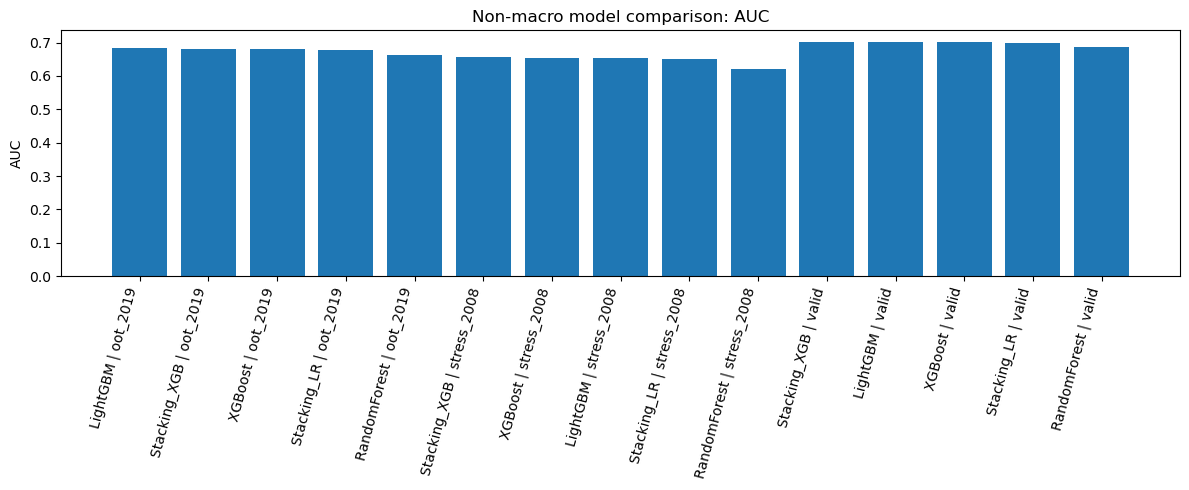

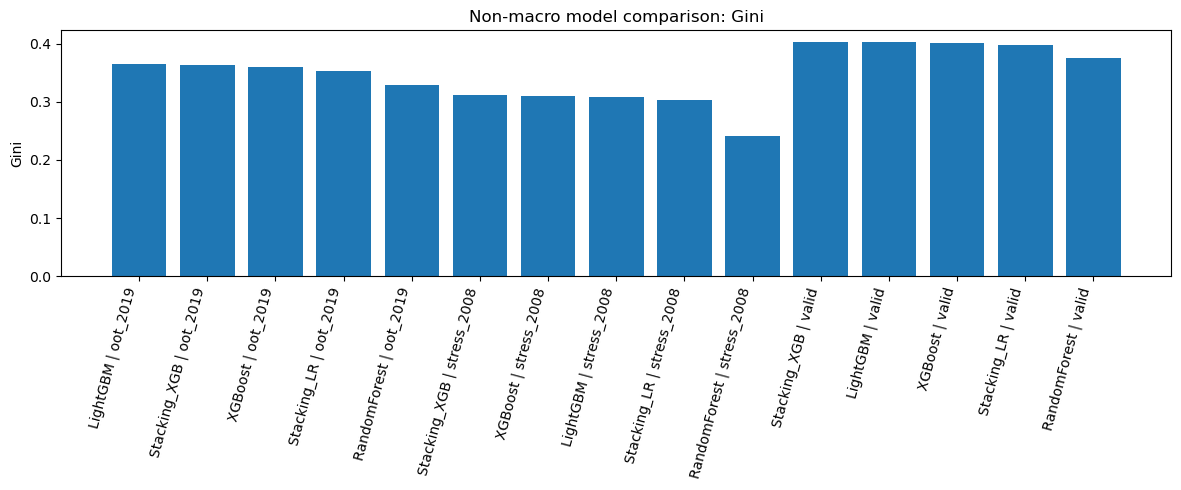

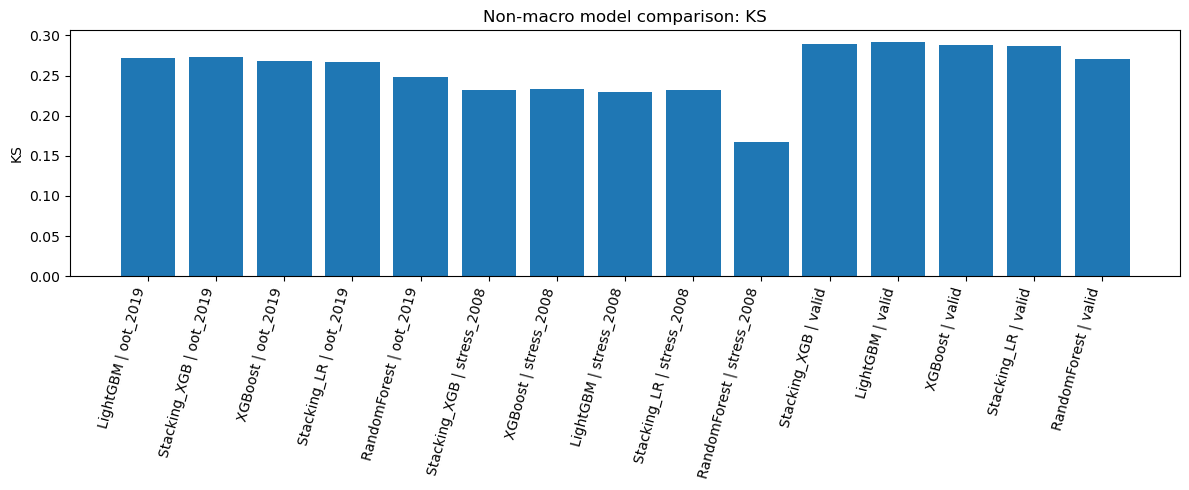

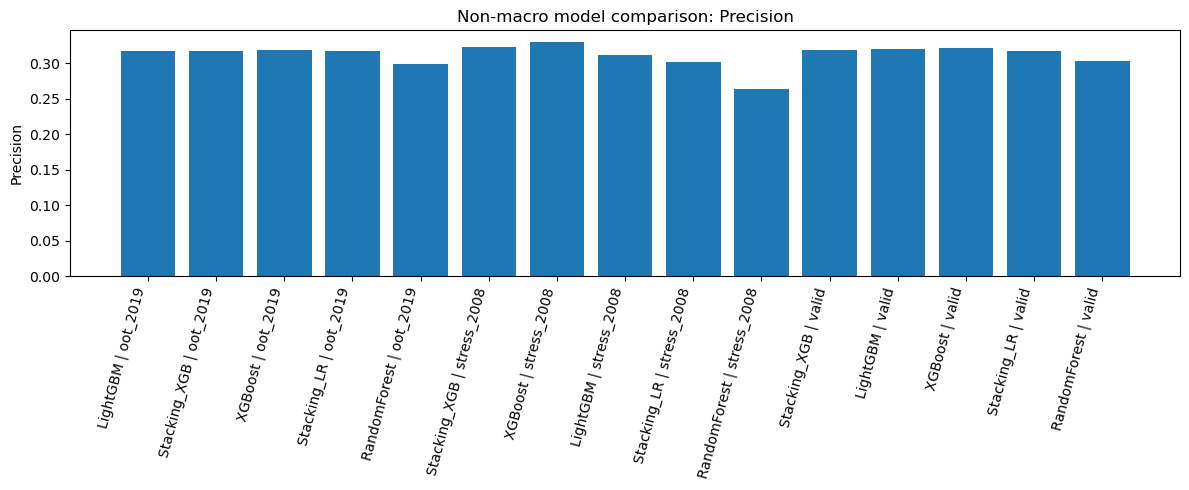

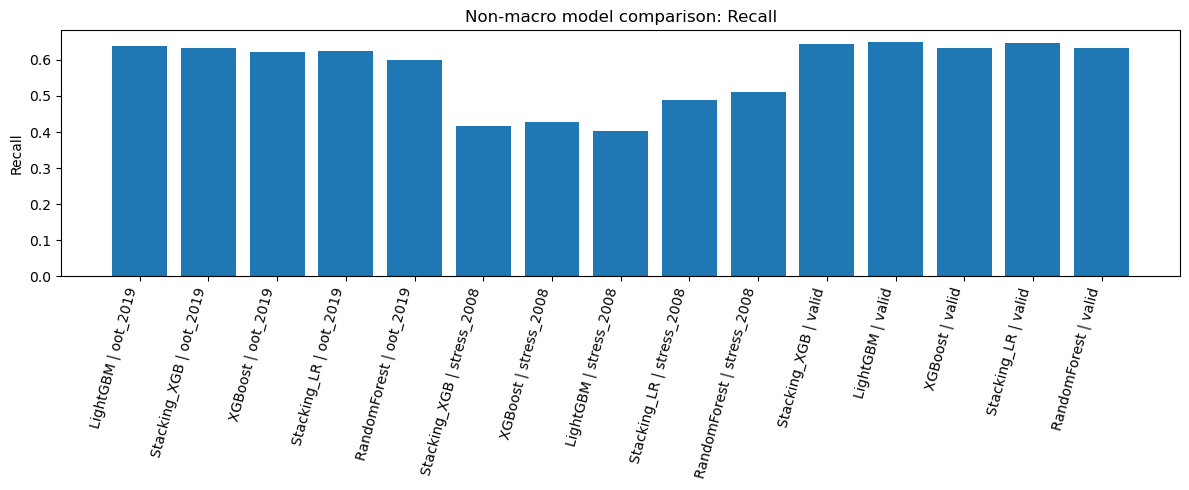

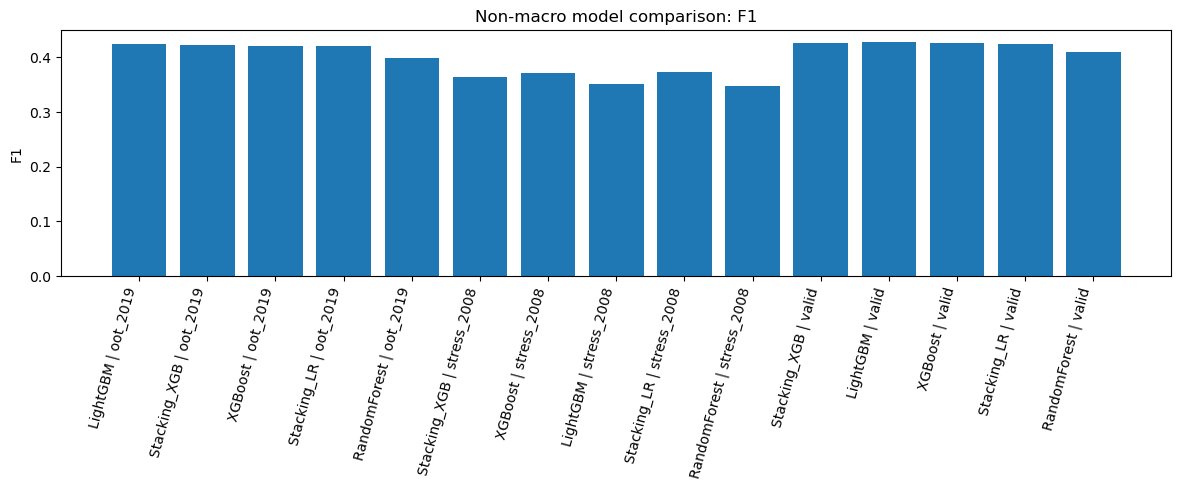

In [ ]:
nonmacro_pred_all = pd.concat(
    [
        *prediction_tables.values(),
        stack_valid_pred_df,
        stack_oot_pred_df,
        stack_stress_pred_df,
        stack_lr_valid_pred_df,
        stack_lr_oot_pred_df,
        stack_lr_stress_pred_df
    ],
    axis=0,
    ignore_index=True
)

print("Combined non-macro prediction rows:", nonmacro_pred_all.shape)

nonmacro_psi_frames = []
for m in nonmacro_pred_all["model"].dropna().unique():
    tmp = nonmacro_pred_all[nonmacro_pred_all["model"] == m].copy()
    psi_df = year_to_year_psi(tmp, score_col="prob_default")
    psi_df["Model"] = m
    nonmacro_psi_frames.append(psi_df)

nonmacro_psi_df = (
    pd.concat(nonmacro_psi_frames, axis=0, ignore_index=True)
    if nonmacro_psi_frames else pd.DataFrame()
)

print("Non-macro PSI:")
display(nonmacro_psi_df)

for metric in ["AUC", "Gini", "KS", "Precision", "Recall", "F1"]:
    plt.figure(figsize=(12, 5))
    tmp = nonmacro_final_compare_df.copy()
    labels = tmp["Model"] + " | " + tmp["Split"]
    plt.bar(labels, tmp[metric])
    plt.xticks(rotation=75, ha="right")
    plt.ylabel(metric)
    plt.title(f"Non-macro model comparison: {metric}")
    plt.tight_layout()
    plt.show()

In [ ]:
#for with fred

In [84]:
# ============================================================
# CELL 3A — add macro variables from FRED to df_model
# Inflation_L6 + FedFunds_L3 + HomePrices_L12 + UNRATE_L6
# ============================================================

from pandas_datareader import data as web
import pandas as pd

# Ensure datetime
df_model["issue_d_parsed"] = pd.to_datetime(df_model["issue_d_parsed"], errors="coerce")

# Monthly merge key
df_model["issue_month"] = df_model["issue_d_parsed"].dt.to_period("M").dt.to_timestamp()

# Pull enough history so lags are available
fred_codes = {
    "Inflation": "CPIAUCSL",
    "FedFunds": "FEDFUNDS",
    "HomePrices": "CSUSHPISA",
    "UNRATE": "UNRATE"
}

max_lag = 12
start_date = (df_model["issue_month"].min() - pd.DateOffset(months=max_lag + 3)).strftime("%Y-%m-%d")
end_date   = (df_model["issue_month"].max() + pd.DateOffset(months=1)).strftime("%Y-%m-%d")

macro = pd.DataFrame()

for name, code in fred_codes.items():
    s = web.DataReader(code, "fred", start_date, end_date)
    s.index = pd.to_datetime(s.index).to_period("M").to_timestamp()
    macro[name] = s[code]

macro = macro.sort_index().ffill()

# Create exactly the lagged variables you want
macro["Inflation_L6"] = macro["Inflation"].shift(6)
macro["FedFunds_L3"] = macro["FedFunds"].shift(3)
macro["HomePrices_L12"] = macro["HomePrices"].shift(12)
macro["UNRATE_L6"] = macro["UNRATE"].shift(6)

macro_to_merge = (
    macro[["Inflation_L6", "FedFunds_L3", "HomePrices_L12", "UNRATE_L6"]]
    .rename_axis("issue_month")
    .reset_index()
)

# Drop old macro columns first if this cell was run before
old_macro_cols = [
    "Inflation_L6", "FedFunds_L3", "HomePrices_L12", "UNRATE_L6",
    "Inflation_L6_x", "FedFunds_L3_x", "HomePrices_L12_x", "UNRATE_L6_x",
    "Inflation_L6_y", "FedFunds_L3_y", "HomePrices_L12_y", "UNRATE_L6_y"
]
df_model = df_model.drop(columns=[c for c in old_macro_cols if c in df_model.columns], errors="ignore")

# Merge into df_model
df_model = df_model.merge(macro_to_merge, on="issue_month", how="left")

macro_cols = ["Inflation_L6", "FedFunds_L3", "HomePrices_L12", "UNRATE_L6"]

print("Added macro columns:")
print(macro_cols)

print("\nMacro columns found in df_model:")
print(df_model.columns[df_model.columns.isin(macro_cols)].tolist())

print("\nPreview:")
print(df_model[["issue_d_parsed", "issue_month"] + macro_cols].head())

Added macro columns:
['Inflation_L6', 'FedFunds_L3', 'HomePrices_L12', 'UNRATE_L6']

Macro columns found in df_model:
['Inflation_L6', 'FedFunds_L3', 'HomePrices_L12', 'UNRATE_L6']

Preview:
  issue_d_parsed issue_month  Inflation_L6  FedFunds_L3  HomePrices_L12  \
0     2011-12-01  2011-12-01       224.806         0.08         142.049   
1     2011-12-01  2011-12-01       224.806         0.08         142.049   
2     2011-12-01  2011-12-01       224.806         0.08         142.049   
3     2011-12-01  2011-12-01       224.806         0.08         142.049   
4     2011-12-01  2011-12-01       224.806         0.08         142.049   

   UNRATE_L6  
0        9.1  
1        9.1  
2        9.1  
3        9.1  
4        9.1  


In [85]:
# ============================================================
# CELL 3B — rebuild splits after macro merge
# ============================================================

main_oot_years = [2019]
stress_years = [2008]
train_valid_years = [2007, 2009, 2010, 2011, 2012, 2013, 2017, 2018]

main_oot_df = df_model[df_model["issue_year"].isin(main_oot_years)].copy()
stress_df = df_model[df_model["issue_year"].isin(stress_years)].copy()
train_valid_df = df_model[df_model["issue_year"].isin(train_valid_years)].copy()

train_df, valid_df = train_test_split(
    train_valid_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=train_valid_df["default"]
)

print("Macro split summary:")
for name, data in [
    ("Train", train_df),
    ("Valid", valid_df),
    ("OOT_2019", main_oot_df),
    ("Stress_2008", stress_df),
]:
    print(
        f"{name:12s} | n = {len(data):>8,d} | "
        f"default rate = {data['default'].mean():.4f} | "
        f"years = {sorted(data['issue_year'].unique().tolist())}"
    )

print("\nCheck macro columns inside train_df:")
print(train_df[["Inflation_L6", "FedFunds_L3", "HomePrices_L12", "UNRATE_L6"]].head())

Macro split summary:
Train        | n =  456,325 | default rate = 0.2054 | years = [2007.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2017.0, 2018.0]
Valid        | n =  114,082 | default rate = 0.2054 | years = [2007.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2017.0, 2018.0]
OOT_2019     | n =   18,529 | default rate = 0.2137 | years = [2019.0]
Stress_2008  | n =    2,393 | default rate = 0.2073 | years = [2008.0]

Check macro columns inside train_df:
        Inflation_L6  FedFunds_L3  HomePrices_L12  UNRATE_L6
453780       247.284         1.42         189.587        4.2
136479       231.249         0.15         140.144        7.7
40934        212.709         0.16         158.325        9.0
569014       250.227         1.91         194.761        4.0
136891       231.249         0.15         140.144        7.7


In [86]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MaxAbsScaler

cat_cols = ['term', 'home_ownership', 'purpose', 'emp_length']
num_cols = [
    'fico_range_low', 'loan_amnt', 'int_rate', 'dti', 'revol_util', 'annual_inc',
    'open_acc', 'delinq_2yrs', 'pub_rec',
    'inq_last_6mths', 'revol_bal',
    'Inflation_L6', 'FedFunds_L3', 'HomePrices_L12', 'UNRATE_L6'
]

cat_cols    = [c for c in cat_cols if c in train_df.columns]
num_cols    = [c for c in num_cols  if c in train_df.columns]
feature_cols = cat_cols + num_cols

# ============================================================
# XGB / LGBM — native NaN handling
# ============================================================
xgb_lgbm_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=50,
            sparse_output=True
        ), cat_cols)
    ],
    remainder="drop"
)

X_train_xgb_lgbm  = xgb_lgbm_preprocessor.fit_transform(train_df[feature_cols])
X_valid_xgb_lgbm  = xgb_lgbm_preprocessor.transform(valid_df[feature_cols])
X_oot_xgb_lgbm    = xgb_lgbm_preprocessor.transform(main_oot_df[feature_cols])
X_stress_xgb_lgbm = xgb_lgbm_preprocessor.transform(stress_df[feature_cols])

y_train  = train_df["default"]
y_valid  = valid_df["default"]
y_oot    = main_oot_df["default"]
y_stress = stress_df["default"]

print("XGB/LGBM macro feature matrix shape:", X_train_xgb_lgbm.shape)

# ============================================================
# RF and LR — complete-case drop, no mort_acc exclusion needed
# ============================================================
rf_lr_feature_cols = feature_cols

rf_train_df  = train_df.dropna(subset=rf_lr_feature_cols).copy()
rf_valid_df  = valid_df.dropna(subset=rf_lr_feature_cols).copy()
rf_oot_df    = main_oot_df.dropna(subset=rf_lr_feature_cols).copy()
rf_stress_df = stress_df.dropna(subset=rf_lr_feature_cols).copy()

print("RF/LR rows after complete-case drop:")
print("  train: ", len(rf_train_df))
print("  valid: ", len(rf_valid_df))
print("  oot:   ", len(rf_oot_df))
print("  stress:", len(rf_stress_df))

y_train_rf  = rf_train_df["default"]
y_valid_rf  = rf_valid_df["default"]
y_oot_rf    = rf_oot_df["default"]
y_stress_rf = rf_stress_df["default"]

rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=50,
            sparse_output=True
        ), cat_cols)
    ],
    remainder="drop"
)

X_train_rf  = rf_preprocessor.fit_transform(rf_train_df[rf_lr_feature_cols])
X_valid_rf  = rf_preprocessor.transform(rf_valid_df[rf_lr_feature_cols])
X_oot_rf    = rf_preprocessor.transform(rf_oot_df[rf_lr_feature_cols])
X_stress_rf = rf_preprocessor.transform(rf_stress_df[rf_lr_feature_cols])

scaler      = MaxAbsScaler()
X_train_lr  = scaler.fit_transform(X_train_rf)
X_valid_lr  = scaler.transform(X_valid_rf)
X_oot_lr    = scaler.transform(X_oot_rf)
X_stress_lr = scaler.transform(X_stress_rf)

print("RF macro feature matrix shape:", X_train_rf.shape)
print("LR macro feature matrix shape:", X_train_lr.shape)

XGB/LGBM macro feature matrix shape: (456325, 49)
RF/LR rows after complete-case drop:
  train:  426474
  valid:  106631
  oot:    16602
  stress: 2381
RF macro feature matrix shape: (426474, 48)
LR macro feature matrix shape: (426474, 48)


In [87]:
print("Macro cols in df_model:", all(c in df_model.columns for c in ["Inflation_L6", "FedFunds_L3", "HomePrices_L12", "UNRATE_L6"]))
print("Macro cols in train_df:", all(c in train_df.columns for c in ["Inflation_L6", "FedFunds_L3", "HomePrices_L12", "UNRATE_L6"]))
print("df_model columns:", df_model.columns.tolist())

Macro cols in df_model: True
Macro cols in train_df: True
df_model columns: ['term', 'fico_range_low', 'loan_amnt', 'int_rate', 'dti', 'home_ownership', 'purpose', 'revol_util', 'annual_inc', 'emp_length', 'open_acc', 'delinq_2yrs', 'pub_rec', 'inq_last_6mths', 'revol_bal', 'default', 'issue_d', 'issue_d_parsed', 'issue_year', 'issue_month', 'Inflation_L6', 'FedFunds_L3', 'HomePrices_L12', 'UNRATE_L6']


In [88]:
xgb_study, xgb_model, xgb_threshold = run_optuna_xgb()


Tuning XGBoost


Best trial: 51. Best value: 0.446393: 100%|██████████| 100/100 [11:27<00:00,  6.87s/it]


Best validation Gini: 0.446393
Best params: {'reg_alpha': 4.0461088102428295, 'reg_lambda': 4.652257692932232, 'max_depth': 6, 'min_child_weight': 7, 'subsample': 0.8883351345167648, 'colsample_bytree': 0.8165727269656768, 'learning_rate': 0.08980717356882845, 'n_estimators': 173}
Validation KS: 0.322537
Chosen threshold from validation KS: 0.209558


In [89]:
lgbm_study, lgbm_model, lgbm_threshold = run_optuna_lgbm()



Tuning LightGBM


Best trial: 76. Best value: 0.448029: 100%|██████████| 100/100 [10:40<00:00,  6.40s/it]


Best validation Gini: 0.448029
Best params: {'reg_alpha': 2.706467062780372, 'reg_lambda': 3.226306301477888, 'num_leaves': 73, 'min_child_samples': 26, 'feature_fraction': 0.999780491190846, 'n_estimators': 294, 'learning_rate': 0.12159631711503784, 'max_depth': 5}
Validation KS: 0.327393
Chosen threshold from validation KS: 0.198636


In [90]:
rf_study, rf_model, rf_threshold = run_optuna_rf()


Tuning Random Forest


Best trial: 23. Best value: 0.434136: 100%|██████████| 25/25 [18:26<00:00, 44.25s/it]


Best validation Gini: 0.434136
Best params: {'min_samples_split': 19, 'min_samples_leaf': 12, 'n_estimators': 299, 'max_features': 'sqrt', 'max_depth': None, 'max_leaf_nodes': None}
Validation KS: 0.310857
Chosen threshold from validation KS: 0.199826


In [91]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MaxAbsScaler

# ============================================================
# Logistic Regression baseline (macro)
# Reuses RF complete-case matrices (no NaN, mort_acc excluded)
# ============================================================

lr_scaler   = MaxAbsScaler()
X_train_lr  = lr_scaler.fit_transform(X_train_rf)
X_valid_lr  = lr_scaler.transform(X_valid_rf)
X_oot_lr    = lr_scaler.transform(X_oot_rf)
X_stress_lr = lr_scaler.transform(X_stress_rf)

lr_model = LogisticRegression(
    C=0.1,
    max_iter=1000,
    solver="saga",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lr_model.fit(X_train_lr, y_train_rf)

lr_valid_prob       = lr_model.predict_proba(X_valid_lr)[:, 1]
lr_ks, lr_threshold = ks_statistic(y_valid_rf, lr_valid_prob)

print(f"LR  Validation KS  : {lr_ks:.4f}")
print(f"LR  Threshold      : {lr_threshold:.4f}")
print(f"LR  Validation Gini: {gini_score(y_valid_rf, lr_valid_prob):.4f}")

LR  Validation KS  : 0.2956
LR  Threshold      : 0.1947
LR  Validation Gini: 0.4076


In [92]:
for name, pred_df in prediction_tables.items():
    save_name = f"macro_{name}_predictions.csv"
    pred_df.to_csv(save_name, index=False)

print("Saved prediction files:")
for name in prediction_tables.keys():
    print(f"- macro_{name}_predictions.csv")

Saved prediction files:
- macro_LogisticRegression_valid_predictions.csv
- macro_LogisticRegression_oot_2019_predictions.csv
- macro_LogisticRegression_stress_2008_predictions.csv
- macro_XGBoost_valid_predictions.csv
- macro_XGBoost_oot_2019_predictions.csv
- macro_XGBoost_stress_2008_predictions.csv
- macro_LightGBM_valid_predictions.csv
- macro_LightGBM_oot_2019_predictions.csv
- macro_LightGBM_stress_2008_predictions.csv
- macro_RandomForest_valid_predictions.csv
- macro_RandomForest_oot_2019_predictions.csv
- macro_RandomForest_stress_2008_predictions.csv


In [93]:
#xgb stacking
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
import optuna
import numpy as np
import pandas as pd

# --- helpers ---
def get_xgb_best_params():
    params = xgb_study.best_params.copy()
    params.update(xgb_fixed)
    return params

def get_lgbm_best_params():
    params = lgbm_study.best_params.copy()
    params.update(lgbm_fixed)
    return params

def get_rf_best_params():
    params = rf_study.best_params.copy()

    max_depth_type = params.pop("max_depth_type", None)
    max_leaf_nodes_type = params.pop("max_leaf_nodes_type", None)

    if max_depth_type == "none":
        params["max_depth"] = None
    if max_leaf_nodes_type == "none":
        params["max_leaf_nodes"] = None

    params.update(rf_fixed)
    return params

xgb_best_params = get_xgb_best_params()
lgbm_best_params = get_lgbm_best_params()
rf_best_params = get_rf_best_params()

print("Base params ready.")
print("XGB:", xgb_best_params)
print("LGBM:", lgbm_best_params)
print("RF:", rf_best_params)

Base params ready.
XGB: {'reg_alpha': 4.0461088102428295, 'reg_lambda': 4.652257692932232, 'max_depth': 6, 'min_child_weight': 7, 'subsample': 0.8883351345167648, 'colsample_bytree': 0.8165727269656768, 'learning_rate': 0.08980717356882845, 'n_estimators': 173, 'objective': 'binary:logistic', 'eval_metric': 'auc', 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}
LGBM: {'reg_alpha': 2.706467062780372, 'reg_lambda': 3.226306301477888, 'num_leaves': 73, 'min_child_samples': 26, 'feature_fraction': 0.999780491190846, 'n_estimators': 294, 'learning_rate': 0.12159631711503784, 'max_depth': 5, 'objective': 'binary', 'verbosity': -1, 'random_state': 42, 'n_jobs': -1}
RF: {'min_samples_split': 19, 'min_samples_leaf': 12, 'n_estimators': 299, 'max_features': 'sqrt', 'max_depth': None, 'max_leaf_nodes': None, 'random_state': 42, 'n_jobs': -1}


In [94]:
# OOF predictions on TRAIN only (XGB + LGBM only)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

n_train = X_train_xgb_lgbm.shape[0]

oof_xgb = np.zeros(n_train)
oof_lgbm = np.zeros(n_train)

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_xgb_lgbm, y_train), 1):
    X_tr, X_va = X_train_xgb_lgbm[tr_idx], X_train_xgb_lgbm[va_idx]
    y_tr = y_train.iloc[tr_idx]

    xgb_fold = XGBClassifier(**xgb_best_params)
    lgbm_fold = LGBMClassifier(**lgbm_best_params)

    xgb_fold.fit(X_tr, y_tr)
    lgbm_fold.fit(X_tr, y_tr)

    oof_xgb[va_idx] = xgb_fold.predict_proba(X_va)[:, 1]
    oof_lgbm[va_idx] = lgbm_fold.predict_proba(X_va)[:, 1]

    print(f"Finished fold {fold}/5")

Finished fold 1/5
Finished fold 2/5
Finished fold 3/5
Finished fold 4/5
Finished fold 5/5


In [95]:
print(f"OOF feature count: {X_train_xgb_lgbm.shape[1]}")

OOF feature count: 49


In [96]:
valid_prob_xgb = xgb_model.predict_proba(X_valid_xgb_lgbm)[:, 1]
valid_prob_lgbm = lgbm_model.predict_proba(X_valid_xgb_lgbm)[:, 1]

oot_prob_xgb = xgb_model.predict_proba(X_oot_xgb_lgbm)[:, 1]
oot_prob_lgbm = lgbm_model.predict_proba(X_oot_xgb_lgbm)[:, 1]

stress_prob_xgb = xgb_model.predict_proba(X_stress_xgb_lgbm)[:, 1]
stress_prob_lgbm = lgbm_model.predict_proba(X_stress_xgb_lgbm)[:, 1]

In [97]:
meta_train = pd.DataFrame({
    "prob_xgb": oof_xgb,
    "prob_lgbm": oof_lgbm
}, index=y_train.index)

meta_valid = pd.DataFrame({
    "prob_xgb": valid_prob_xgb,
    "prob_lgbm": valid_prob_lgbm
}, index=y_valid.index)

meta_oot = pd.DataFrame({
    "prob_xgb": oot_prob_xgb,
    "prob_lgbm": oot_prob_lgbm
}, index=y_oot.index)

meta_stress = pd.DataFrame({
    "prob_xgb": stress_prob_xgb,
    "prob_lgbm": stress_prob_lgbm
}, index=y_stress.index)

print(meta_train.shape, meta_valid.shape, meta_oot.shape, meta_stress.shape)

(456325, 2) (114082, 2) (18529, 2) (2393, 2)


In [98]:
N_TRIALS_META = 100

meta_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
meta_study.optimize(meta_xgb_objective, n_trials=N_TRIALS_META, show_progress_bar=True)

meta_best_params = meta_study.best_params.copy()
meta_best_params.update({
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": 0
})

print("Best meta validation Gini:", round(meta_study.best_value, 6))
print("Best meta params:", meta_best_params)

Best trial: 91. Best value: 0.448412: 100%|██████████| 100/100 [01:41<00:00,  1.02s/it]

Best meta validation Gini: 0.448412
Best meta params: {'n_estimators': 126, 'max_depth': 4, 'learning_rate': 0.010644508376480963, 'subsample': 0.7272845746563397, 'colsample_bytree': 0.7222853631409666, 'min_child_weight': 9, 'reg_alpha': 0.0012663185312993533, 'reg_lambda': 6.496658149838385, 'objective': 'binary:logistic', 'eval_metric': 'auc', 'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}


In [99]:
meta_xgb_model = XGBClassifier(**meta_best_params)
meta_xgb_model.fit(meta_train, y_train)

stack_valid_prob  = meta_xgb_model.predict_proba(meta_valid)[:, 1]
stack_oot_prob    = meta_xgb_model.predict_proba(meta_oot)[:, 1]
stack_stress_prob = meta_xgb_model.predict_proba(meta_stress)[:, 1]

# Recompute threshold from macro meta model
macro_stack_ks, stack_threshold = ks_statistic(y_valid, stack_valid_prob)
print(f"Macro Stacking_XGB threshold: {stack_threshold:.6f}")
print(f"Macro Stacking_XGB validation Gini: {gini_score(y_valid, stack_valid_prob):.6f}")

stack_valid_pred_df = make_pred_df(
    valid_df, y_valid, stack_valid_prob, stack_threshold, "valid", "Stacking_XGB"
)
stack_oot_pred_df = make_pred_df(
    main_oot_df, y_oot, stack_oot_prob, stack_threshold, "oot_2019", "Stacking_XGB"
)
stack_stress_pred_df = make_pred_df(
    stress_df, y_stress, stack_stress_prob, stack_threshold, "stress_2008", "Stacking_XGB"
)

stack_valid_pred_df.to_csv("stacking_xgb_valid_predictions.csv", index=False)
stack_oot_pred_df.to_csv("stacking_xgb_oot_2019_predictions.csv", index=False)
stack_stress_pred_df.to_csv("stacking_xgb_stress_2008_predictions.csv", index=False)

display(stack_valid_pred_df.head())
display(stack_oot_pred_df.head())
display(stack_stress_pred_df.head())

Macro Stacking_XGB threshold: 0.203543
Macro Stacking_XGB validation Gini: 0.448412


,issue_d,issue_year,actual_default,pred_label,prob_non_default,prob_default,model,split
49219,Dec-13,2013.0,0,0,0.880687,0.119313,Stacking_XGB,valid
357492,Oct-17,2017.0,1,1,0.585573,0.414427,Stacking_XGB,valid
402544,Feb-18,2018.0,0,0,0.841000,0.159000,Stacking_XGB,valid
408423,Feb-18,2018.0,0,1,0.626357,0.373643,Stacking_XGB,valid
191622,Oct-12,2012.0,0,0,0.863885,0.136115,Stacking_XGB,valid


,issue_d,issue_year,actual_default,pred_label,prob_non_default,prob_default,model,split
572800,Mar-19,2019.0,0,1,0.776788,0.223213,Stacking_XGB,oot_2019
572801,Mar-19,2019.0,0,0,0.911765,0.088235,Stacking_XGB,oot_2019
572802,Mar-19,2019.0,1,1,0.631829,0.368171,Stacking_XGB,oot_2019
572803,Mar-19,2019.0,0,1,0.714343,0.285657,Stacking_XGB,oot_2019
572804,Mar-19,2019.0,0,1,0.760990,0.239010,Stacking_XGB,oot_2019


,issue_d,issue_year,actual_default,pred_label,prob_non_default,prob_default,model,split
37968,Dec-08,2008.0,0,0,0.886815,0.113185,Stacking_XGB,stress_2008
37969,Dec-08,2008.0,1,0,0.833500,0.166500,Stacking_XGB,stress_2008
37970,Dec-08,2008.0,0,1,0.716451,0.283549,Stacking_XGB,stress_2008
37972,Dec-08,2008.0,0,0,0.846876,0.153124,Stacking_XGB,stress_2008
37973,Dec-08,2008.0,0,0,0.836684,0.163316,Stacking_XGB,stress_2008


In [100]:
def make_pred_df(base_df, y_true, prob, threshold, split_name, model_name):
    pred = (prob >= threshold).astype(int)
    out = pd.DataFrame({
        "issue_d": base_df["issue_d"].values if "issue_d" in base_df.columns else None,
        "issue_year": base_df["issue_year"].values if "issue_year" in base_df.columns else None,
        "actual_default": y_true.values,
        "pred_label": pred,
        "prob_non_default": 1 - prob,
        "prob_default": prob,
        "model": model_name,
        "split": split_name
    }, index=y_true.index)
    return out

stack_valid_pred_df = make_pred_df(
    valid_df,
    y_valid,
    meta_xgb_model.predict_proba(meta_valid)[:, 1],
    stack_threshold,
    "valid",
    "Stacking_XGB"
)

stack_oot_pred_df = make_pred_df(
    main_oot_df,
    y_oot,
    meta_xgb_model.predict_proba(meta_oot)[:, 1],
    stack_threshold,
    "oot_2019",
    "Stacking_XGB"
)

stack_stress_pred_df = make_pred_df(
    stress_df,
    y_stress,
    meta_xgb_model.predict_proba(meta_stress)[:, 1],
    stack_threshold,
    "stress_2008",
    "Stacking_XGB"
)

stack_valid_pred_df.to_csv("macro_stacking_xgb_valid_predictions.csv", index=False)
stack_oot_pred_df.to_csv("macro_stacking_xgb_oot_2019_predictions.csv", index=False)
stack_stress_pred_df.to_csv("macro_stacking_xgb_stress_2008_predictions.csv", index=False)

print("Saved:")
print("- macro_stacking_xgb_valid_predictions.csv")
print("- macro_stacking_xgb_oot_2019_predictions.csv")
print("- macro_stacking_xgb_stress_2008_predictions.csv")

Saved:
- macro_stacking_xgb_valid_predictions.csv
- macro_stacking_xgb_oot_2019_predictions.csv
- macro_stacking_xgb_stress_2008_predictions.csv


In [101]:
#logistic stacking
from sklearn.linear_model import LogisticRegression

meta_lr_model = LogisticRegression(
    C=1.0,
    penalty="l2",
    solver="lbfgs",
    max_iter=2000,
    random_state=RANDOM_STATE
)

meta_lr_model.fit(meta_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [102]:
stack_lr_valid_prob = meta_lr_model.predict_proba(meta_valid)[:, 1]
stack_lr_valid_ks, stack_lr_threshold = ks_statistic(y_valid, stack_lr_valid_prob)

print("Stacking-LR validation Gini:", round(gini_score(y_valid, stack_lr_valid_prob), 6))
print("Stacking-LR validation KS:", round(stack_lr_valid_ks, 6))
print("Chosen threshold:", round(stack_lr_threshold, 6))

Stacking-LR validation Gini: 0.448446
Stacking-LR validation KS: 0.324747
Chosen threshold: 0.182133


In [103]:
stack_lr_results = []

for split_name, X_split, y_split in [
    ("valid", meta_valid, y_valid),
    ("oot_2019", meta_oot, y_oot),
    ("stress_2008", meta_stress, y_stress),
]:
    prob = meta_lr_model.predict_proba(X_split)[:, 1]
    metrics = evaluate_split(y_split, prob, stack_lr_threshold)

    stack_lr_results.append({
        "Model": "Stacking_LR",
        "Split": split_name,
        "Threshold": stack_lr_threshold,
        **metrics
    })

macro_stack_lr_results_df = pd.DataFrame(stack_lr_results)
display(macro_stack_lr_results_df)

,Model,Split,Threshold,AUC,Gini,KS,Precision,Recall,F1
0,Stacking_LR,valid,0.182133,0.724223,0.448446,0.324747,0.333390,0.672101,0.445696
1,Stacking_LR,oot_2019,0.182133,0.707851,0.415703,0.310212,0.318623,0.721970,0.442125
2,Stacking_LR,stress_2008,0.182133,0.660128,0.320255,0.245639,0.297769,0.618952,0.402096


In [104]:
def make_pred_df(base_df, y_true, prob, threshold, split_name, model_name):
    pred = (prob >= threshold).astype(int)
    out = pd.DataFrame({
        "issue_d": base_df["issue_d"].values if "issue_d" in base_df.columns else None,
        "issue_year": base_df["issue_year"].values if "issue_year" in base_df.columns else None,
        "actual_default": y_true.values,
        "pred_label": pred,
        "prob_non_default": 1 - prob,
        "prob_default": prob,
        "model": model_name,
        "split": split_name
    }, index=y_true.index)
    return out

stack_lr_valid_pred_df = make_pred_df(
    valid_df, y_valid,
    meta_lr_model.predict_proba(meta_valid)[:, 1],
    stack_lr_threshold, "valid", "Stacking_LR"
)

stack_lr_oot_pred_df = make_pred_df(
    main_oot_df, y_oot,
    meta_lr_model.predict_proba(meta_oot)[:, 1],
    stack_lr_threshold, "oot_2019", "Stacking_LR"
)

stack_lr_stress_pred_df = make_pred_df(
    stress_df, y_stress,
    meta_lr_model.predict_proba(meta_stress)[:, 1],
    stack_lr_threshold, "stress_2008", "Stacking_LR"
)

stack_lr_valid_pred_df.to_csv("stacking_lr_valid_predictions.csv", index=False)
stack_lr_oot_pred_df.to_csv("stacking_lr_oot_2019_predictions.csv", index=False)
stack_lr_stress_pred_df.to_csv("stacking_lr_stress_2008_predictions.csv", index=False)

print("Saved:")
print("- stacking_lr_valid_predictions.csv")
print("- stacking_lr_oot_2019_predictions.csv")
print("- stacking_lr_stress_2008_predictions.csv")

Saved:
- stacking_lr_valid_predictions.csv
- stacking_lr_oot_2019_predictions.csv
- stacking_lr_stress_2008_predictions.csv


In [105]:
split_map_lr = {
    "valid":       (X_valid_lr,  y_valid_rf,  rf_valid_df),
    "oot_2019":    (X_oot_lr,    y_oot_rf,    rf_oot_df),
    "stress_2008": (X_stress_lr, y_stress_rf, rf_stress_df)
}

models = {
    "LogisticRegression": (lr_model, lr_threshold),
    "XGBoost":            (xgb_model, xgb_threshold),
    "LightGBM":           (lgbm_model, lgbm_threshold),
    "RandomForest":       (rf_model, rf_threshold)
}

split_map_xgb_lgbm = {
    "valid":       (X_valid_xgb_lgbm,  y_valid,   valid_df),
    "oot_2019":    (X_oot_xgb_lgbm,    y_oot,     main_oot_df),
    "stress_2008": (X_stress_xgb_lgbm, y_stress,  stress_df)
}

split_map_rf = {
    "valid":       (X_valid_rf,  y_valid_rf,  rf_valid_df),
    "oot_2019":    (X_oot_rf,    y_oot_rf,    rf_oot_df),
    "stress_2008": (X_stress_rf, y_stress_rf, rf_stress_df)
}

metrics_rows = []
prediction_tables = {}

for model_name, (model, threshold) in models.items():
    if model_name == "RandomForest":
        split_map = split_map_rf
    elif model_name == "LogisticRegression":
        split_map = split_map_lr
    else:
        split_map = split_map_xgb_lgbm

    for split_name, (X_split, y_split, base_df) in split_map.items():
        prob = model.predict_proba(X_split)[:, 1]
        metrics = evaluate_split(y_split, prob, threshold)

        metrics_rows.append({
            "Model":     model_name,
            "Split":     split_name,
            "Threshold": threshold,
            **metrics
        })

        pred_df = build_prediction_table(
            base_df=base_df,
            y_true=y_split,
            y_prob=prob,
            threshold=threshold,
            model_name=model_name,
            split_name=split_name
        )
        prediction_tables[f"{model_name}_{split_name}"] = pred_df

macro_results_df = pd.DataFrame(metrics_rows).sort_values(
    ["Split", "Gini"], ascending=[True, False]
)
display(macro_results_df)

,Model,Split,Threshold,AUC,Gini,KS,Precision,Recall,F1
7,LightGBM,oot_2019,0.198636,0.707222,0.414444,0.310290,0.315641,0.735859,0.441783
4,XGBoost,oot_2019,0.209558,0.706937,0.413874,0.309836,0.320917,0.717929,0.443560
10,RandomForest,oot_2019,0.199826,0.702874,0.405748,0.308411,0.292350,0.773314,0.424296
1,LogisticRegression,oot_2019,0.194663,0.689291,0.378583,0.282501,0.279635,0.790029,0.413063
8,LightGBM,stress_2008,0.198636,0.659740,0.319479,0.249930,0.292929,0.643145,0.402524
5,XGBoost,stress_2008,0.209558,0.655221,0.310442,0.230628,0.291411,0.574597,0.386703
11,RandomForest,stress_2008,0.199826,0.647027,0.294054,0.215804,0.280316,0.648374,0.391411
2,LogisticRegression,stress_2008,0.194663,0.637280,0.274559,0.215673,0.283510,0.597561,0.384565
6,LightGBM,valid,0.198636,0.724014,0.448029,0.327393,0.328558,0.693952,0.445968
3,XGBoost,valid,0.209558,0.723196,0.446393,0.322537,0.335412,0.661133,0.445041


In [106]:
stack_xgb_results = []

for split_name, X_split, y_split in [
    ("valid",       meta_valid,  y_valid),
    ("oot_2019",    meta_oot,    y_oot),
    ("stress_2008", meta_stress, y_stress),
]:
    prob = meta_xgb_model.predict_proba(X_split)[:, 1]
    metrics = evaluate_split(y_split, prob, stack_threshold)

    stack_xgb_results.append({
        "Model":     "Stacking_XGB",
        "Split":     split_name,
        "Threshold": stack_threshold,
        **metrics
    })

stack_xgb_results_df = pd.DataFrame(stack_xgb_results)

macro_final_compare_df = pd.concat(
    [macro_results_df, stack_xgb_results_df, macro_stack_lr_results_df],  # <-- fixed
    axis=0,
    ignore_index=True
)

macro_final_compare_df = macro_final_compare_df.sort_values(
    ["Split", "Gini"], ascending=[True, False]
).reset_index(drop=True)

display(macro_final_compare_df)

,Model,Split,Threshold,AUC,Gini,KS,Precision,Recall,F1
0,Stacking_LR,oot_2019,0.182133,0.707851,0.415703,0.310212,0.318623,0.721970,0.442125
1,Stacking_XGB,oot_2019,0.203543,0.707745,0.415490,0.309833,0.316958,0.728283,0.441688
2,LightGBM,oot_2019,0.198636,0.707222,0.414444,0.310290,0.315641,0.735859,0.441783
3,XGBoost,oot_2019,0.209558,0.706937,0.413874,0.309836,0.320917,0.717929,0.443560
4,RandomForest,oot_2019,0.199826,0.702874,0.405748,0.308411,0.292350,0.773314,0.424296
5,LogisticRegression,oot_2019,0.194663,0.689291,0.378583,0.282501,0.279635,0.790029,0.413063
6,Stacking_XGB,stress_2008,0.203543,0.660535,0.321070,0.244566,0.295841,0.631048,0.402831
7,Stacking_LR,stress_2008,0.182133,0.660128,0.320255,0.245639,0.297769,0.618952,0.402096
8,LightGBM,stress_2008,0.198636,0.659740,0.319479,0.249930,0.292929,0.643145,0.402524
9,XGBoost,stress_2008,0.209558,0.655221,0.310442,0.230628,0.291411,0.574597,0.386703


Combined macro prediction rows: (791244, 8)
Macro PSI:


,Year_1,Year_2,PSI,Model
0,2007,2008,0.243751,LogisticRegression
1,2008,2009,0.335228,LogisticRegression
2,2009,2010,0.076806,LogisticRegression
3,2010,2011,0.034946,LogisticRegression
4,2011,2012,0.032515,LogisticRegression
5,2012,2013,0.052066,LogisticRegression
6,2013,2017,0.332498,LogisticRegression
7,2017,2018,0.006041,LogisticRegression
8,2018,2019,0.024840,LogisticRegression
9,2007,2008,0.178972,XGBoost


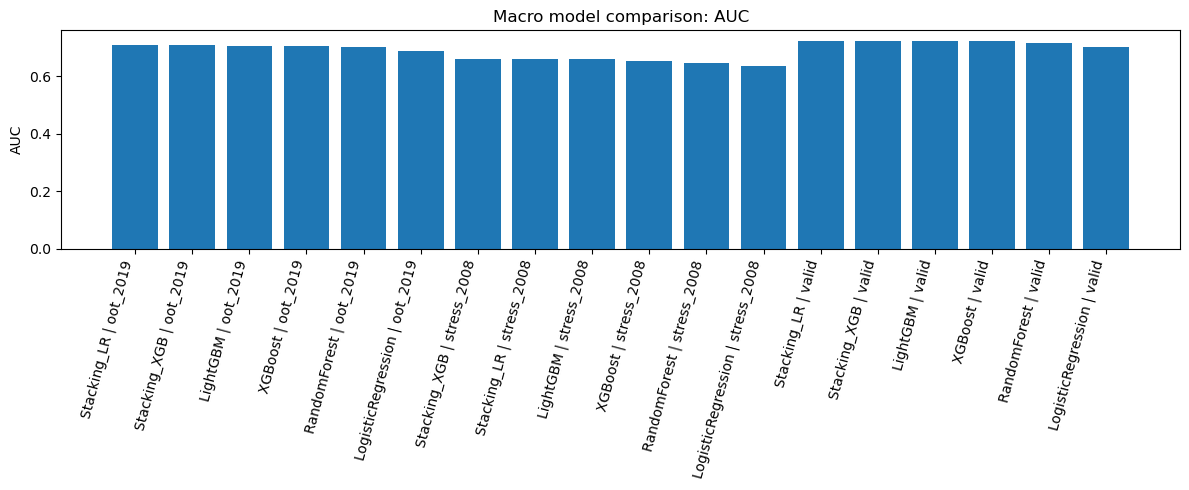

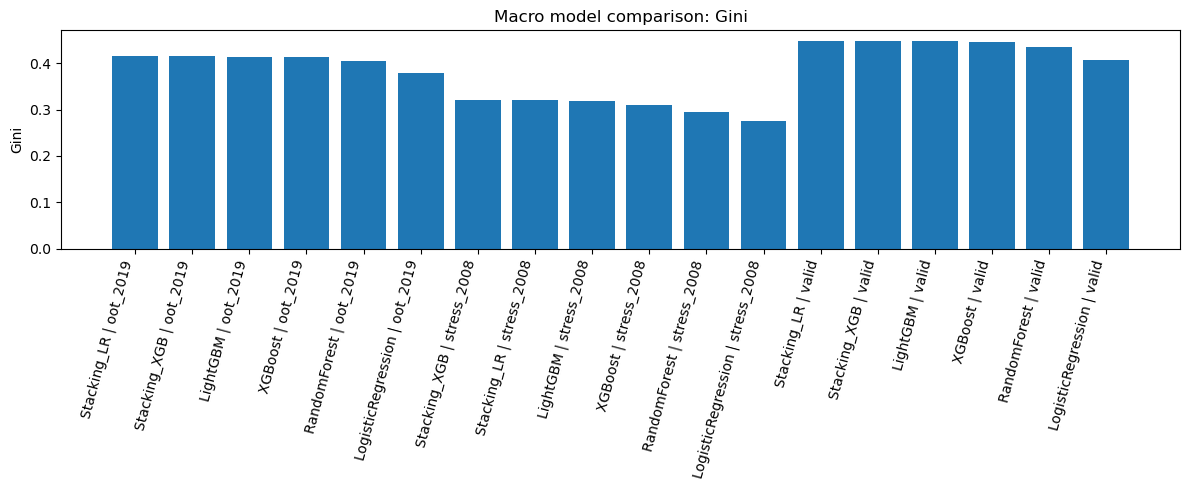

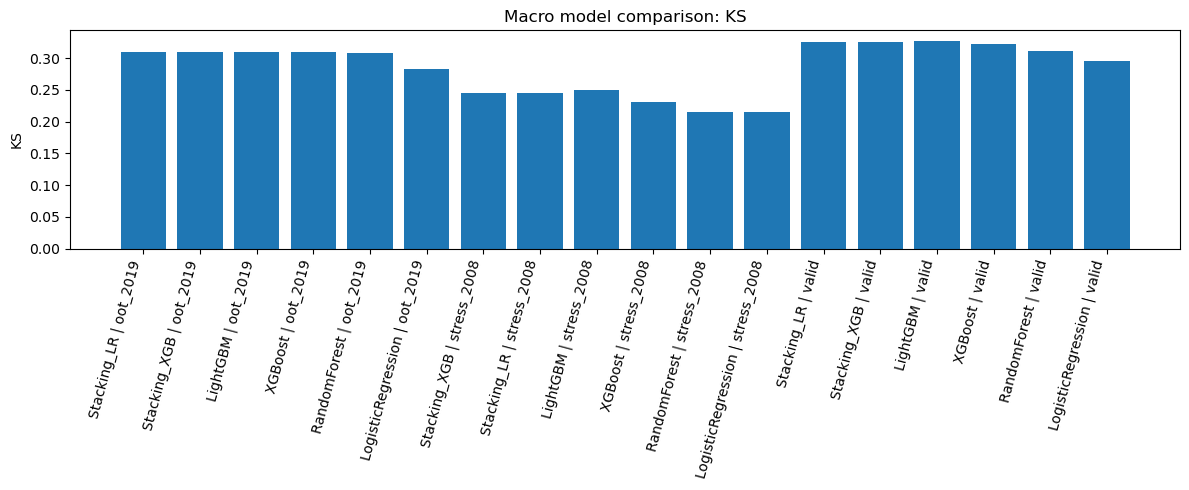

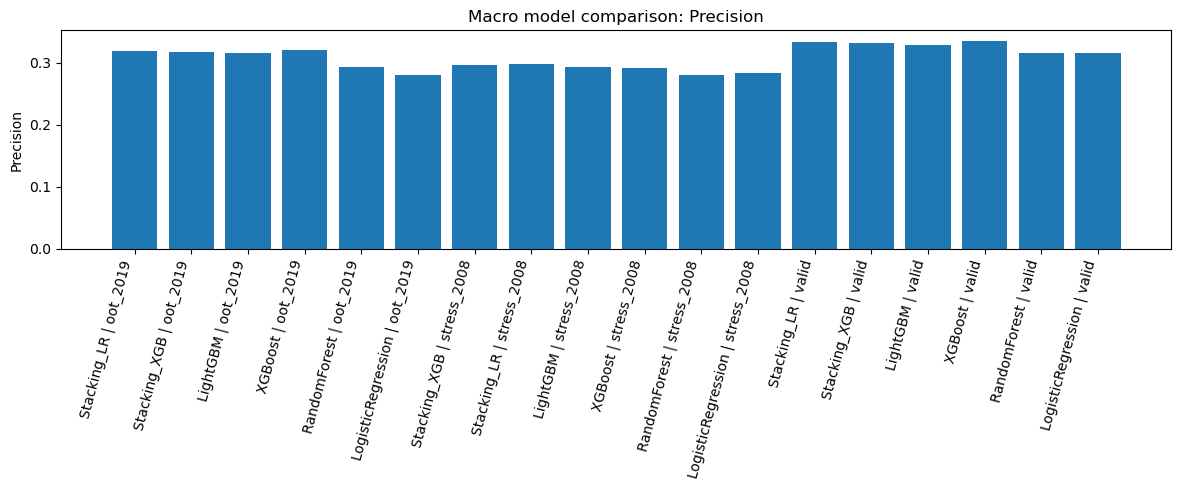

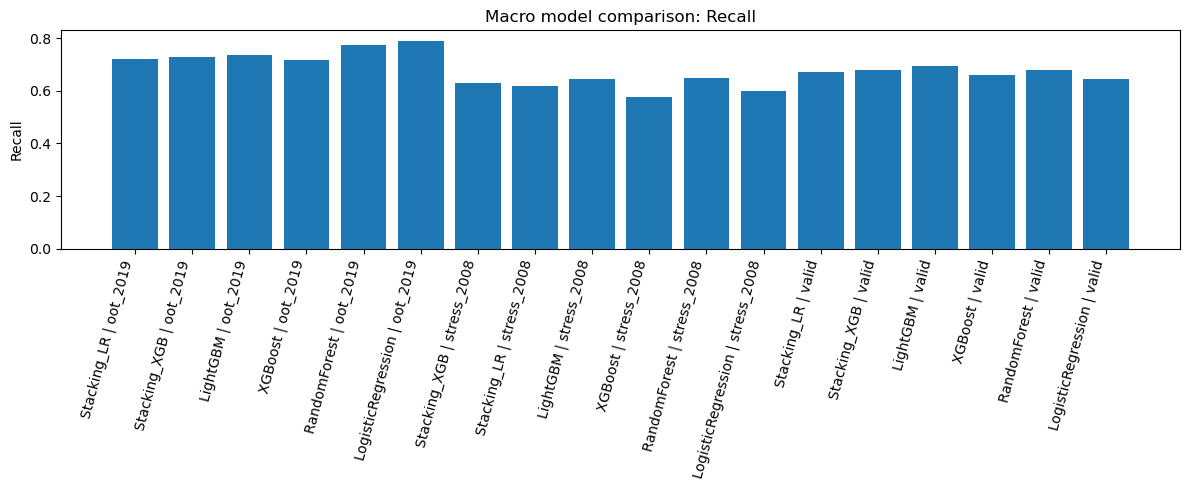

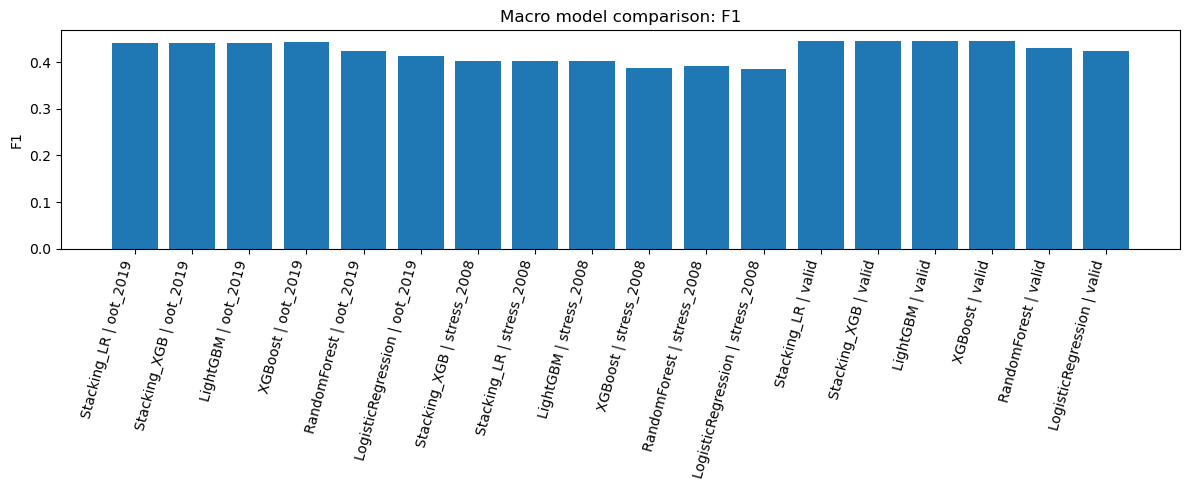

In [107]:
macro_pred_all = pd.concat(
    [
        *prediction_tables.values(),
        stack_valid_pred_df,
        stack_oot_pred_df,
        stack_stress_pred_df,
        stack_lr_valid_pred_df,
        stack_lr_oot_pred_df,
        stack_lr_stress_pred_df
    ],
    axis=0,
    ignore_index=True
)

print("Combined macro prediction rows:", macro_pred_all.shape)

macro_psi_frames = []
for m in macro_pred_all["model"].dropna().unique():
    tmp = macro_pred_all[macro_pred_all["model"] == m].copy()
    psi_df = year_to_year_psi(tmp, score_col="prob_default")
    psi_df["Model"] = m
    macro_psi_frames.append(psi_df)

macro_psi_df = (
    pd.concat(macro_psi_frames, axis=0, ignore_index=True)
    if macro_psi_frames else pd.DataFrame()
)

print("Macro PSI:")
display(macro_psi_df)

for metric in ["AUC", "Gini", "KS", "Precision", "Recall", "F1"]:
    plt.figure(figsize=(12, 5))
    tmp = macro_final_compare_df.copy()
    labels = tmp["Model"] + " | " + tmp["Split"]
    plt.bar(labels, tmp[metric])
    plt.xticks(rotation=75, ha="right")
    plt.ylabel(metric)
    plt.title(f"Macro model comparison: {metric}")
    plt.tight_layout()
    plt.show()

In [108]:
# ============================================================
# BLOCK 33 — refit final deploy LightGBM
# use all non-stress data for deployment
# ============================================================

from sklearn.base import clone
from lightgbm import LGBMClassifier

# Keep stress_2008 as a historical stress reference, not deployment training data
deploy_df = pd.concat([train_valid_df, main_oot_df], axis=0).copy()

print("Deploy dataset shape:", deploy_df.shape)
print("Deploy years:", sorted(deploy_df["issue_year"].unique().tolist()))
print("Deploy default rate:", round(deploy_df["default"].mean(), 6))

# final raw feature schema
cat_cols_final = ['term', 'home_ownership', 'purpose', 'emp_length']

num_cols_final = [
    'fico_range_low', 'loan_amnt', 'dti', 'revol_util', 'annual_inc',
    'open_acc', 'delinq_2yrs', 'pub_rec',
    'inq_last_6mths', 'int_rate', 'revol_bal',
    'Inflation_L6', 'FedFunds_L3', 'HomePrices_L12', 'UNRATE_L6'
]
feature_cols_final = cat_cols_final + num_cols_final

# safety
cat_cols_final = [c for c in cat_cols_final if c in deploy_df.columns]
num_cols_final = [c for c in num_cols_final if c in deploy_df.columns]
feature_cols_final = cat_cols_final + num_cols_final

deploy_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            num_cols_final
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(
                    handle_unknown="infrequent_if_exist",
                    min_frequency=50,
                    sparse_output=True
                ))
            ]),
            cat_cols_final
        )
    ],
    remainder="drop"
)

X_deploy = deploy_preprocessor.fit_transform(deploy_df[feature_cols_final])
y_deploy = deploy_df["default"].astype(int).copy()

# use the tuned best LightGBM settings from your Optuna study
lgbm_best_params = lgbm_study.best_params.copy()

deploy_lgbm_model = LGBMClassifier(
    **lgbm_best_params,
    **lgbm_fixed
)

deploy_lgbm_model.fit(X_deploy, y_deploy)

print("Deploy LightGBM trained.")
print("X_deploy shape:", X_deploy.shape)
print("n raw features:", len(feature_cols_final))

Deploy dataset shape: (588936, 24)
Deploy years: [2007.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2017.0, 2018.0, 2019.0]
Deploy default rate: 0.205645
Deploy LightGBM trained.
X_deploy shape: (588936, 48)
n raw features: 19


In [109]:
# ============================================================
# BLOCK 34 — macro helper for one application date
# ============================================================

from pandas_datareader import data as web
import pandas as pd

def get_macro_features_for_date(application_date):
    """
    application_date: string or datetime like '2018-01-01'
    returns:
    Inflation_L6, FedFunds_L3, HomePrices_L12, UNRATE_L6
    """
    app_month = pd.Timestamp(application_date).to_period("M").to_timestamp()

    start_date = (app_month - pd.DateOffset(months=18)).strftime("%Y-%m-%d")
    end_date = app_month.strftime("%Y-%m-%d")

    fred_codes = {
        "Inflation": "CPIAUCSL",
        "FedFunds": "FEDFUNDS",
        "HomePrices": "CSUSHPISA",
        "UNRATE": "UNRATE"
    }

    macro = pd.DataFrame()

    for name, code in fred_codes.items():
        s = web.DataReader(code, "fred", start_date, end_date)
        s.index = pd.to_datetime(s.index).to_period("M").to_timestamp()
        macro[name] = s[code]

    macro = macro.sort_index().ffill()

    out = {
        "Inflation_L6": float(macro["Inflation"].shift(6).dropna().iloc[-1]),
        "FedFunds_L3": float(macro["FedFunds"].shift(3).dropna().iloc[-1]),
        "HomePrices_L12": float(macro["HomePrices"].shift(12).dropna().iloc[-1]),
        "UNRATE_L6": float(macro["UNRATE"].shift(6).dropna().iloc[-1]),
    }

    return out

# quick sanity check
print(get_macro_features_for_date("2018-01-01"))

{'Inflation_L6': 244.243, 'FedFunds_L3': 1.15, 'HomePrices_L12': 186.774, 'UNRATE_L6': 4.3}


In [110]:
# ============================================================
# BLOCK 35 — single-applicant prediction helper
# ============================================================

import numpy as np
import pandas as pd

def build_single_applicant_row(applicant_dict, application_date):
    macro_dict = get_macro_features_for_date(application_date)

    row = {**applicant_dict, **macro_dict}
    row_df = pd.DataFrame([row])

    for col in feature_cols_final:
        if col not in row_df.columns:
            row_df[col] = np.nan

    row_df = row_df[feature_cols_final]
    return row_df

def predict_single_applicant(applicant_dict, application_date):
    row_df = build_single_applicant_row(applicant_dict, application_date)
    X_row = deploy_preprocessor.transform(row_df)
    pd_hat = deploy_lgbm_model.predict_proba(X_row)[:, 1][0]
    return float(pd_hat), row_df

In [111]:
# ============================================================
# BLOCK 36 — manual sanity test cases
# ============================================================

test_cases = {
    "low_risk_case": {
        "term": "36 months",
        "home_ownership": "MORTGAGE",
        "purpose": "debt_consolidation",
        "emp_length": "10+ years",
        "fico_range_low": 760,
        "loan_amnt": 8000,
        "dti": 6.7,
        "revol_util": 22.0,
        "annual_inc": 120000,
        "open_acc": 12,
        "delinq_2yrs": 0,
        "pub_rec": 0,
        "inq_last_6mths": 0,
        "revol_bal": 8000
    },
    "medium_risk_case": {
        "term": "36 months",
        "home_ownership": "RENT",
        "purpose": "credit_card",
        "emp_length": "3 years",
        "fico_range_low": 680,
        "loan_amnt": 15000,
        "dti": 18.0,
        "revol_util": 45.0,
        "annual_inc": 70000,
        "open_acc": 8,
        "delinq_2yrs": 0,
        "pub_rec": 0,
        "inq_last_6mths": 1,
        "revol_bal": 12000
    },
    "high_risk_case": {
        "term": "60 months",
        "home_ownership": "RENT",
        "purpose": "small_business",
        "emp_length": "< 1 year",
        "fico_range_low": 610,
        "loan_amnt": 25000,
        "dti": 32.0,
        "revol_util": 82.0,
        "annual_inc": 38000,
        "open_acc": 5,
        "delinq_2yrs": 2,
        "pub_rec": 1,
        "inq_last_6mths": 4,
        "revol_bal": 22000
    }
}

test_rows = []

for case_name, profile in test_cases.items():
    pd_hat, row_df = predict_single_applicant(profile, "2018-01-01")
    test_rows.append({
        "case": case_name,
        "predicted_pd": pd_hat
    })

test_results_df = pd.DataFrame(test_rows).sort_values("predicted_pd")
test_results_df

,case,predicted_pd
0,low_risk_case,0.133120
1,medium_risk_case,0.316418
2,high_risk_case,0.670974


In [112]:
# ============================================================
# BLOCK 37 — SHAP explainer for LightGBM
# ============================================================

import shap
import pandas as pd
import numpy as np

feature_names_transformed = deploy_preprocessor.get_feature_names_out()
deploy_explainer = shap.TreeExplainer(deploy_lgbm_model)

def get_single_prediction_explanation(applicant_dict, application_date, top_n=10):
    row_df = build_single_applicant_row(applicant_dict, application_date)
    X_row = deploy_preprocessor.transform(row_df)

    pd_hat = deploy_lgbm_model.predict_proba(X_row)[:, 1][0]

    shap_values = deploy_explainer.shap_values(X_row)

    # handle different SHAP return formats
    if isinstance(shap_values, list):
        sv = shap_values[1][0]
    else:
        sv = shap_values[0]

    contrib_df = pd.DataFrame({
        "feature": feature_names_transformed,
        "shap_value": sv
    })

    contrib_df["abs_shap"] = contrib_df["shap_value"].abs()
    contrib_df = contrib_df.sort_values("abs_shap", ascending=False).reset_index(drop=True)

    return float(pd_hat), row_df, contrib_df.head(top_n)

In [113]:
# ============================================================
# BLOCK 38 — SHAP test on one case
# ============================================================

pd_hat, row_df, contrib_df = get_single_prediction_explanation(
    test_cases["medium_risk_case"],
    "2018-01-01",
    top_n=12
)

print("Predicted PD:", round(pd_hat, 6))
display(row_df)
display(contrib_df)

Predicted PD: 0.316418


,term,home_ownership,purpose,emp_length,fico_range_low,loan_amnt,dti,revol_util,annual_inc,open_acc,delinq_2yrs,pub_rec,inq_last_6mths,int_rate,revol_bal,Inflation_L6,FedFunds_L3,HomePrices_L12,UNRATE_L6
0,36 months,RENT,credit_card,3 years,680,15000,18.0,45.0,70000,8,0,0,1,NaN,12000,244.243,1.15,186.774,4.3


,feature,shap_value,abs_shap
0,cat__term_ 36 months,0.216325,0.216325
1,num__HomePrices_L12,0.195274,0.195274
2,num__fico_range_low,0.099817,0.099817
3,cat__home_ownership_MORTGAGE,0.097640,0.097640
4,cat__home_ownership_RENT,0.096438,0.096438
5,num__inq_last_6mths,0.082614,0.082614
6,num__FedFunds_L3,0.060401,0.060401
7,num__loan_amnt,0.057953,0.057953
8,cat__purpose_credit_card,-0.048088,0.048088
9,num__dti,-0.045998,0.045998


In [114]:
# ============================================================
# BLOCK 39 — convert SHAP into readable reason codes
# ============================================================

pretty_name_map = {
    "fico_range_low": "FICO score",
    "loan_amnt": "Loan amount",
    "dti": "Debt-to-income ratio",
    "revol_util": "Revolving utilization",
    "annual_inc": "Annual income",
    "open_acc": "Open accounts",
    "delinq_2yrs": "Recent delinquencies",
    "pub_rec": "Public records",
    "inq_last_6mths": "Recent credit inquiries",
    "mort_acc": "Mortgage accounts",
    "revol_bal": "Revolving balance",
    "Inflation_L6": "Inflation backdrop",
    "FedFunds_L3": "Fed funds backdrop",
    "HomePrices_L12": "Home price backdrop",
    "UNRATE_L6": "Unemployment backdrop",
    "term": "Loan term",
    "home_ownership": "Home ownership",
    "purpose": "Loan purpose",
    "emp_length": "Employment length"
}

def prettify_feature_name(raw_name):
    if raw_name in pretty_name_map:
        return pretty_name_map[raw_name]
    return raw_name.replace("cat__", "").replace("num__", "")

def summarize_explanation(contrib_df, top_n=8):
    tmp = contrib_df.head(top_n).copy()
    tmp["pretty_feature"] = tmp["feature"].apply(prettify_feature_name)

    risk_up = tmp[tmp["shap_value"] > 0]["pretty_feature"].tolist()
    risk_down = tmp[tmp["shap_value"] < 0]["pretty_feature"].tolist()

    return {
        "risk_increasing_factors": risk_up,
        "risk_reducing_factors": risk_down
    }

summary = summarize_explanation(contrib_df, top_n=8)
summary

{'risk_increasing_factors': ['term_ 36 months',
  'HomePrices_L12',
  'fico_range_low',
  'home_ownership_MORTGAGE',
  'home_ownership_RENT',
  'inq_last_6mths',
  'FedFunds_L3',
  'loan_amnt'],
 'risk_reducing_factors': []}

In [115]:
# ============================================================
# BLOCK 39A — group SHAP to original business features
# ============================================================

def get_raw_feature_name(transformed_name, cat_cols, num_cols):
    if transformed_name.startswith("num__"):
        return transformed_name.replace("num__", "")
    
    if transformed_name.startswith("cat__"):
        cat_part = transformed_name.replace("cat__", "")
        for c in cat_cols:
            prefix = c + "_"
            if cat_part.startswith(prefix):
                return c
        return cat_part
    
    return transformed_name

pretty_raw_name_map = {
    "fico_range_low":  "FICO score",
    "loan_amnt":       "Loan amount",
    "dti":             "Debt-to-income ratio",
    "revol_util":      "Revolving utilization",
    "annual_inc":      "Annual income",
    "open_acc":        "Open accounts",
    "delinq_2yrs":     "Recent delinquencies",
    "pub_rec":         "Public records",
    "inq_last_6mths":  "Credit inquiries (6m)",
    "mort_acc":        "Mortgage accounts",
    "revol_bal":       "Revolving balance",
    "Inflation_L6":    "Inflation backdrop",
    "FedFunds_L3":     "Fed funds backdrop",
    "HomePrices_L12":  "Home price backdrop",
    "UNRATE_L6":       "Unemployment backdrop",
    "term":            "Loan term",
    "home_ownership":  "Home ownership",
    "purpose":         "Loan purpose",
    "emp_length":      "Employment length"
}

def group_shap_contributions(contrib_df, cat_cols, num_cols):
    tmp = contrib_df.copy()
    tmp["raw_feature"] = tmp["feature"].apply(lambda x: get_raw_feature_name(x, cat_cols, num_cols))
    
    grouped = (
        tmp.groupby("raw_feature", as_index=False)
        .agg({"shap_value": "sum"})
    )
    grouped["abs_shap"] = grouped["shap_value"].abs()
    grouped["pretty_feature"] = grouped["raw_feature"].map(pretty_raw_name_map).fillna(grouped["raw_feature"])
    grouped = grouped.sort_values("abs_shap", ascending=False).reset_index(drop=True)
    
    return grouped

In [116]:
# ============================================================
# BLOCK 39B — classify into high / medium / reducing factors
# ============================================================

def classify_reason_groups(grouped_df, top_positive=4, top_negative=3):
    pos_df = grouped_df[grouped_df["shap_value"] > 0].sort_values("shap_value", ascending=False).copy()
    neg_df = grouped_df[grouped_df["shap_value"] < 0].sort_values("shap_value", ascending=True).copy()

    high_risk = pos_df.head(2)["pretty_feature"].tolist()
    medium_risk = pos_df.iloc[2:top_positive]["pretty_feature"].tolist()
    reducing = neg_df.head(top_negative)["pretty_feature"].tolist()

    return {
        "high_risk_factors": high_risk,
        "medium_risk_factors": medium_risk,
        "risk_reducing_factors": reducing
    }

In [117]:
# ============================================================
# BLOCK 39C — fixed narrative paragraph
# ============================================================

def join_nicely(items):
    if not items:
        return ""
    if len(items) == 1:
        return items[0]
    if len(items) == 2:
        return f"{items[0]} and {items[1]}"
    return ", ".join(items[:-1]) + f", and {items[-1]}"

def make_explanation_paragraph(reason_groups, predicted_pd=None, risk_bucket=None):
    high_risk = reason_groups.get("high_risk_factors", [])
    medium_risk = reason_groups.get("medium_risk_factors", [])
    reducing = reason_groups.get("risk_reducing_factors", [])

    intro = ""
    if predicted_pd is not None and risk_bucket is not None:
        intro = f"This applicant is classified as {risk_bucket} with an estimated probability of default of {predicted_pd:.1%}. "
    elif predicted_pd is not None:
        intro = f"This applicant has an estimated probability of default of {predicted_pd:.1%}. "

    para = intro

    if high_risk:
        para += f"The strongest contributors to higher risk are {join_nicely(high_risk)}. "

    if medium_risk:
        para += f"Additional moderate risk pressure comes from {join_nicely(medium_risk)}. "

    if reducing:
        para += f"However, some factors help reduce the predicted risk, particularly {join_nicely(reducing)}. "

    return para.strip()

In [118]:
# ============================================================
# BLOCK 39D — apply to current explanation
# ============================================================

grouped_contrib_df = group_shap_contributions(
    contrib_df,
    cat_cols=cat_cols_final,
    num_cols=num_cols_final
)

reason_groups = classify_reason_groups(grouped_contrib_df)

risk_bucket = (
    "Low Risk" if pd_hat < 0.05 else
    "Moderate Risk" if pd_hat < 0.10 else
    "Elevated Risk" if pd_hat < 0.20 else
    "High Risk"
)

paragraph = make_explanation_paragraph(
    reason_groups,
    predicted_pd=pd_hat,
    risk_bucket=risk_bucket
)

display(grouped_contrib_df)
print(reason_groups)
print("\nNarrative explanation:")
print(paragraph)

,raw_feature,shap_value,abs_shap,pretty_feature
0,term,0.216325,0.216325,Loan term
1,HomePrices_L12,0.195274,0.195274,Home price backdrop
2,home_ownership,0.194078,0.194078,Home ownership
3,fico_range_low,0.099817,0.099817,FICO score
4,inq_last_6mths,0.082614,0.082614,Credit inquiries (6m)
5,FedFunds_L3,0.060401,0.060401,Fed funds backdrop
6,loan_amnt,0.057953,0.057953,Loan amount
7,purpose,-0.048088,0.048088,Loan purpose
8,dti,-0.045998,0.045998,Debt-to-income ratio
9,emp_length,0.031034,0.031034,Employment length


{'high_risk_factors': ['Loan term', 'Home price backdrop'], 'medium_risk_factors': ['Home ownership', 'FICO score'], 'risk_reducing_factors': ['Loan purpose', 'Debt-to-income ratio', 'Open accounts']}

Narrative explanation:
This applicant is classified as High Risk with an estimated probability of default of 31.6%. The strongest contributors to higher risk are Loan term and Home price backdrop. Additional moderate risk pressure comes from Home ownership and FICO score. However, some factors help reduce the predicted risk, particularly Loan purpose, Debt-to-income ratio, and Open accounts.


In [119]:
# ============================================================
# BLOCK 40 — scenario sensitivity test
# ============================================================

base_case = test_cases["medium_risk_case"].copy()

scenario_rows = []

for new_loan in [10000, 15000, 20000, 25000]:
    tmp = base_case.copy()
    tmp["loan_amnt"] = new_loan
    pd_hat, _ = predict_single_applicant(tmp, "2018-01-01")
    scenario_rows.append({
        "scenario": f"loan_amnt={new_loan}",
        "predicted_pd": pd_hat
    })

for new_dti in [12.0, 18.0, 25.0, 32.0]:
    tmp = base_case.copy()
    tmp["dti"] = new_dti
    pd_hat, _ = predict_single_applicant(tmp, "2018-01-01")
    scenario_rows.append({
        "scenario": f"dti={new_dti}",
        "predicted_pd": pd_hat
    })

for new_fico in [620, 680, 720, 760]:
    tmp = base_case.copy()
    tmp["fico_range_low"] = new_fico
    pd_hat, _ = predict_single_applicant(tmp, "2018-01-01")
    scenario_rows.append({
        "scenario": f"fico_range_low={new_fico}",
        "predicted_pd": pd_hat
    })

scenario_results_df = pd.DataFrame(scenario_rows)
scenario_results_df

,scenario,predicted_pd
0,loan_amnt=10000,0.295670
1,loan_amnt=15000,0.316418
2,loan_amnt=20000,0.407991
3,loan_amnt=25000,0.430384
4,dti=12.0,0.312020
5,dti=18.0,0.316418
6,dti=25.0,0.352123
7,dti=32.0,0.358865
8,fico_range_low=620,0.334032
9,fico_range_low=680,0.316418


In [120]:
# ============================================================
# BLOCK 40A — build A–F grade thresholds from raw deploy-model PD
# ============================================================

import numpy as np
import pandas as pd

GRADE_LABELS = ["A", "B", "C", "D", "E", "F"]

# IMPORTANT:
# Use the SAME deploy_preprocessor + feature_cols_final
# that were used to train deploy_lgbm_model

X_valid_deploy  = deploy_preprocessor.transform(valid_df[feature_cols_final])
X_oot_deploy    = deploy_preprocessor.transform(main_oot_df[feature_cols_final])
X_stress_deploy = deploy_preprocessor.transform(stress_df[feature_cols_final])

print("deploy_lgbm_model expects:", deploy_lgbm_model.n_features_in_, "features")
print("X_valid_deploy shape:", X_valid_deploy.shape)
print("X_oot_deploy shape:", X_oot_deploy.shape)
print("X_stress_deploy shape:", X_stress_deploy.shape)

valid_prob_raw  = deploy_lgbm_model.predict_proba(X_valid_deploy)[:, 1]
oot_prob_raw    = deploy_lgbm_model.predict_proba(X_oot_deploy)[:, 1]
stress_prob_raw = deploy_lgbm_model.predict_proba(X_stress_deploy)[:, 1]

# Use VALID + OOT as reference for building grade thresholds
grade_ref = pd.DataFrame({
    "pd_raw": np.concatenate([valid_prob_raw, oot_prob_raw]),
    "default": np.concatenate([y_valid.values, y_oot.values]),
    "split": (["valid"] * len(valid_prob_raw)) + (["oot_2019"] * len(oot_prob_raw))
})

print("Reference rows:", len(grade_ref))
print("Reference default rate:", round(grade_ref["default"].mean(), 6))
display(grade_ref.head())

def derive_grade_thresholds_from_quantiles(pd_series, n_grades=6):
    q = np.linspace(0, 1, n_grades + 1)
    edges = np.quantile(pd_series, q)
    edges = np.unique(edges)

    if len(edges) < n_grades + 1:
        raise ValueError("Not enough unique PD values to create requested number of grades.")

    thresholds = edges[1:-1]
    return thresholds

raw_thresholds = derive_grade_thresholds_from_quantiles(grade_ref["pd_raw"], n_grades=6)
rounded_thresholds = np.round(raw_thresholds, 3)

print("Raw grade thresholds:", raw_thresholds)
print("Rounded thresholds:", rounded_thresholds)

deploy_lgbm_model expects: 48 features
X_valid_deploy shape: (114082, 48)
X_oot_deploy shape: (18529, 48)
X_stress_deploy shape: (2393, 48)
Reference rows: 132611
Reference default rate: 0.206551


,pd_raw,default,split
0,0.108187,0,valid
1,0.536813,1,valid
2,0.142003,0,valid
3,0.358522,0,valid
4,0.107444,0,valid


Raw grade thresholds: [0.07995219 0.12604471 0.17765366 0.24235651 0.33659507]
Rounded thresholds: [0.08  0.126 0.178 0.242 0.337]


In [121]:
# ============================================================
# BLOCK 40B — validate raw-PD A–F grades
# ============================================================

grade_thresholds = rounded_thresholds

def pd_to_grade(pd_values, thresholds):
    bins = np.r_[-np.inf, thresholds, np.inf]
    return pd.cut(
        pd_values,
        bins=bins,
        labels=GRADE_LABELS,
        include_lowest=True,
        right=True
    )

grade_ref["grade"] = pd_to_grade(grade_ref["pd_raw"], grade_thresholds)

grade_summary = (
    grade_ref.groupby("grade", observed=False)
    .agg(
        n=("default", "size"),
        share=("default", lambda x: len(x) / len(grade_ref)),
        avg_pred_pd=("pd_raw", "mean"),
        min_pd=("pd_raw", "min"),
        max_pd=("pd_raw", "max"),
        obs_default_rate=("default", "mean")
    )
    .reset_index()
)

for col in ["share", "avg_pred_pd", "min_pd", "max_pd", "obs_default_rate"]:
    grade_summary[col] = grade_summary[col].round(4)

display(grade_summary)

print("Observed default rate monotonic increasing:",
      grade_summary["obs_default_rate"].is_monotonic_increasing)

,grade,n,share,avg_pred_pd,min_pd,max_pd,obs_default_rate
0,A,22125,0.1668,0.0530,0.0041,0.0800,0.0443
1,B,22051,0.1663,0.1027,0.0800,0.1260,0.0936
2,C,22253,0.1678,0.1514,0.1260,0.1780,0.1500
3,D,21873,0.1649,0.2084,0.1780,0.2420,0.2091
4,E,22271,0.1679,0.2854,0.2420,0.3370,0.2834
5,F,22038,0.1662,0.4364,0.3370,0.8575,0.4593


Observed default rate monotonic increasing: True


In [122]:
# ============================================================
# BLOCK 40C — helper functions for grade assignment
# ============================================================

def get_credit_grade(pd_hat, thresholds=grade_thresholds, grade_labels=GRADE_LABELS):
    bins = np.r_[-np.inf, thresholds, np.inf]
    grade = pd.cut(
        [pd_hat],
        bins=bins,
        labels=grade_labels,
        include_lowest=True,
        right=True
    )[0]
    return str(grade)

def get_recommendation_from_grade(grade):
    if grade in ["A", "B"]:
        return "Approve"
    elif grade in ["C", "D"]:
        return "Review"
    else:
        return "Manual Review"

# quick sanity check on your existing manual cases
grade_test_rows = []

for case_name, profile in test_cases.items():
    pd_hat, _ = predict_single_applicant(profile, "2018-01-01")
    grade = get_credit_grade(pd_hat)
    rec = get_recommendation_from_grade(grade)
    grade_test_rows.append({
        "case": case_name,
        "predicted_pd": round(pd_hat, 4),
        "grade": grade,
        "recommendation": rec
    })

grade_test_results_df = pd.DataFrame(grade_test_rows)

In [124]:
# ============================================================
# BLOCK 41 — save artifacts for Streamlit
# ============================================================

import os
import json
import joblib

os.makedirs("artifacts", exist_ok=True)

# Save native LightGBM model
deploy_lgbm_model.booster_.save_model("artifacts/model.txt")

# Save preprocessor
joblib.dump(deploy_preprocessor, "artifacts/preprocessor.pkl")

# Save schema
feature_schema = {
    "cat_cols": cat_cols_final,
    "num_cols": num_cols_final,
    "feature_cols": feature_cols_final
}

with open("artifacts/feature_schema.json", "w") as f:
    json.dump(feature_schema, f, indent=2)

# Save training reference
ref_cols = feature_cols_final + ["default"]
deploy_df[ref_cols].to_csv("artifacts/training_reference.csv", index=False)

# Save grade thresholds
grade_info = {
    "grade_labels": GRADE_LABELS,
    "grade_thresholds": [float(x) for x in grade_thresholds]
}

with open("artifacts/grade_thresholds.json", "w") as f:
    json.dump(grade_info, f, indent=2)

# Optional: save grade summary for documentation/checking
grade_summary.to_csv("artifacts/grade_summary.csv", index=False)

print("Saved:")
print("- artifacts/model.txt")
print("- artifacts/preprocessor.pkl")
print("- artifacts/feature_schema.json")
print("- artifacts/training_reference.csv")
print("- artifacts/grade_thresholds.json")
print("- artifacts/grade_summary.csv")

Saved:
- artifacts/model.txt
- artifacts/preprocessor.pkl
- artifacts/feature_schema.json
- artifacts/training_reference.csv
- artifacts/grade_thresholds.json
- artifacts/grade_summary.csv


In [ ]:
df.shape

(1048575, 146)

In [ ]:
#data visualization

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

COLORS = {
    'LightGBM':           '#2196F3',
    'XGBoost':            '#4CAF50',
    'RandomForest':       '#FF9800',
    'LogisticRegression': '#9C27B0',
    'Stacking_XGB':       '#F44336',
    'Stacking_LR':        '#00BCD4',
}

plt.rcParams.update({
    'font.family':     'sans-serif',
    'font.size':       11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':       True,
    'grid.alpha':      0.3,
    'grid.linestyle':  '--'
})

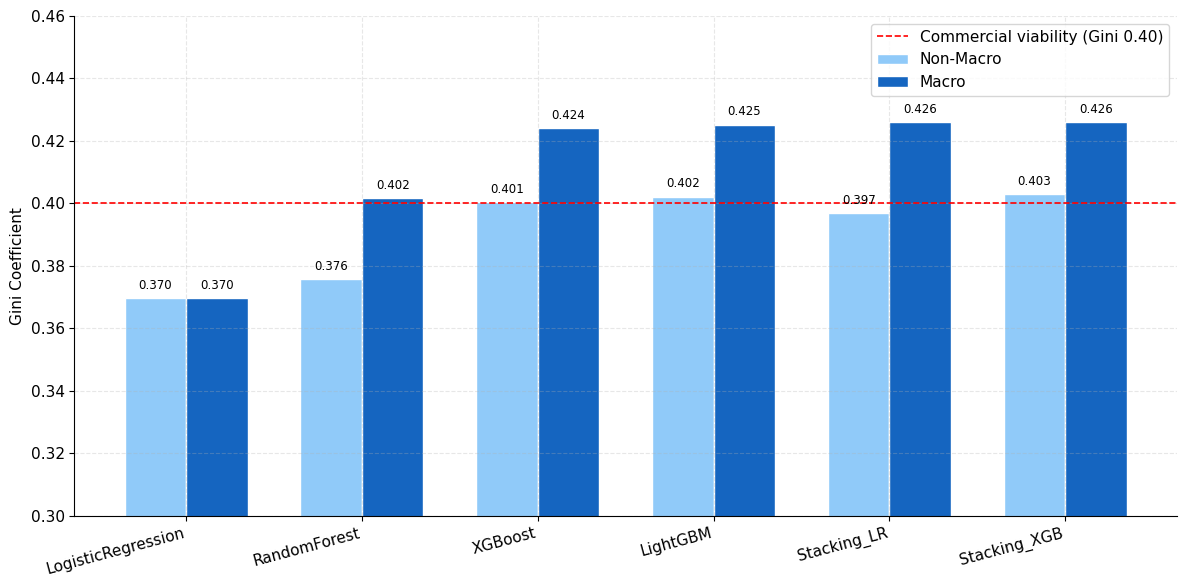

In [ ]:
models = ['LogisticRegression', 'RandomForest', 'XGBoost', 'LightGBM', 'Stacking_LR', 'Stacking_XGB']

nonmacro_vals = [0.3698, 0.3757, 0.4005, 0.4022, 0.3970, 0.4029]
macro_vals    = [0.3698, 0.4017, 0.4241, 0.4252, 0.4261, 0.4260]

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, nonmacro_vals, width, label='Non-Macro', color='#90CAF9', edgecolor='white')
bars2 = ax.bar(x + width/2, macro_vals,    width, label='Macro',     color='#1565C0', edgecolor='white')

ax.axhline(0.40, color='red', linestyle='--', linewidth=1.2, label='Commercial viability (Gini 0.40)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylabel('Gini Coefficient')
ax.set_ylim(0.30, 0.46)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)

plt.tight_layout()
plt.show()

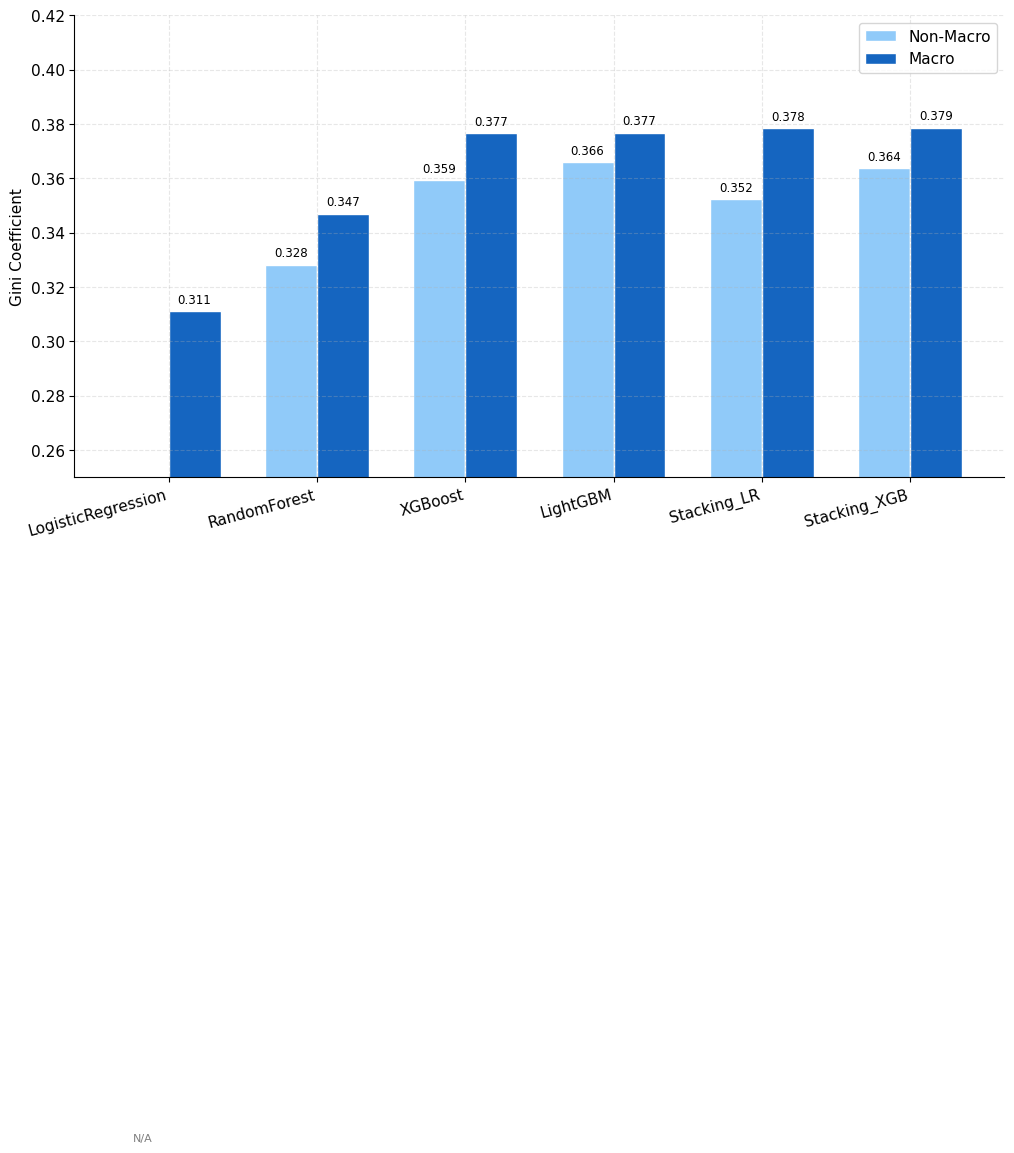

In [ ]:
models = ['LogisticRegression', 'RandomForest', 'XGBoost', 'LightGBM', 'Stacking_LR', 'Stacking_XGB']

nonmacro_vals = [0.0,    0.3282, 0.3593, 0.3658, 0.3523, 0.3636]
macro_vals    = [0.3110, 0.3470, 0.3765, 0.3767, 0.3784, 0.3785]
has_nonmacro  = [False,  True,   True,   True,   True,   True  ]

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, nonmacro_vals, width, label='Non-Macro', color='#90CAF9', edgecolor='white')
bars2 = ax.bar(x + width/2, macro_vals,    width, label='Macro',     color='#1565C0', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylabel('Gini Coefficient')
ax.set_ylim(0.25, 0.42)
ax.legend()

for bar, has in zip(bars1, has_nonmacro):
    if has:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)
    else:
        ax.text(bar.get_x() + bar.get_width()/2, 0.005,
                'N/A', ha='center', va='bottom', fontsize=8, color='gray')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)

plt.tight_layout()
plt.show()

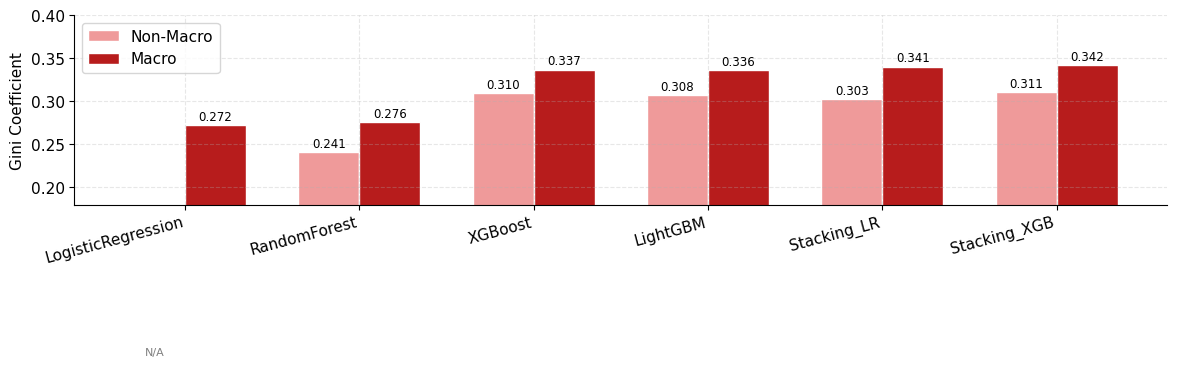

In [ ]:
models = ['LogisticRegression', 'RandomForest', 'XGBoost', 'LightGBM', 'Stacking_LR', 'Stacking_XGB']

nonmacro_vals = [0.0,    0.2408, 0.3099, 0.3079, 0.3030, 0.3114]
macro_vals    = [0.2722, 0.2764, 0.3371, 0.3363, 0.3405, 0.3421]
has_nonmacro  = [False,  True,   True,   True,   True,   True  ]

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, nonmacro_vals, width, label='Non-Macro', color='#EF9A9A', edgecolor='white')
bars2 = ax.bar(x + width/2, macro_vals,    width, label='Macro',     color='#B71C1C', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylabel('Gini Coefficient')
ax.set_ylim(0.18, 0.40)
ax.legend()

for bar, has in zip(bars1, has_nonmacro):
    if has:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)
    else:
        ax.text(bar.get_x() + bar.get_width()/2, 0.003,
                'N/A', ha='center', va='bottom', fontsize=8, color='gray')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)

plt.tight_layout()
plt.show()

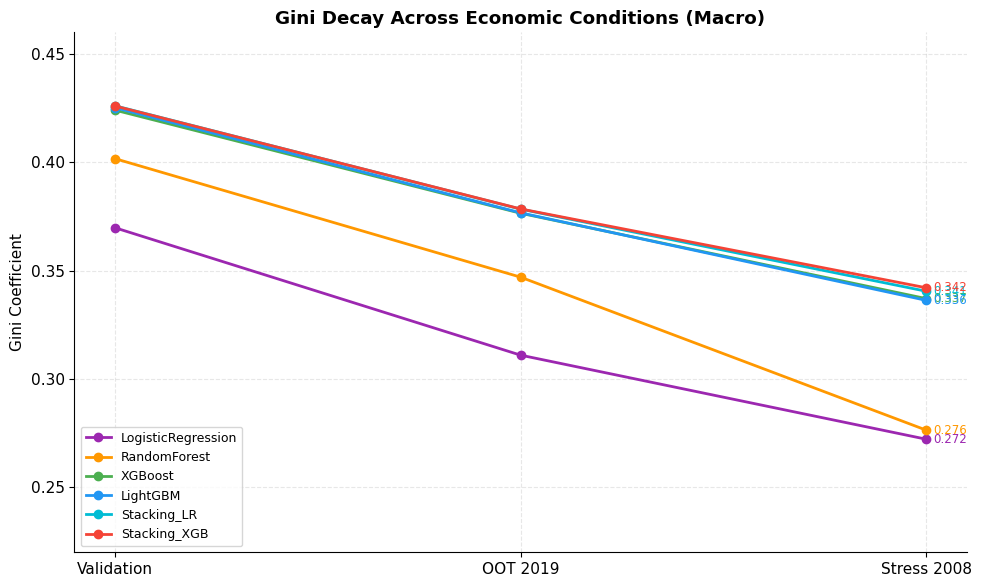

In [ ]:
models_decay = {
    'LogisticRegression': [0.3698, 0.3110, 0.2722],
    'RandomForest':       [0.4017, 0.3470, 0.2764],
    'XGBoost':            [0.4241, 0.3765, 0.3371],
    'LightGBM':           [0.4252, 0.3767, 0.3363],
    'Stacking_LR':        [0.4261, 0.3784, 0.3405],
    'Stacking_XGB':       [0.4260, 0.3785, 0.3421],
}

split_labels = ['Validation', 'OOT 2019', 'Stress 2008']

fig, ax = plt.subplots(figsize=(10, 6))

for model, ginis in models_decay.items():
    ax.plot(split_labels, ginis, marker='o', linewidth=2,
            color=COLORS[model], label=model)
    ax.annotate(f'{ginis[-1]:.3f}',
                xy=(split_labels[-1], ginis[-1]),
                xytext=(5, 0), textcoords='offset points',
                fontsize=8.5, color=COLORS[model], va='center')


ax.set_ylabel('Gini Coefficient')
ax.set_title('Gini Decay Across Economic Conditions (Macro)', fontweight='bold')
ax.set_ylim(0.22, 0.46)
ax.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()

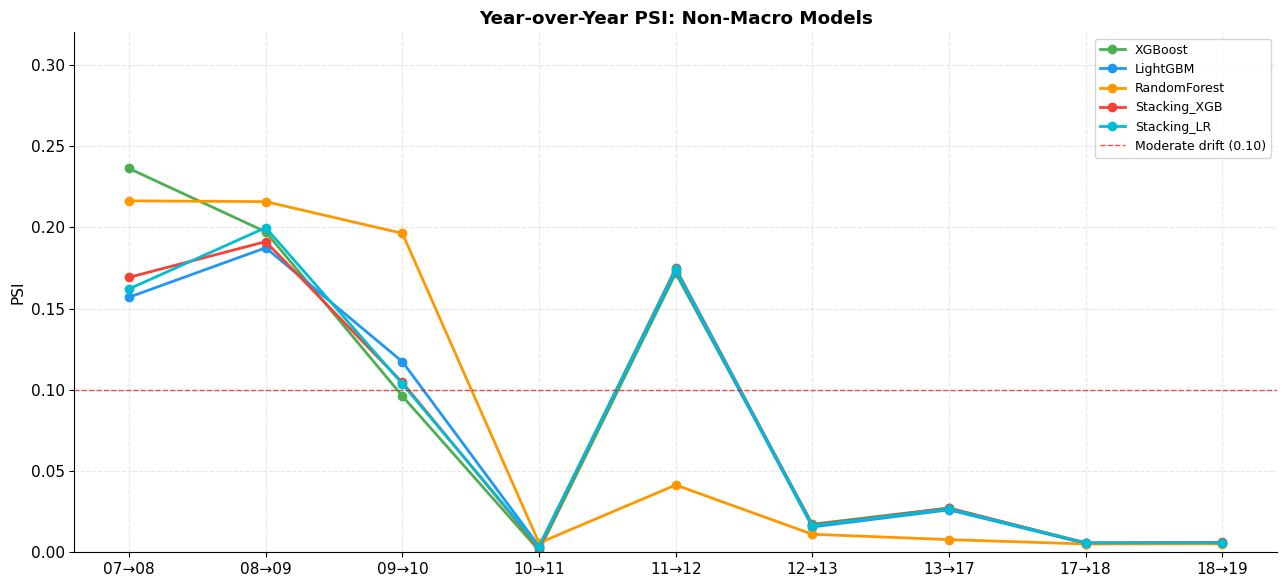

In [ ]:
transitions = ['07→08','08→09','09→10','10→11','11→12','12→13','13→17','17→18','18→19']

nonmacro_psi = {
    'XGBoost':      [0.2362, 0.1972, 0.0961, 0.0011, 0.1717, 0.0173, 0.0272, 0.0054, 0.0059],
    'LightGBM':     [0.1570, 0.1874, 0.1173, 0.0037, 0.1732, 0.0156, 0.0261, 0.0055, 0.0058],
    'RandomForest': [0.2163, 0.2158, 0.1963, 0.0057, 0.0414, 0.0111, 0.0078, 0.0051, 0.0052],
    'Stacking_XGB': [0.1692, 0.1912, 0.1045, 0.0025, 0.1748, 0.0168, 0.0272, 0.0058, 0.0061],
    'Stacking_LR':  [0.1621, 0.1998, 0.1036, 0.0035, 0.1741, 0.0164, 0.0267, 0.0058, 0.0058],
}

fig, ax = plt.subplots(figsize=(13, 6))

for model, psi_vals in nonmacro_psi.items():
    ax.plot(transitions, psi_vals, marker='o', linewidth=2,
            color=COLORS[model], label=model)

ax.axhline(0.10, color='red', linestyle='--', linewidth=1.0,
           label='Moderate drift (0.10)', alpha=0.7)
ax.set_ylabel('PSI')
ax.set_title('Year-over-Year PSI: Non-Macro Models', fontweight='bold')
ax.set_ylim(0, 0.32)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

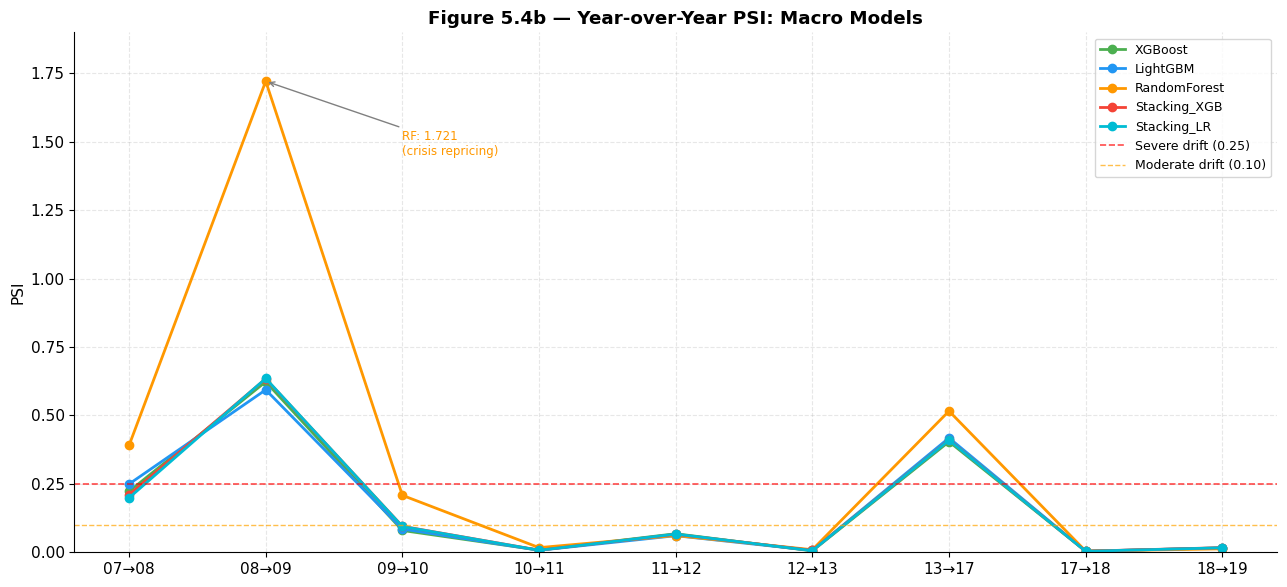

In [ ]:
macro_psi = {
    'XGBoost':      [0.2226, 0.6231, 0.0796, 0.0080, 0.0678, 0.0051, 0.4042, 0.0037, 0.0160],
    'LightGBM':     [0.2494, 0.5937, 0.0851, 0.0073, 0.0606, 0.0068, 0.4179, 0.0040, 0.0160],
    'RandomForest': [0.3906, 1.7213, 0.2081, 0.0170, 0.0612, 0.0094, 0.5160, 0.0043, 0.0126],
    'Stacking_XGB': [0.2104, 0.6339, 0.0949, 0.0077, 0.0656, 0.0070, 0.4103, 0.0040, 0.0168],
    'Stacking_LR':  [0.1989, 0.6352, 0.0943, 0.0074, 0.0664, 0.0061, 0.4094, 0.0036, 0.0164],
}

fig, ax = plt.subplots(figsize=(13, 6))

for model, psi_vals in macro_psi.items():
    ax.plot(transitions, psi_vals, marker='o', linewidth=2,
            color=COLORS[model], label=model)

ax.axhline(0.25, color='red',    linestyle='--', linewidth=1.2,
           label='Severe drift (0.25)',   alpha=0.7)
ax.axhline(0.10, color='orange', linestyle='--', linewidth=1.0,
           label='Moderate drift (0.10)', alpha=0.7)

ax.annotate('RF: 1.721\n(crisis repricing)',
            xy=('08→09', 1.7213),
            xytext=('09→10', 1.45),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=8.5, color=COLORS['RandomForest'])

ax.set_ylabel('PSI')
ax.set_title('Year-over-Year PSI: Macro Models', fontweight='bold')
ax.set_ylim(0, 1.90)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

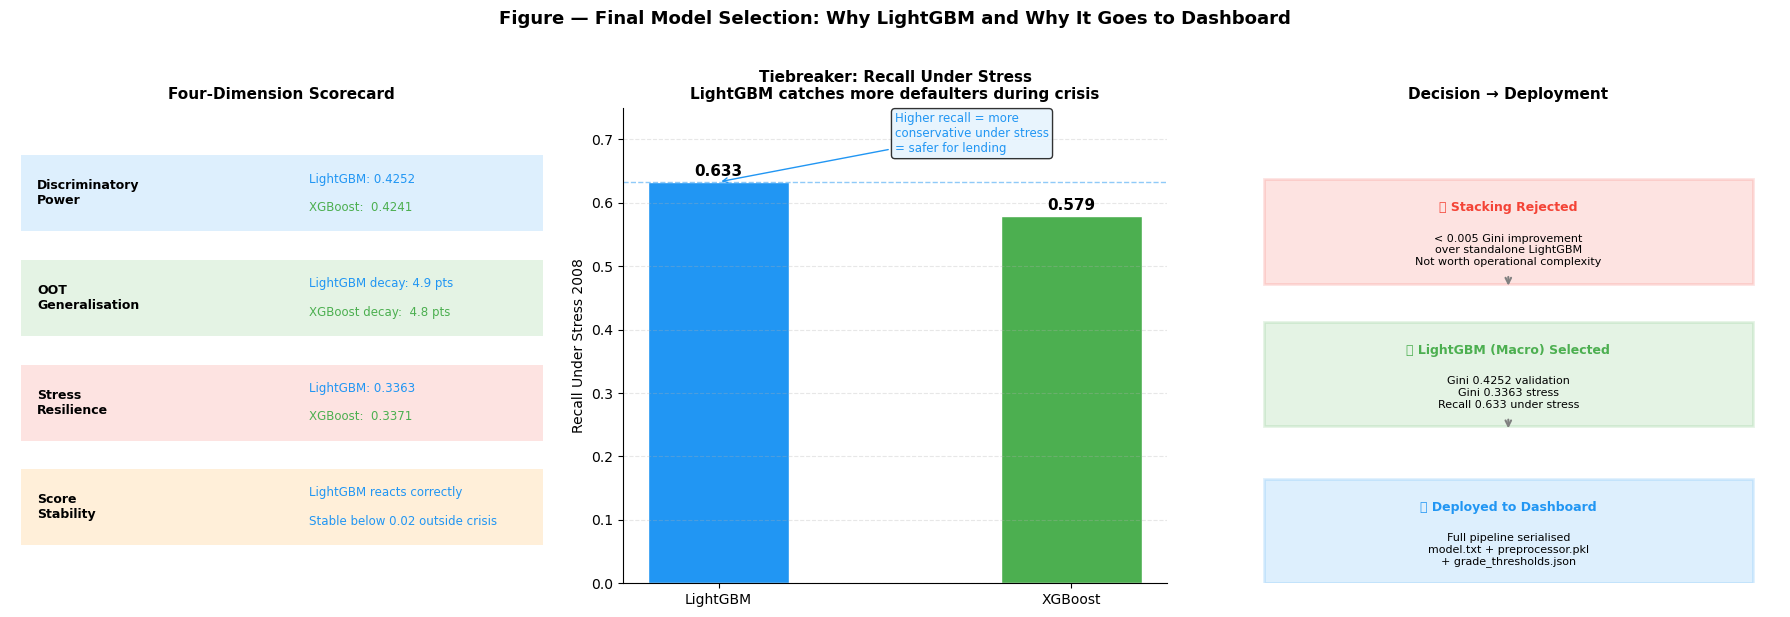

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Panel 1: Four-dimension scorecard ──
ax = axes[0]
ax.axis('off')

dimensions = ['Discriminatory\nPower', 'OOT\nGeneralisation',
              'Stress\nResilience', 'Score\nStability']
lgbm_scores = [0.4252, 0.3767, 0.3363, None]
xgb_scores  = [0.4241, 0.3765, 0.3371, None]

y_pos = [0.82, 0.60, 0.38, 0.16]
colors_dim = ['#2196F3', '#4CAF50', '#F44336', '#FF9800']

for i, (dim, y, col) in enumerate(zip(dimensions, y_pos, colors_dim)):
    ax.add_patch(plt.Rectangle((0.02, y-0.08), 0.96, 0.16,
                                facecolor=col, alpha=0.15,
                                transform=ax.transAxes))
    ax.text(0.05, y, dim, transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='center')

    if i == 0:
        ax.text(0.55, y+0.03, f'LightGBM: {lgbm_scores[i]}',
                transform=ax.transAxes, fontsize=8.5, va='center', color='#2196F3')
        ax.text(0.55, y-0.03, f'XGBoost:  {xgb_scores[i]}',
                transform=ax.transAxes, fontsize=8.5, va='center', color='#4CAF50')
    elif i == 1:
        ax.text(0.55, y+0.03, f'LightGBM decay: 4.9 pts',
                transform=ax.transAxes, fontsize=8.5, va='center', color='#2196F3')
        ax.text(0.55, y-0.03, f'XGBoost decay:  4.8 pts',
                transform=ax.transAxes, fontsize=8.5, va='center', color='#4CAF50')
    elif i == 2:
        ax.text(0.55, y+0.03, f'LightGBM: {lgbm_scores[i]}',
                transform=ax.transAxes, fontsize=8.5, va='center', color='#2196F3')
        ax.text(0.55, y-0.03, f'XGBoost:  {xgb_scores[i]}',
                transform=ax.transAxes, fontsize=8.5, va='center', color='#4CAF50')
    elif i == 3:
        ax.text(0.55, y+0.03, 'LightGBM reacts correctly',
                transform=ax.transAxes, fontsize=8.5, va='center', color='#2196F3')
        ax.text(0.55, y-0.03, 'Stable below 0.02 outside crisis',
                transform=ax.transAxes, fontsize=8.5, va='center', color='#2196F3')

ax.set_title('Four-Dimension Scorecard', fontweight='bold', fontsize=11)

# ── Panel 2: Recall under stress tiebreaker ──
ax = axes[1]

models_recall = ['LightGBM', 'XGBoost']
recall_vals   = [0.633, 0.579]
colors_recall = ['#2196F3', '#4CAF50']

bars = ax.bar(models_recall, recall_vals, color=colors_recall,
              edgecolor='white', width=0.4)

for bar, val in zip(bars, recall_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_ylabel('Recall Under Stress 2008')
ax.set_title('Tiebreaker: Recall Under Stress\nLightGBM catches more defaulters during crisis',
             fontweight='bold', fontsize=11)
ax.set_ylim(0, 0.75)
ax.axhline(0.633, color='#2196F3', linestyle='--', alpha=0.5, linewidth=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')

ax.annotate('Higher recall = more\nconservative under stress\n= safer for lending',
            xy=(0, 0.633), xytext=(0.5, 0.68),
            fontsize=8.5, color='#2196F3',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#E3F2FD', alpha=0.8),
            arrowprops=dict(arrowstyle='->', color='#2196F3'))

# ── Panel 3: Why not stacking → goes to dashboard ──
ax = axes[2]
ax.axis('off')

steps = [
    ('❌ Stacking Rejected', '#F44336',
     '< 0.005 Gini improvement\nover standalone LightGBM\nNot worth operational complexity'),
    ('✅ LightGBM (Macro) Selected', '#4CAF50',
     'Gini 0.4252 validation\nGini 0.3363 stress\nRecall 0.633 under stress'),
    ('🚀 Deployed to Dashboard', '#2196F3',
     'Full pipeline serialised\nmodel.txt + preprocessor.pkl\n+ grade_thresholds.json'),
]

y_positions = [0.75, 0.45, 0.12]

for (title, color, desc), y in zip(steps, y_positions):
    ax.add_patch(plt.Rectangle((0.05, y-0.12), 0.90, 0.22,
                                facecolor=color, alpha=0.15,
                                transform=ax.transAxes,
                                linewidth=2, edgecolor=color))
    ax.text(0.50, y+0.04, title, transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='center',
            ha='center', color=color)
    ax.text(0.50, y-0.05, desc, transform=ax.transAxes,
            fontsize=8, va='center', ha='center', color='black')

    if y != y_positions[-1]:
        ax.annotate('', xy=(0.5, y-0.13), xytext=(0.5, y-0.10),
                    xycoords='axes fraction', textcoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax.set_title('Decision → Deployment', fontweight='bold', fontsize=11)

fig.suptitle('Figure — Final Model Selection: Why LightGBM and Why It Goes to Dashboard',
             fontweight='bold', fontsize=13, y=1.02)

plt.tight_layout()
plt.show()

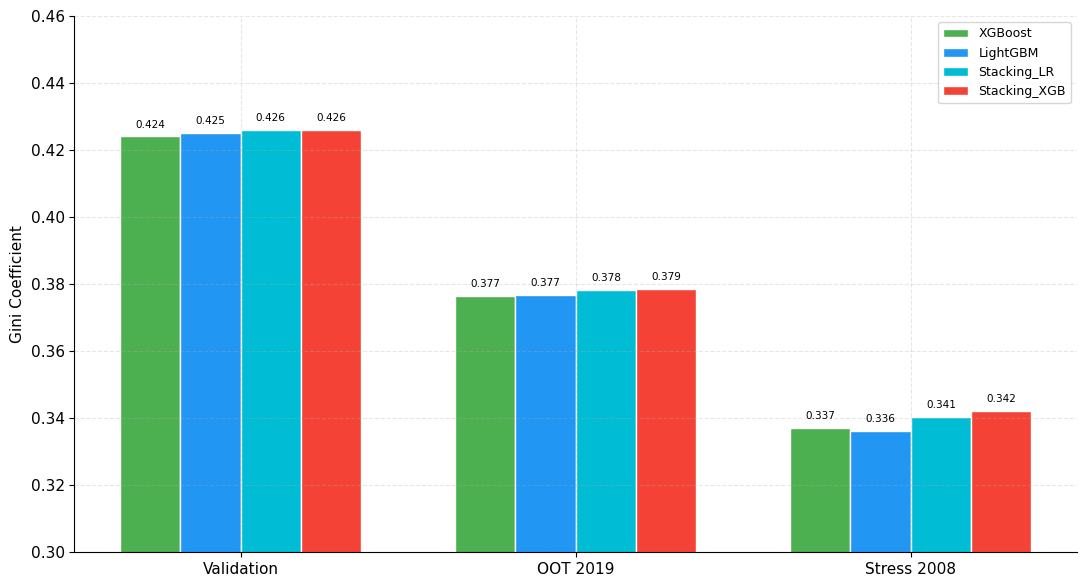

In [ ]:
models_55    = ['XGBoost', 'LightGBM', 'Stacking_LR', 'Stacking_XGB']
split_labels = ['Validation', 'OOT 2019', 'Stress 2008']

gini_55 = {
    'XGBoost':     [0.4241, 0.3765, 0.3371],
    'LightGBM':    [0.4252, 0.3767, 0.3363],
    'Stacking_LR': [0.4261, 0.3784, 0.3405],
    'Stacking_XGB':[0.4260, 0.3785, 0.3421],
}

x       = np.arange(len(split_labels))
width   = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]

fig, ax = plt.subplots(figsize=(11, 6))

for i, model in enumerate(models_55):
    bars = ax.bar(x + offsets[i] * width, gini_55[model], width,
                  label=model, color=COLORS[model], edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(split_labels)
ax.set_ylabel('Gini Coefficient')
ax.set_ylim(0.30, 0.46)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# ============================================================
# Table 5.1 — Full Validation Set Performance Metrics
# ============================================================

data = {
    'Model': [
        'LogisticRegression', 'LogisticRegression',
        'RandomForest',       'RandomForest',
        'XGBoost',            'XGBoost',
        'LightGBM',           'LightGBM',
        'Stacking_LR',        'Stacking_LR',
        'Stacking_XGB',       'Stacking_XGB',
    ],
    'Config': [
        'Non-Macro', 'Macro',
        'Non-Macro', 'Macro',
        'Non-Macro', 'Macro',
        'Non-Macro', 'Macro',
        'Non-Macro', 'Macro',
        'Non-Macro', 'Macro',
    ],
    'AUC':       [0.6849, 0.6849, 0.6878, 0.7008, 0.7002, 0.7120, 0.7011, 0.7126, 0.6985, 0.7131, 0.7015, 0.7130],
    'Gini':      [0.3698, 0.3698, 0.3757, 0.4017, 0.4005, 0.4241, 0.4022, 0.4252, 0.3970, 0.4261, 0.4029, 0.4260],
    'KS':        [0.2678, 0.2678, 0.2704, 0.2874, 0.2876, 0.3050, 0.2918, 0.3070, 0.2864, 0.3079, 0.2897, 0.3067],
    'Precision': [0.3001, 0.3001, 0.3027, 0.3135, 0.3212, 0.3298, 0.3194, 0.3190, 0.3165, 0.3264, 0.3189, 0.3357],
    'Recall':    [0.6381, 0.6381, 0.6337, 0.6316, 0.6339, 0.6424, 0.6498, 0.6851, 0.6483, 0.6598, 0.6442, 0.6218],
    'F1':        [0.4082, 0.4082, 0.4097, 0.4190, 0.4263, 0.4359, 0.4283, 0.4353, 0.4253, 0.4368, 0.4266, 0.4360],
}

df_table = pd.DataFrame(data)

for col in ['AUC', 'Gini', 'KS', 'Precision', 'Recall', 'F1']:
    df_table[col] = df_table[col].map('{:.4f}'.format)

styled = (
    df_table.style
    .set_caption('Table 5.1 — Full Validation Set Performance Metrics: Non-Macro vs Macro')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('padding-bottom', '8px'),
                   ('caption-side', 'top')]},
        {'selector': 'thead th',
         'props': [('background-color', 'transparent'),
                   ('color', 'white'),
                   ('font-weight', 'bold'),
                   ('text-align', 'center'),
                   ('padding', '8px 12px'),
                   ('border-top', '2px solid black'),
                   ('border-bottom', '1px solid black')]},
        {'selector': 'tbody td',
         'props': [('background-color', 'transparent'),
                   ('text-align', 'center'),
                   ('padding', '6px 12px'),
                   ('border', 'none')]},
        {'selector': 'tbody tr:last-child td',
         'props': [('border-bottom', '2px solid black')]},
        {'selector': 'table',
         'props': [('border-collapse', 'collapse'),
                   ('font-family', 'Arial, sans-serif'),
                   ('font-size', '12px'),
                   ('width', '100%')]},
    ])
    .hide(axis='index')
)

display(styled)

Model,Config,AUC,Gini,KS,Precision,Recall,F1
LogisticRegression,Non-Macro,0.6849,0.3698,0.2678,0.3001,0.6381,0.4082
LogisticRegression,Macro,0.6849,0.3698,0.2678,0.3001,0.6381,0.4082
RandomForest,Non-Macro,0.6878,0.3757,0.2704,0.3027,0.6337,0.4097
RandomForest,Macro,0.7008,0.4017,0.2874,0.3135,0.6316,0.4190
XGBoost,Non-Macro,0.7002,0.4005,0.2876,0.3212,0.6339,0.4263
XGBoost,Macro,0.7120,0.4241,0.3050,0.3298,0.6424,0.4359
LightGBM,Non-Macro,0.7011,0.4022,0.2918,0.3194,0.6498,0.4283
LightGBM,Macro,0.7126,0.4252,0.3070,0.3190,0.6851,0.4353
Stacking_LR,Non-Macro,0.6985,0.3970,0.2864,0.3165,0.6483,0.4253
Stacking_LR,Macro,0.7131,0.4261,0.3079,0.3264,0.6598,0.4368


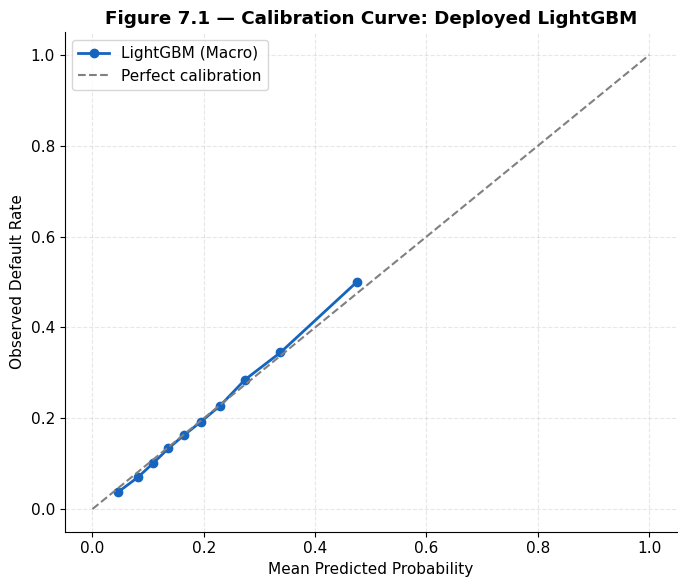

Mean predicted: [0.0464 0.0818 0.1094 0.1361 0.1639 0.1943 0.2297 0.274  0.3376 0.4744]
Observed rates: [0.0377 0.0702 0.1014 0.1333 0.1622 0.1918 0.2279 0.2849 0.3448 0.4996]


In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np

# Use the macro validation set and deployed model
valid_prob = deploy_lgbm_model.predict_proba(X_valid_deploy)[:, 1]

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_valid, valid_prob, n_bins=10, strategy='quantile'
)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(mean_predicted_value, fraction_of_positives,
        marker='o', linewidth=2, color='#1565C0', label='LightGBM (Macro)')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Observed Default Rate')
ax.set_title('Figure 7.1 — Calibration Curve: Deployed LightGBM', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("Mean predicted:", mean_predicted_value.round(4))
print("Observed rates:", fraction_of_positives.round(4))

In [ ]:
from sklearn.calibration import calibration_curve
import numpy as np

valid_prob_deploy = deploy_lgbm_model.predict_proba(X_valid_deploy)[:, 1]

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_valid, valid_prob_deploy, n_bins=10, strategy='quantile'
)

print("Mean predicted : ", np.round(mean_predicted_value, 4))
print("Observed rates : ", np.round(fraction_of_positives, 4))
print()
print("Max absolute gap:", round(
    float(np.max(np.abs(mean_predicted_value - fraction_of_positives))), 4
))
print("Mean absolute gap:", round(
    float(np.mean(np.abs(mean_predicted_value - fraction_of_positives))), 4
))
print()
# Direction: positive = overestimate, negative = underestimate
gaps = mean_predicted_value - fraction_of_positives
for i, (mp, ob, g) in enumerate(zip(mean_predicted_value, fraction_of_positives, gaps)):
    direction = "overestimate" if g > 0 else "underestimate"
    print(f"Decile {i+1:2d}: predicted={mp:.4f}  observed={ob:.4f}  gap={g:+.4f}  ({direction})")

Mean predicted :  [0.0464 0.0818 0.1094 0.1361 0.1639 0.1943 0.2297 0.274  0.3376 0.4744]
Observed rates :  [0.0377 0.0702 0.1014 0.1333 0.1622 0.1918 0.2279 0.2849 0.3448 0.4996]

Max absolute gap: 0.0252
Mean absolute gap: 0.008

Decile  1: predicted=0.0464  observed=0.0377  gap=+0.0088  (overestimate)
Decile  2: predicted=0.0818  observed=0.0702  gap=+0.0115  (overestimate)
Decile  3: predicted=0.1094  observed=0.1014  gap=+0.0080  (overestimate)
Decile  4: predicted=0.1361  observed=0.1333  gap=+0.0028  (overestimate)
Decile  5: predicted=0.1639  observed=0.1622  gap=+0.0017  (overestimate)
Decile  6: predicted=0.1943  observed=0.1918  gap=+0.0025  (overestimate)
Decile  7: predicted=0.2297  observed=0.2279  gap=+0.0018  (overestimate)
Decile  8: predicted=0.2740  observed=0.2849  gap=-0.0109  (underestimate)
Decile  9: predicted=0.3376  observed=0.3448  gap=-0.0072  (underestimate)
Decile 10: predicted=0.4744  observed=0.4996  gap=-0.0252  (underestimate)


In [ ]:
# Already computed in BLOCK 40B — just display cleanly
print("Grade thresholds:", np.round(grade_thresholds, 4))
print()
display(grade_summary)
print()
print("Monotonic increasing:", grade_summary["obs_default_rate"].is_monotonic_increasing)
print()
print("Grade to recommendation mapping:")
for g in ["A", "B", "C", "D", "E", "F"]:
    rec = get_recommendation_from_grade(g)
    print(f"  Grade {g} -> {rec}")

Grade thresholds: [0.088 0.134 0.181 0.238 0.324]



,grade,n,share,avg_pred_pd,min_pd,max_pd,obs_default_rate
0,A,21977,0.1657,0.0594,0.0058,0.0880,0.0491
1,B,22338,0.1684,0.1112,0.0880,0.1340,0.1022
2,C,22033,0.1661,0.1570,0.1340,0.1810,0.1547
3,D,22018,0.1660,0.2081,0.1810,0.2380,0.2059
4,E,22039,0.1662,0.2768,0.2380,0.3240,0.2858
5,F,22206,0.1675,0.4236,0.3240,0.8632,0.4407



Monotonic increasing: True

Grade to recommendation mapping:
  Grade A -> Approve
  Grade B -> Approve
  Grade C -> Review
  Grade D -> Review
  Grade E -> Manual Review
  Grade F -> Manual Review


In [ ]:
for case_name, profile in test_cases.items():
    pd_hat, row_df, contrib_df_raw = get_single_prediction_explanation(
        profile, "2018-01-01", top_n=20
    )

    grouped = group_shap_contributions(
        contrib_df_raw, cat_cols=cat_cols_final, num_cols=num_cols_final
    )

    reason_groups = classify_reason_groups(grouped)

    risk_bucket = (
        "Low Risk"      if pd_hat < 0.05 else
        "Moderate Risk" if pd_hat < 0.10 else
        "Elevated Risk" if pd_hat < 0.20 else
        "High Risk"
    )

    grade = get_credit_grade(pd_hat)
    rec   = get_recommendation_from_grade(grade)

    print(f"{'='*60}")
    print(f"Case: {case_name}")
    print(f"Predicted PD : {pd_hat:.4f}")
    print(f"Risk bucket  : {risk_bucket}")
    print(f"Grade        : {grade}")
    print(f"Recommendation: {rec}")
    print()
    print("Grouped SHAP contributions:")
    display(grouped)
    print()
    print("Reason groups:", reason_groups)
    print()
    paragraph = make_explanation_paragraph(reason_groups, pd_hat, risk_bucket)
    print("Narrative:", paragraph)
    print()

Case: low_risk_case
Predicted PD : 0.0741
Risk bucket  : Moderate Risk
Grade        : A
Recommendation: Approve

Grouped SHAP contributions:


,raw_feature,shap_value,abs_shap,pretty_feature
0,fico_range_low,-0.547114,0.547114,FICO score
1,term,0.501923,0.501923,Loan term
2,annual_inc,-0.311050,0.311050,Annual income
3,loan_amnt,-0.215472,0.215472,Loan amount
4,dti,-0.210535,0.210535,Debt-to-income ratio
5,inq_last_6mths,-0.165471,0.165471,inq_last_6mths
6,revol_util,-0.104299,0.104299,Revolving utilization
7,home_ownership,-0.096187,0.096187,Home ownership
8,mort_acc,-0.083609,0.083609,mort_acc
9,Inflation_L6,0.068553,0.068553,Inflation backdrop



Reason groups: {'high_risk_factors': ['Loan term', 'Inflation backdrop'], 'medium_risk_factors': ['Home price backdrop', 'Open accounts'], 'risk_reducing_factors': ['FICO score', 'Annual income', 'Loan amount']}

Narrative: This applicant is classified as Moderate Risk with an estimated probability of default of 7.4%. The strongest contributors to higher risk are Loan term and Inflation backdrop. Additional moderate risk pressure comes from Home price backdrop and Open accounts. However, some factors help reduce the predicted risk, particularly FICO score, Annual income, and Loan amount.

Case: medium_risk_case
Predicted PD : 0.3942
Risk bucket  : High Risk
Grade        : F
Recommendation: Manual Review

Grouped SHAP contributions:


,raw_feature,shap_value,abs_shap,pretty_feature
0,term,0.450701,0.450701,Loan term
1,fico_range_low,0.241972,0.241972,FICO score
2,mort_acc,0.211006,0.211006,mort_acc
3,inq_last_6mths,0.125460,0.125460,inq_last_6mths
4,home_ownership,0.124260,0.124260,Home ownership
5,purpose,-0.099691,0.099691,Loan purpose
6,Inflation_L6,0.095499,0.095499,Inflation backdrop
7,HomePrices_L12,0.071658,0.071658,Home price backdrop
8,dti,-0.067092,0.067092,Debt-to-income ratio
9,FedFunds_L3,0.037578,0.037578,Fed funds backdrop



Reason groups: {'high_risk_factors': ['Loan term', 'FICO score'], 'medium_risk_factors': ['mort_acc', 'inq_last_6mths'], 'risk_reducing_factors': ['Loan purpose', 'Debt-to-income ratio', 'Annual income']}

Narrative: This applicant is classified as High Risk with an estimated probability of default of 39.4%. The strongest contributors to higher risk are Loan term and FICO score. Additional moderate risk pressure comes from mort_acc and inq_last_6mths. However, some factors help reduce the predicted risk, particularly Loan purpose, Debt-to-income ratio, and Annual income.

Case: high_risk_case
Predicted PD : 0.8290
Risk bucket  : High Risk
Grade        : F
Recommendation: Manual Review

Grouped SHAP contributions:


,raw_feature,shap_value,abs_shap,pretty_feature
0,purpose,0.622153,0.622153,Loan purpose
1,inq_last_6mths,0.516076,0.516076,inq_last_6mths
2,term,0.435550,0.435550,Loan term
3,fico_range_low,0.318495,0.318495,FICO score
4,loan_amnt,0.275424,0.275424,Loan amount
5,home_ownership,0.191673,0.191673,Home ownership
6,mort_acc,0.180996,0.180996,mort_acc
7,revol_util,0.165100,0.165100,Revolving utilization
8,open_acc,-0.160023,0.160023,Open accounts
9,dti,0.118751,0.118751,Debt-to-income ratio



Reason groups: {'high_risk_factors': ['Loan purpose', 'inq_last_6mths'], 'medium_risk_factors': ['Loan term', 'FICO score'], 'risk_reducing_factors': ['Open accounts', 'revol_bal']}

Narrative: This applicant is classified as High Risk with an estimated probability of default of 82.9%. The strongest contributors to higher risk are Loan purpose and inq_last_6mths. Additional moderate risk pressure comes from Loan term and FICO score. However, some factors help reduce the predicted risk, particularly Open accounts and revol_bal.



In [ ]:
import numpy as np
import pandas as pd

# Sample 5000 rows from validation set for speed
np.random.seed(42)
n_sample = min(5000, X_valid_deploy.shape[0])
idx = np.random.choice(X_valid_deploy.shape[0], n_sample, replace=False)

if hasattr(X_valid_deploy, 'toarray'):
    X_sample = X_valid_deploy[idx].toarray()
else:
    X_sample = X_valid_deploy[idx]

shap_values_global = deploy_explainer.shap_values(X_sample)

if isinstance(shap_values_global, list):
    sv_global = shap_values_global[1]
else:
    sv_global = shap_values_global

mean_abs_shap = np.abs(sv_global).mean(axis=0)

global_importance_df = pd.DataFrame({
    "feature": feature_names_transformed,
    "mean_abs_shap": mean_abs_shap
})

# Group to original feature names
global_importance_df["raw_feature"] = global_importance_df["feature"].apply(
    lambda x: get_raw_feature_name(x, cat_cols_final, num_cols_final)
)

global_grouped = (
    global_importance_df
    .groupby("raw_feature", as_index=False)
    .agg({"mean_abs_shap": "sum"})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

global_grouped["pretty_feature"] = global_grouped["raw_feature"].map(
    pretty_raw_name_map
).fillna(global_grouped["raw_feature"])

print("Global Feature Importance (mean absolute SHAP):")
display(global_grouped)

Global Feature Importance (mean absolute SHAP):


,raw_feature,mean_abs_shap,pretty_feature
0,term,0.283014,Loan term
1,fico_range_low,0.279344,FICO score
2,loan_amnt,0.203638,Loan amount
3,annual_inc,0.200817,Annual income
4,inq_last_6mths,0.153413,inq_last_6mths
5,purpose,0.137921,Loan purpose
6,mort_acc,0.123987,mort_acc
7,HomePrices_L12,0.112154,Home price backdrop
8,revol_util,0.108030,Revolving utilization
9,home_ownership,0.107299,Home ownership


In [ ]:
# Already in BLOCK 40 — display cleanly with organised output
print("Scenario Sensitivity — Base case: medium_risk_case, Date: 2018-01-01")
print()

base_pd, _ = predict_single_applicant(test_cases["medium_risk_case"], "2018-01-01")
print(f"Base case PD: {base_pd:.4f}  Grade: {get_credit_grade(base_pd)}")
print()

scenario_rows = []

for new_loan in [10000, 15000, 20000, 25000]:
    tmp = test_cases["medium_risk_case"].copy()
    tmp["loan_amnt"] = new_loan
    pd_hat, _ = predict_single_applicant(tmp, "2018-01-01")
    scenario_rows.append({
        "Variable": "Loan Amount",
        "Value": f"${new_loan:,}",
        "Predicted PD": round(pd_hat, 4),
        "Grade": get_credit_grade(pd_hat),
        "Change vs Base": f"{(pd_hat - base_pd)*100:+.2f} pts"
    })

for new_dti in [12.0, 18.0, 25.0, 32.0]:
    tmp = test_cases["medium_risk_case"].copy()
    tmp["dti"] = new_dti
    pd_hat, _ = predict_single_applicant(tmp, "2018-01-01")
    scenario_rows.append({
        "Variable": "DTI",
        "Value": f"{new_dti}%",
        "Predicted PD": round(pd_hat, 4),
        "Grade": get_credit_grade(pd_hat),
        "Change vs Base": f"{(pd_hat - base_pd)*100:+.2f} pts"
    })

for new_fico in [620, 680, 720, 760]:
    tmp = test_cases["medium_risk_case"].copy()
    tmp["fico_range_low"] = new_fico
    pd_hat, _ = predict_single_applicant(tmp, "2018-01-01")
    scenario_rows.append({
        "Variable": "FICO Score",
        "Value": str(new_fico),
        "Predicted PD": round(pd_hat, 4),
        "Grade": get_credit_grade(pd_hat),
        "Change vs Base": f"{(pd_hat - base_pd)*100:+.2f} pts"
    })

scenario_df = pd.DataFrame(scenario_rows)
display(scenario_df)

Scenario Sensitivity — Base case: medium_risk_case, Date: 2018-01-01

Base case PD: 0.3942  Grade: F



,Variable,Value,Predicted PD,Grade,Change vs Base
0,Loan Amount,"$10,000",0.3674,F,-2.68 pts
1,Loan Amount,"$15,000",0.3942,F,+0.00 pts
2,Loan Amount,"$20,000",0.4449,F,+5.07 pts
3,Loan Amount,"$25,000",0.4695,F,+7.53 pts
4,DTI,12.0%,0.3967,F,+0.25 pts
5,DTI,18.0%,0.3942,F,+0.00 pts
6,DTI,25.0%,0.4539,F,+5.97 pts
7,DTI,32.0%,0.4946,F,+10.04 pts
8,FICO Score,620,0.4431,F,+4.89 pts
9,FICO Score,680,0.3942,F,+0.00 pts


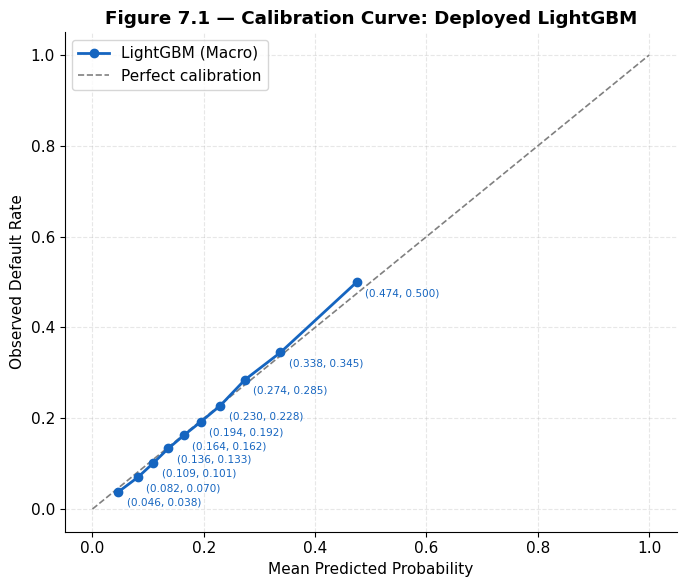

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(mean_predicted_value, fraction_of_positives,
        marker='o', linewidth=2, color='#1565C0',
        label='LightGBM (Macro)', zorder=3)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray',
        linewidth=1.2, label='Perfect calibration')

for mp, ob in zip(mean_predicted_value, fraction_of_positives):
    ax.annotate(f'({mp:.3f}, {ob:.3f})',
                xy=(mp, ob), xytext=(6, -10),
                textcoords='offset points', fontsize=7.5, color='#1565C0')

ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Observed Default Rate')
ax.set_title('Figure 7.1 — Calibration Curve: Deployed LightGBM', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

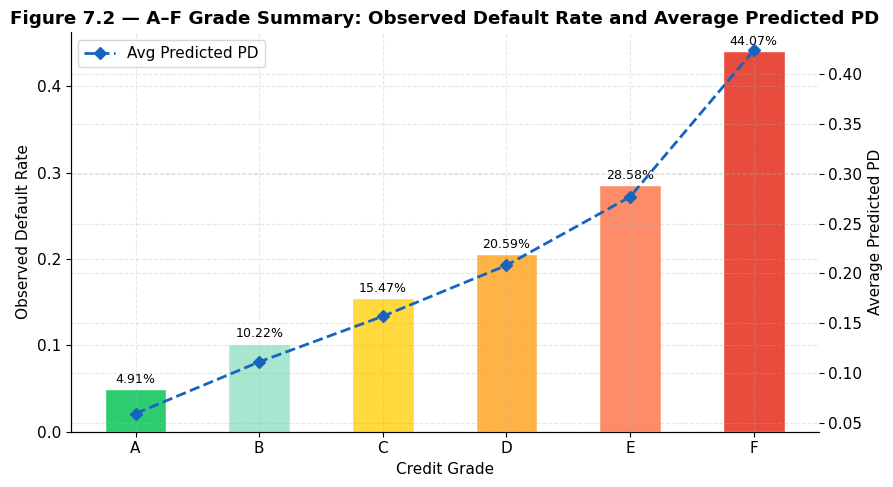

In [ ]:
fig, ax1 = plt.subplots(figsize=(9, 5))

grades = grade_summary["grade"].astype(str)
x = range(len(grades))

bars = ax1.bar(x, grade_summary["obs_default_rate"],
               color=['#2ecc71','#a8e6cf','#ffd93d','#ffb347','#ff8c69','#e74c3c'],
               edgecolor='white', width=0.5)

for bar, rate in zip(bars, grade_summary["obs_default_rate"]):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.004,
             f'{rate:.2%}', ha='center', va='bottom', fontsize=9)

ax2 = ax1.twinx()
ax2.plot(x, grade_summary["avg_pred_pd"],
         marker='D', color='#1565C0', linewidth=2,
         linestyle='--', label='Avg Predicted PD')

ax1.set_xticks(x)
ax1.set_xticklabels(grades)
ax1.set_xlabel('Credit Grade')
ax1.set_ylabel('Observed Default Rate')
ax2.set_ylabel('Average Predicted PD')
ax1.set_title('Figure 7.2 — A–F Grade Summary: Observed Default Rate and Average Predicted PD',
              fontweight='bold')
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

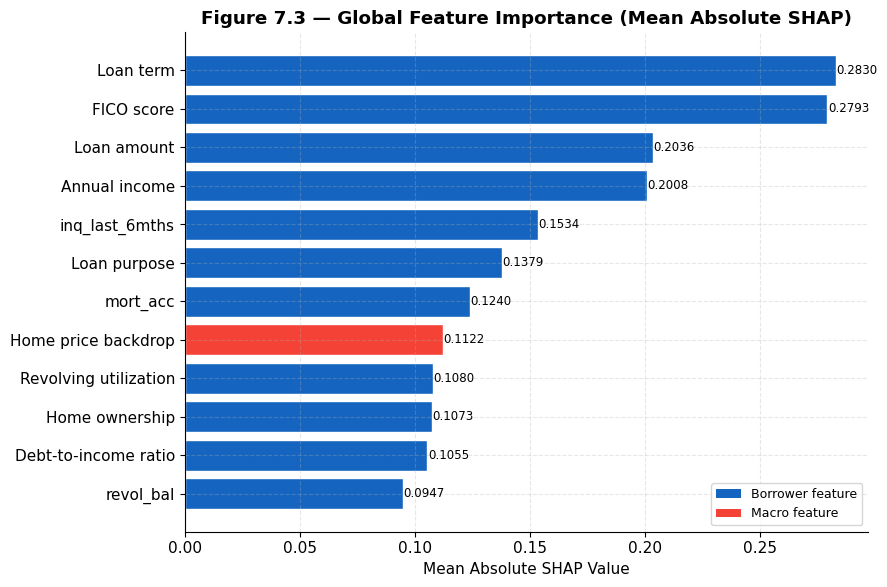

In [ ]:
plot_df = global_grouped.head(12).sort_values("mean_abs_shap", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))

colors = ['#F44336' if 'backdrop' in str(f).lower() else '#1565C0'
          for f in plot_df["pretty_feature"]]

ax.barh(plot_df["pretty_feature"], plot_df["mean_abs_shap"],
        color=colors, edgecolor='white')

for i, (val, feat) in enumerate(zip(plot_df["mean_abs_shap"], plot_df["pretty_feature"])):
    ax.text(val + 0.0002, i, f'{val:.4f}', va='center', fontsize=8.5)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1565C0', label='Borrower feature'),
    Patch(facecolor='#F44336', label='Macro feature'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.set_xlabel('Mean Absolute SHAP Value')
ax.set_title('Figure 7.3 — Global Feature Importance (Mean Absolute SHAP)', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

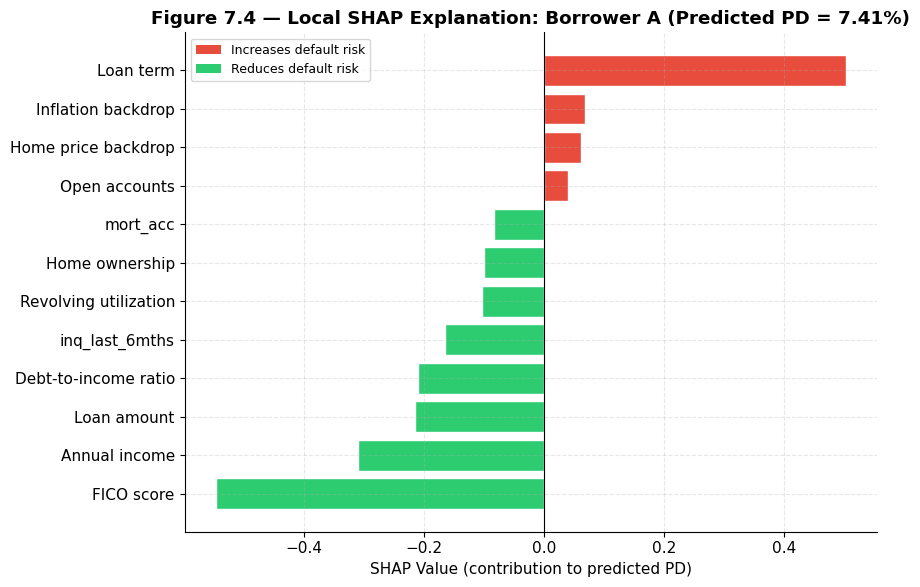

In [ ]:
pd_hat_a, _, contrib_raw_a = get_single_prediction_explanation(
    test_cases["low_risk_case"], "2018-01-01", top_n=30
)
grouped_a = group_shap_contributions(
    contrib_raw_a, cat_cols=cat_cols_final, num_cols=num_cols_final
)

plot_df = grouped_a.head(12).sort_values("shap_value", ascending=True)
colors  = ['#2ecc71' if v < 0 else '#e74c3c' for v in plot_df["shap_value"]]

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(plot_df["pretty_feature"], plot_df["shap_value"],
        color=colors, edgecolor='white')

ax.axvline(0, color='black', linewidth=0.8)

for i, val in enumerate(plot_df["shap_value"]):
    offset = 0.005 if val >= 0 else -0.005
    ha = 'left' if val >= 0 else 'right'

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Increases default risk'),
    Patch(facecolor='#2ecc71', label='Reduces default risk'),
]
ax.legend(handles=legend_elements, fontsize=9)

ax.set_xlabel('SHAP Value (contribution to predicted PD)')
ax.set_title(f'Figure 7.4 — Local SHAP Explanation: Borrower A (Predicted PD = {pd_hat_a:.2%})',
             fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

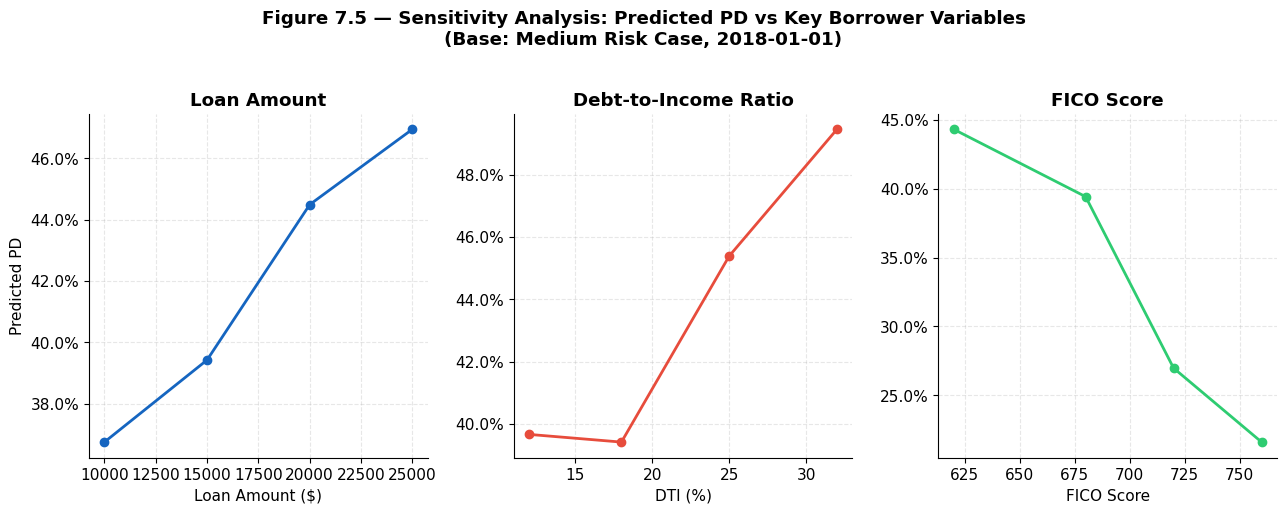

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

# Loan Amount
loan_vals = [10000, 15000, 20000, 25000]
loan_pds  = []
for v in loan_vals:
    tmp = test_cases["medium_risk_case"].copy()
    tmp["loan_amnt"] = v
    pd_hat, _ = predict_single_applicant(tmp, "2018-01-01")
    loan_pds.append(pd_hat)

axes[0].plot(loan_vals, loan_pds, marker='o', color='#1565C0', linewidth=2)
axes[0].set_xlabel('Loan Amount ($)')
axes[0].set_ylabel('Predicted PD')
axes[0].set_title('Loan Amount', fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# DTI
dti_vals = [12.0, 18.0, 25.0, 32.0]
dti_pds  = []
for v in dti_vals:
    tmp = test_cases["medium_risk_case"].copy()
    tmp["dti"] = v
    pd_hat, _ = predict_single_applicant(tmp, "2018-01-01")
    dti_pds.append(pd_hat)

axes[1].plot(dti_vals, dti_pds, marker='o', color='#e74c3c', linewidth=2)
axes[1].set_xlabel('DTI (%)')
axes[1].set_title('Debt-to-Income Ratio', fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# FICO
fico_vals = [620, 680, 720, 760]
fico_pds  = []
for v in fico_vals:
    tmp = test_cases["medium_risk_case"].copy()
    tmp["fico_range_low"] = v
    pd_hat, _ = predict_single_applicant(tmp, "2018-01-01")
    fico_pds.append(pd_hat)

axes[2].plot(fico_vals, fico_pds, marker='o', color='#2ecc71', linewidth=2)
axes[2].set_xlabel('FICO Score')
axes[2].set_title('FICO Score', fontweight='bold')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
axes[2].grid(True, alpha=0.3, linestyle='--')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

fig.suptitle('Figure 7.5 — Sensitivity Analysis: Predicted PD vs Key Borrower Variables\n(Base: Medium Risk Case, 2018-01-01)',
             fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

In [ ]:
borrower_b_modified = {
    "term": "36 months",
    "home_ownership": "RENT",
    "purpose": "credit_card",
    "emp_length": "3 years",
    "fico_range_low": 760,
    "loan_amnt": 15000,
    "dti": 18.0,
    "revol_util": 45.0,
    "annual_inc": 70000,
    "open_acc": 8,
    "delinq_2yrs": 0,
    "pub_rec": 0,
    "inq_last_6mths": 1,
    "mort_acc": 0,
    "revol_bal": 12000
}

pd_hat, _ = predict_single_applicant(borrower_b_modified, "2018-01-01")
print(f"Predicted PD: {pd_hat:.4f}")
print(f"Grade: {get_credit_grade(pd_hat)}")

Predicted PD: 0.2160
Grade: D


In [ ]:
# BLOCK 41 — save artifacts for Streamlit
deploy_lgbm_model.booster_.save_model("artifacts/model.txt")
joblib.dump(deploy_preprocessor, "artifacts/preprocessor.pkl")

['artifacts/preprocessor.pkl']

In [ ]:
# ============================================================
# Corrected test cases with logically derived DTI
# ============================================================

test_cases_corrected = {
    "low_risk_case": {
        "term": "36 months",
        "home_ownership": "MORTGAGE",
        "purpose": "debt_consolidation",
        "emp_length": "10+ years",
        "fico_range_low": 760,
        "loan_amnt": 8000,
        "dti": round((8000 / 120000) * 100, 1),      # 6.7%
        "revol_util": 22.0,
        "annual_inc": 120000,
        "open_acc": 12,
        "delinq_2yrs": 0,
        "pub_rec": 0,
        "inq_last_6mths": 0,
        "mort_acc": 2,
        "revol_bal": 8000
    },
    "medium_risk_case_modified": {
        # Borrower B: same as low risk but FICO 760, loan 15000
        "term": "36 months",
        "home_ownership": "MORTGAGE",
        "purpose": "debt_consolidation",
        "emp_length": "10+ years",
        "fico_range_low": 760,
        "loan_amnt": 15000,
        "dti": round((15000 / 120000) * 100, 1),     # 12.5%
        "revol_util": 22.0,
        "annual_inc": 120000,
        "open_acc": 12,
        "delinq_2yrs": 0,
        "pub_rec": 0,
        "inq_last_6mths": 0,
        "mort_acc": 2,
        "revol_bal": 8000
    },
    "high_risk_case": {
        "term": "60 months",
        "home_ownership": "RENT",
        "purpose": "small_business",
        "emp_length": "< 1 year",
        "fico_range_low": 610,
        "loan_amnt": 25000,
        "dti": round((25000 / 38000) * 100, 1),      # 65.8%
        "revol_util": 82.0,
        "annual_inc": 38000,
        "open_acc": 5,
        "delinq_2yrs": 2,
        "pub_rec": 1,
        "inq_last_6mths": 4,
        "mort_acc": 0,
        "revol_bal": 22000
    }
}

# Print all base case results
for name, profile in test_cases_corrected.items():
    pd_hat, _ = predict_single_applicant(profile, "2018-01-01")
    grade = get_credit_grade(pd_hat)
    rec = get_recommendation_from_grade(grade)
    print(f"{name}")
    print(f"  DTI: {profile['dti']}%")
    print(f"  Predicted PD: {pd_hat:.4f} ({pd_hat*100:.2f}%)")
    print(f"  Grade: {grade}")
    print(f"  Recommendation: {rec}")
    print()

low_risk_case
  DTI: 6.7%
  Predicted PD: 0.0750 (7.50%)
  Grade: A
  Recommendation: Approve

medium_risk_case_modified
  DTI: 12.5%
  Predicted PD: 0.0874 (8.74%)
  Grade: A
  Recommendation: Approve

high_risk_case
  DTI: 65.8%
  Predicted PD: 0.7997 (79.97%)
  Grade: F
  Recommendation: Manual Review



In [ ]:
# ============================================================
# Sensitivity: Borrower A degradation path with corrected DTI
# ============================================================

base = test_cases_corrected["low_risk_case"].copy()
base_pd, _ = predict_single_applicant(base, "2018-01-01")
print(f"Borrower A base PD: {base_pd*100:.2f}%  Grade: {get_credit_grade(base_pd)}")
print()

# Step 1: drop FICO to 620
tmp1 = base.copy()
tmp1["fico_range_low"] = 620
pd1, _ = predict_single_applicant(tmp1, "2018-01-01")
print(f"Step 1 — FICO 620: PD={pd1*100:.2f}%  Grade={get_credit_grade(pd1)}")

# Step 2: FICO 620 + loan 25000 (DTI auto-derived)
tmp2 = base.copy()
tmp2["fico_range_low"] = 620
tmp2["loan_amnt"] = 25000
tmp2["dti"] = round((25000 / 120000) * 100, 1)
print(f"Step 2 — FICO 620 + Loan $25k (DTI={tmp2['dti']}%): PD={pd2*100:.2f}%  Grade={get_credit_grade(pd2)}")

# Step 3: FICO 620 + loan 25000 + DTI 32
tmp3 = base.copy()
tmp3["fico_range_low"] = 620
tmp3["loan_amnt"] = 25000
tmp3["dti"] = 32.0
pd3, _ = predict_single_applicant(tmp3, "2018-01-01")
print(f"Step 3 — FICO 620 + Loan $25k + DTI 32%: PD={pd3*100:.2f}%  Grade={get_credit_grade(pd3)}")

Borrower A base PD: 7.50%  Grade: A

Step 1 — FICO 620: PD=18.76%  Grade=D
Step 2 — FICO 620 + Loan $25k (DTI=20.8%): PD=32.30%  Grade=E
Step 3 — FICO 620 + Loan $25k + DTI 32%: PD=45.42%  Grade=F


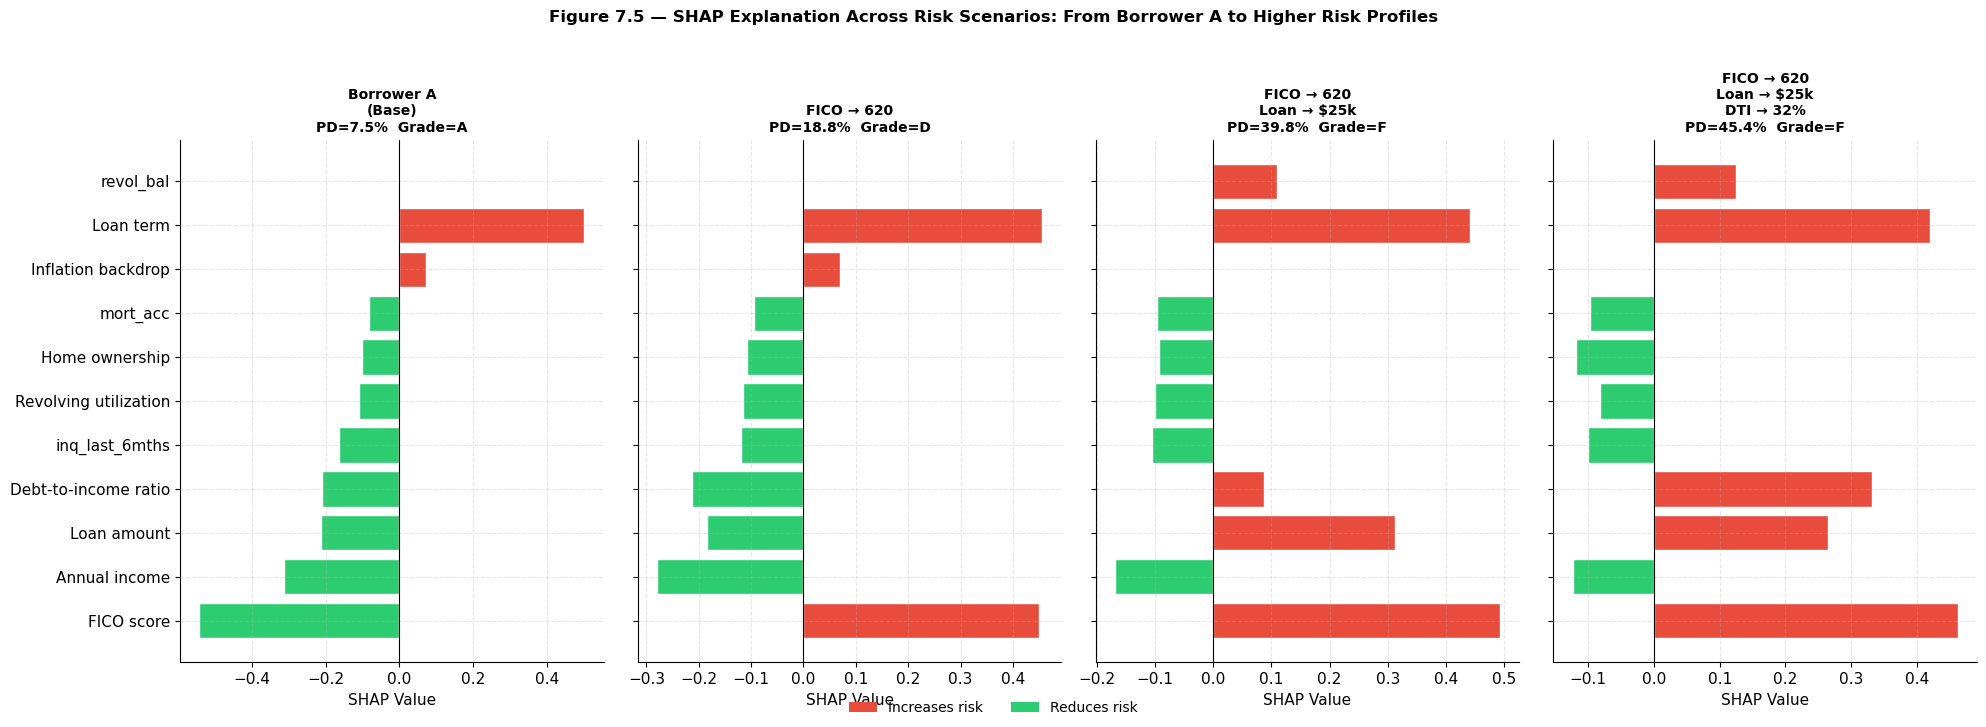

In [ ]:
# ============================================================
# Rerun SHAP for all four scenarios with corrected profiles
# ============================================================

scenarios_corrected = {
    f"Borrower A\n(Base)": base,
    f"FICO → 620": tmp1,
    f"FICO → 620\nLoan → $25k": tmp2,
    f"FICO → 620\nLoan → $25k\nDTI → 32%": tmp3,
}

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 4, figsize=(20, 7), sharey=True)

for ax, (label, profile) in zip(axes, scenarios_corrected.items()):
    pd_hat, _, contrib_raw = get_single_prediction_explanation(
        profile, "2018-01-01", top_n=30
    )
    grouped = group_shap_contributions(
        contrib_raw, cat_cols=cat_cols_final, num_cols=num_cols_final
    )
    plot_df = grouped.head(10).sort_values("shap_value", ascending=True)
    colors = ['#2ecc71' if v < 0 else '#e74c3c' for v in plot_df["shap_value"]]
    ax.barh(plot_df["pretty_feature"], plot_df["shap_value"],
            color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    grade = get_credit_grade(pd_hat)
    ax.set_title(f"{label}\nPD={pd_hat:.1%}  Grade={grade}",
                 fontweight='bold', fontsize=10)
    ax.set_xlabel("SHAP Value")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

legend_elements = [
    mpatches.Patch(facecolor='#e74c3c', label='Increases risk'),
    mpatches.Patch(facecolor='#2ecc71', label='Reduces risk'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=2, fontsize=10, frameon=False)
fig.suptitle(
    'Figure 7.5 — SHAP Explanation Across Risk Scenarios: From Borrower A to Higher Risk Profiles',
    fontweight='bold', fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

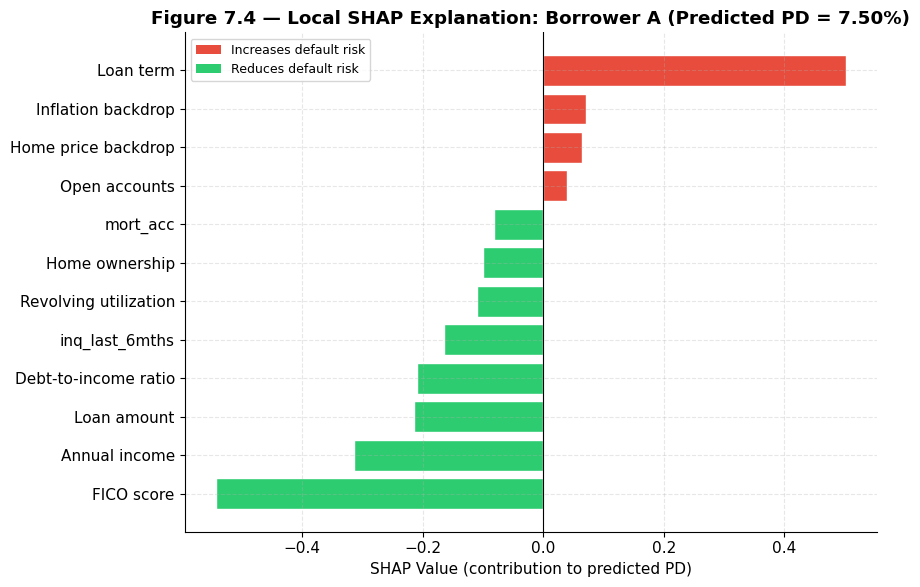

Grouped SHAP values:


,raw_feature,shap_value,abs_shap,pretty_feature
0,fico_range_low,-0.542728,0.542728,FICO score
1,term,0.501546,0.501546,Loan term
2,annual_inc,-0.314004,0.314004,Annual income
3,loan_amnt,-0.213626,0.213626,Loan amount
4,dti,-0.209069,0.209069,Debt-to-income ratio
5,inq_last_6mths,-0.164900,0.164900,inq_last_6mths
6,revol_util,-0.110630,0.110630,Revolving utilization
7,home_ownership,-0.100434,0.100434,Home ownership
8,mort_acc,-0.082192,0.082192,mort_acc
9,Inflation_L6,0.071111,0.071111,Inflation backdrop


In [ ]:
borrower_a = {
    "term": "36 months",
    "home_ownership": "MORTGAGE",
    "purpose": "debt_consolidation",
    "emp_length": "10+ years",
    "fico_range_low": 760,
    "loan_amnt": 8000,
    "dti": 6.7,
    "revol_util": 22.0,
    "annual_inc": 120000,
    "open_acc": 12,
    "delinq_2yrs": 0,
    "pub_rec": 0,
    "inq_last_6mths": 0,
    "mort_acc": 2,
    "revol_bal": 8000
}

pd_hat_a, _, contrib_raw_a = get_single_prediction_explanation(
    borrower_a, "2018-01-01", top_n=30
)
grouped_a = group_shap_contributions(
    contrib_raw_a, cat_cols=cat_cols_final, num_cols=num_cols_final
)

plot_df = grouped_a.head(12).sort_values("shap_value", ascending=True)
colors = ['#2ecc71' if v < 0 else '#e74c3c' for v in plot_df["shap_value"]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_df["pretty_feature"], plot_df["shap_value"],
        color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)

for i, val in enumerate(plot_df["shap_value"]):
    offset = 0.005 if val >= 0 else -0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, i, f'{val:+.4f}', va='center', ha=ha, fontsize=8.5)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Increases default risk'),
    Patch(facecolor='#2ecc71', label='Reduces default risk'),
]
ax.legend(handles=legend_elements, fontsize=9)
ax.set_xlabel('SHAP Value (contribution to predicted PD)')
ax.set_title(
    f'Figure 7.4 — Local SHAP Explanation: Borrower A (Predicted PD = {pd_hat_a:.2%})',
    fontweight='bold'
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("Grouped SHAP values:")
display(grouped_a.head(12))

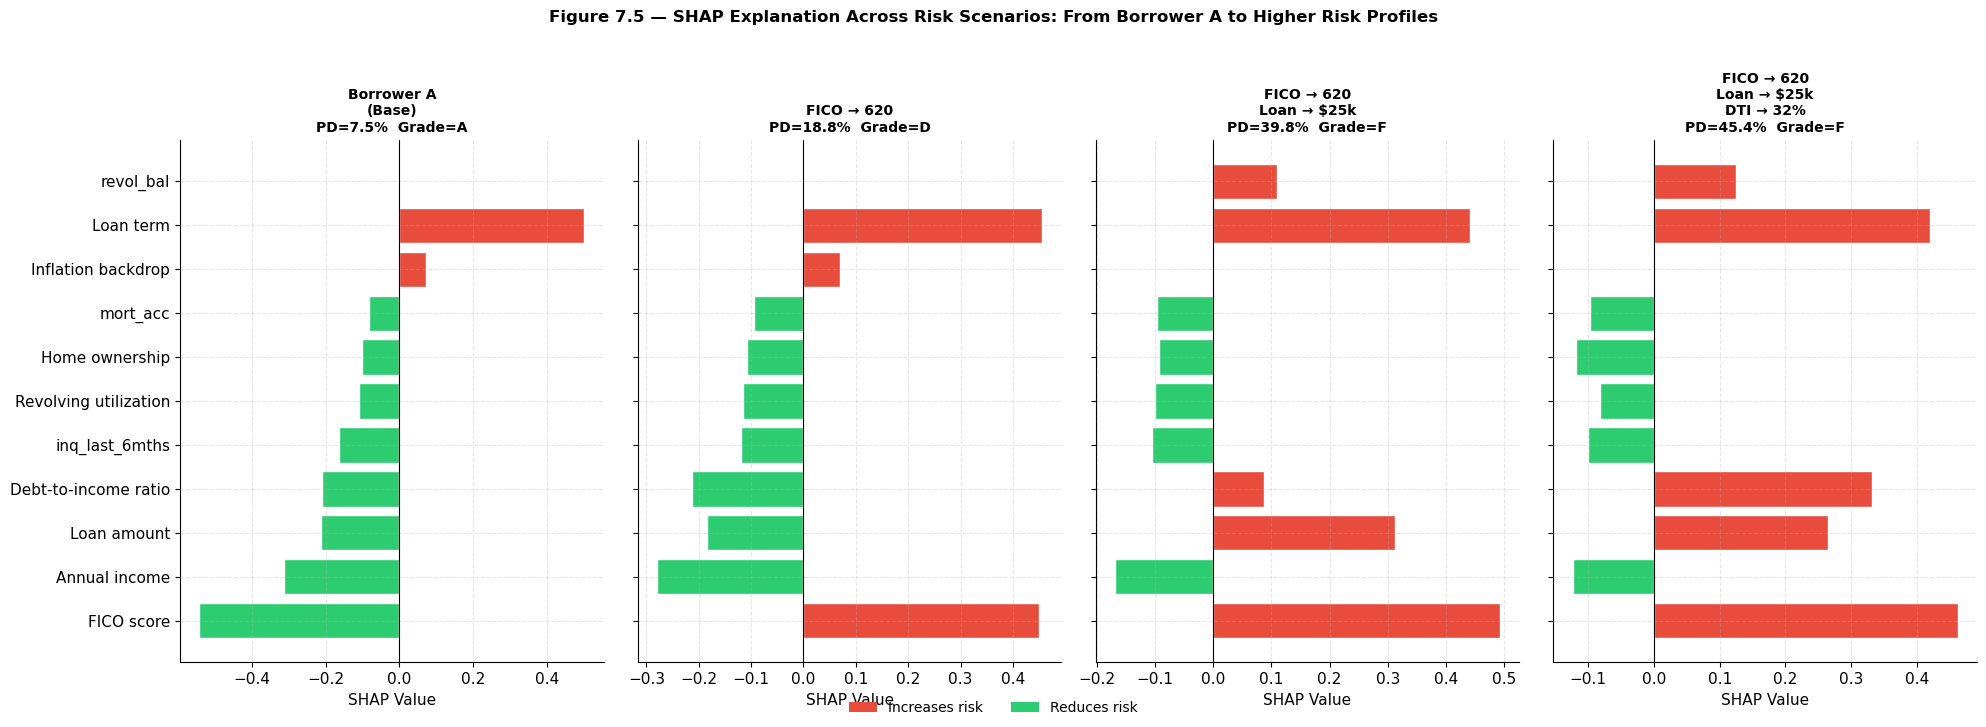

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Four scenarios using corrected DTI
base = borrower_a.copy()

tmp1 = base.copy()
tmp1["fico_range_low"] = 620

tmp2 = base.copy()
tmp2["fico_range_low"] = 620
tmp2["loan_amnt"] = 25000
tmp2["dti"] = round((25000 / 120000) * 100, 1)  # 20.8%

tmp3 = base.copy()
tmp3["fico_range_low"] = 620
tmp3["loan_amnt"] = 25000
tmp3["dti"] = 32.0

scenarios = {
    "Borrower A\n(Base)":              base,
    "FICO → 620":                      tmp1,
    "FICO → 620\nLoan → $25k":        tmp2,
    "FICO → 620\nLoan → $25k\nDTI → 32%": tmp3,
}

fig, axes = plt.subplots(1, 4, figsize=(20, 7), sharey=True)

for ax, (label, profile) in zip(axes, scenarios.items()):
    pd_hat, _, contrib_raw = get_single_prediction_explanation(
        profile, "2018-01-01", top_n=30
    )
    grouped = group_shap_contributions(
        contrib_raw, cat_cols=cat_cols_final, num_cols=num_cols_final
    )
    plot_df = grouped.head(10).sort_values("shap_value", ascending=True)
    colors = ['#2ecc71' if v < 0 else '#e74c3c' for v in plot_df["shap_value"]]

    ax.barh(plot_df["pretty_feature"], plot_df["shap_value"],
            color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)

    grade = get_credit_grade(pd_hat)
    ax.set_title(f"{label}\nPD={pd_hat:.1%}  Grade={grade}",
                 fontweight='bold', fontsize=10)
    ax.set_xlabel("SHAP Value")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

legend_elements = [
    mpatches.Patch(facecolor='#e74c3c', label='Increases risk'),
    mpatches.Patch(facecolor='#2ecc71', label='Reduces risk'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=2, fontsize=10, frameon=False)
fig.suptitle(
    'Figure 7.5 — SHAP Explanation Across Risk Scenarios: From Borrower A to Higher Risk Profiles',
    fontweight='bold', fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

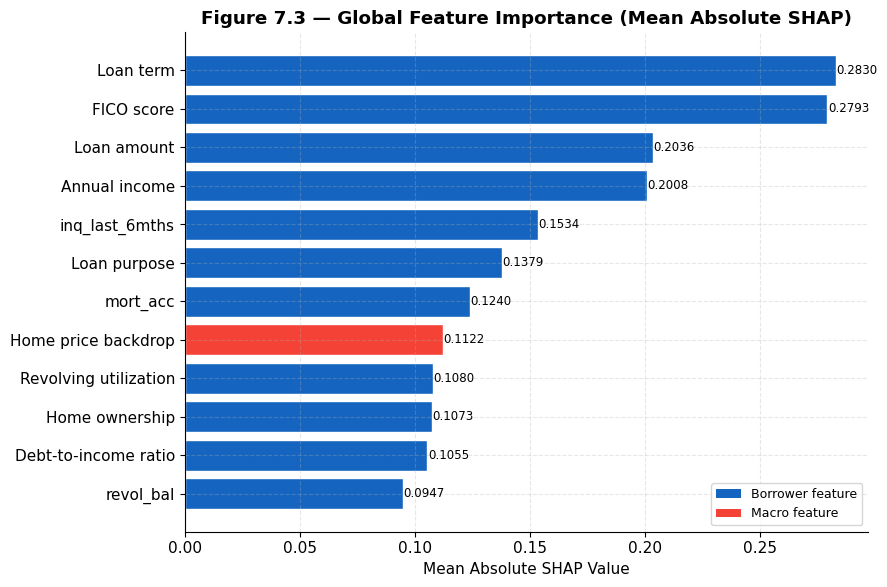

In [ ]:
pretty_raw_name_map = {
    "fico_range_low":  "FICO score",
    "loan_amnt":       "Loan amount",
    "dti":             "Debt-to-income ratio",
    "revol_util":      "Revolving utilization",
    "annual_inc":      "Annual income",
    "open_acc":        "Open accounts",
    "delinq_2yrs":     "Recent delinquencies",
    "pub_rec":         "Public records",
    "inq_last_6mths":  "Credit inquiries (6m)",
    "mort_acc":        "Mortgage accounts",
    "revol_bal":       "Revolving balance",
    "Inflation_L6":    "Inflation backdrop",
    "FedFunds_L3":     "Fed funds backdrop",
    "HomePrices_L12":  "Home price backdrop",
    "UNRATE_L6":       "Unemployment backdrop",
    "term":            "Loan term",
    "home_ownership":  "Home ownership",
    "purpose":         "Loan purpose",
    "emp_length":      "Employment length"
}

plot_df = global_grouped.head(12).sort_values("mean_abs_shap", ascending=True)

colors = ['#F44336' if 'backdrop' in str(f).lower() else '#1565C0'
          for f in plot_df["pretty_feature"]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_df["pretty_feature"], plot_df["mean_abs_shap"],
        color=colors, edgecolor='white')

for i, (val, feat) in enumerate(zip(plot_df["mean_abs_shap"], plot_df["pretty_feature"])):
    ax.text(val + 0.0002, i, f'{val:.4f}', va='center', fontsize=8.5)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1565C0', label='Borrower feature'),
    Patch(facecolor='#F44336', label='Macro feature'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.set_xlabel('Mean Absolute SHAP Value')
ax.set_title('Figure 7.3 — Global Feature Importance (Mean Absolute SHAP)',
             fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()